In [1]:

"""Importamos las librerías"""
import math, random, json, pathlib, os
from typing import List, Tuple
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader,  WeightedRandomSampler, Subset, random_split
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split



# FUNCIONES COMUNES 


## Función para conseguir Reproducibilidad al fijar semillas


In [2]:


def set_seed(seed_value=42):
    """
    Fija la semilla para la reproducibilidad en Python, NumPy y PyTorch.
    """
    # 1. Semilla de Python (Hash, etc.)
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Semilla de NumPy (para preprocesamiento y funciones auxiliares)
    np.random.seed(seed_value)
    
    # 3. Semilla de PyTorch (CPU)
    torch.manual_seed(seed_value)
    
    # 4. Semilla de PyTorch (GPU / CUDA)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value) # Para múltiples GPUs
        
        # 5. Configuración para operaciones determinísticas en la GPU
        # Esto puede ralentizar un poco el entrenamiento, pero garantiza la reproducibilidad.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## Obtención de los datos desde archivo Fasta
 Para la tarea de clasificación es necesario devolver un listado de secuencias y un listado de las clases a la ue pertenecen cada secuencia.

In [3]:
"""El uso de esta función auxiliar es para manejar si la secuencia debe añadirse o no al cojunto de datos con el que vamos a trabajar,
para que sea facilmente manejable el extraer solo los datos de las 5 clases mayoritarias o los de todas las clases"""

def check_addition(biotype, just_selection):
    selected_biotypes = [ 'lncRNA','snRNA', 'miRNA', 'misc_RNA', 'snoRNA']
    if just_selection:
        if biotype in selected_biotypes:
            return True
        return False
    return True

#Esta función filtra directamente los datos para que solo devuelva aquellas secuencias que son de las clases permitidas
def read_fasta(path, just_selection = False) -> List[str]:
    """Comenzamos inicializando una lista vacía cur en la que se irán acumulando los tramos de las secuencias (las líneas que no son la cabecera)
        Además inicializamos un diccionario data_dict para poder guardar las secuencias como valores asociados a sus identificadores como claves
        El valor del id y del biotipo de cada secuencia lo inicializamos a None inicialmente."""
    cur = []; seqs = []; targets = []; biotype = None; 
    with open(path) as f:
        """Abrimos el archivo con los datos e iteramos por todas sus líneas. Debemos tener en cuenta que hay dos tipos de líneas en el archivo.
        Tenemos las cabeceras, que contienen los metadatos de las secuencias y los tramos de secuencias. Una misma secuencia estará dividida en varios tramos.
        La forma que tenemos de distinguir entre los tipos de líneas del dataset es ver si comienzan por el caracter '>' """
        for line in f:
            if line.startswith(">"):   #EL iterador ha llegado a una nueva secuencia.
                """Si la línea actual comienza por el caracter >, significa que estamos ante una cabecera y que comienza una nueva secuencia."""
                """Si la secuencia es la primera del archivo, no entrará en el siguiente if y pasará directamente a extraer el id y biotipo de esa primera secuencia
                quedando así las variables del mismo nombre con valores distintos a None, que es como se inicializan"""
                """Si es una secuencia que no es la primera del archivo, el id y el biotipo tendrán el valor propio de la secuencia anterior que hemos acabado de iterar pero que todavía no hemos guardado
                 además cur guardará todos los tramos de la secuencia anterior que hemos acabado de iterar """
                if biotype and cur: 
                    if check_addition(biotype, just_selection): #if biotype in selected_biotypes
                        full_sequence = "".join(cur)   #Unimos todos los tramos de una misma secuencia
                        """Añadimos la secuencia a la lista de secuencias y el tipo de secuencia a su lista correspondiente"""
                        seqs.append(full_sequence)
                        targets.append(biotype)
                    cur = [] # Reiniciar para la nueva secuencia
                """Tanto si es la primera línea del proyecto como si es otra cualquiera, se extrae de la cabecera el biotipo"""
                headers = line.split() 
                biotype = headers[4].split(":")[1] 
            else:  
                """Si la línea actual no comienza por el signo >, significa que estamos ante un trozo de la cadena actual, por lo que añadimos dicho trozo
                a la lista cur para ir acumulando todos los tramos de la secuencia actual"""                             
                cur.append(line.strip())        

        if cur: 
            full_sequence = "".join(cur)
            seqs.append(full_sequence)
            targets.append(biotype)
    return seqs, targets


if __name__ == "__main__":
    fasta = "data/rna_small.fasta" #
    seqs, biotypes = read_fasta(fasta, just_selection=False)
    print('Número de biotipos distintos: ',len(seqs))
    print(len(biotypes))

    print(seqs[:10])
    print(biotypes[:10])


   

Número de biotipos distintos:  41635
41635
['GCUCUCUUGCCUGCCGCCACAUAAGACAUGACUUUGCUCCUCAUUCAGCUUCCGCCAUGAUUCUGAGGCCUCCCCAGCGACGUGAAACUCUUCAAUAAAUAUAGACUGCCGUAUCUCUAUGCAUCAGACAUGUCCAUCCUUUGGUUGAGCGAGACACAGGGUGAUACGCACUCGCAGGUGCAUACAUGUCCUAUCCUGGUCUGUGAUUUUUCUGUCCAAGAUGGUGGCUGUUGUACCCUUGAUUUUCUGAAGUCACCAGCACACAGCCUCAGUGCCAGUGGUCAUCAGCCGUGUUAUCAGCUUUCAGAAUUGGAGAGAUGGGGACCCAGUUUCAUUCUUCCACGUGUUUGCUGUCACUUCUGAUAUGCAUACAGCAAUUUGAAUUGACACUGUACAUUAACCAGUAAGAUGAGCUCUGAUUUUGCUCUGACAGCCUGGGGAUGAGGAGCAAGUUGACAAAAUGCUGCAACUUCUGAGGAGGAAAAAUAAAUCUUACCUAGGAAA', 'GUAUUAUCUACAGGCACUAAGAUCCUGAAAAUGUCUUUUCCUCUUCACAUUACACACAAGGAAACCAGACUGUGAACAUAACAAUGAGUUACUUGAAAAUUAAAGGACCCUGAUCCAUCAAUAUGACUACACAUUUGAUUGGACAAAGUUAAAGCAGAAAGCAGCACAGCAGGCAGCCUCUUCUAGUGGGAGGGGCAGCAGGCCCAAACCCCAACAGGGUAUUUAGAGAAAUUCAAUCAGAGACGAUGGAACUAAAGCUGGCCCUUCUGUGCAUACCUGUUUCCUAAAGAAAUGUUUACUCCUGGAUUGGGUCAGCCCCUCUGCAUUUACCUAUAAGAAUCUACAUACAAGCUUGUCUAUCCAUCCUGCAUAGAGCACAAGUCACAGAAGAAAAGCUCCUCUCCAUAAAUUGCUUAACAUAGUAAUCAAUAUCUCUUCACAUUUUCA

## Generación del vocabulario

In [4]:
"""Obtenemos el vocabulario, como todas las convinaciones posibles de 3 nucleótidos. Además añadimos al vocabulario
4 tokens especiales, de Padding, enmascaramiento, token desconocido, y CLS usado para agrupar el conexto de las secuencias en un único vector
con tal de poder llevar a cabo tareas downstream tras el preentrenamiento"""


K = 3
BASES = ["A","C","G","U"]
def all_kmers(k=3):
    vocab = []
    def rec(prefix, k):
        if k==0:
            vocab.append(prefix)
            return
        for b in BASES:
            rec(prefix+b, k-1)
    rec("", k)
    return vocab

kmers = all_kmers(K)  # 64 tokens
print("kmers: ",kmers)
SPECIAL = ["[PAD]","[CLS]","[MASK]","[UNK]"]
#itos es el vocabulario con el que vamos a trabajar de 64 tokens de nucleótidos + 4 tokens especiales
itos = SPECIAL + kmers
#stoi se trata de un diccionario que tiene como clave el token del vocabulario (3-kmer o token especial), y como valor el índice.
#simplemente permite mapear los tokens a su índice en el vocabulario.
stoi = {t:i for i,t in enumerate(itos)}
PAD, CLS, MASK, UNK = [stoi[s] for s in SPECIAL]
print("Vocabulatio: ",stoi)
print("Tamaño vocabulario:", len(itos))

kmers:  ['AAA', 'AAC', 'AAG', 'AAU', 'ACA', 'ACC', 'ACG', 'ACU', 'AGA', 'AGC', 'AGG', 'AGU', 'AUA', 'AUC', 'AUG', 'AUU', 'CAA', 'CAC', 'CAG', 'CAU', 'CCA', 'CCC', 'CCG', 'CCU', 'CGA', 'CGC', 'CGG', 'CGU', 'CUA', 'CUC', 'CUG', 'CUU', 'GAA', 'GAC', 'GAG', 'GAU', 'GCA', 'GCC', 'GCG', 'GCU', 'GGA', 'GGC', 'GGG', 'GGU', 'GUA', 'GUC', 'GUG', 'GUU', 'UAA', 'UAC', 'UAG', 'UAU', 'UCA', 'UCC', 'UCG', 'UCU', 'UGA', 'UGC', 'UGG', 'UGU', 'UUA', 'UUC', 'UUG', 'UUU']
Vocabulatio:  {'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, '[UNK]': 3, 'AAA': 4, 'AAC': 5, 'AAG': 6, 'AAU': 7, 'ACA': 8, 'ACC': 9, 'ACG': 10, 'ACU': 11, 'AGA': 12, 'AGC': 13, 'AGG': 14, 'AGU': 15, 'AUA': 16, 'AUC': 17, 'AUG': 18, 'AUU': 19, 'CAA': 20, 'CAC': 21, 'CAG': 22, 'CAU': 23, 'CCA': 24, 'CCC': 25, 'CCG': 26, 'CCU': 27, 'CGA': 28, 'CGC': 29, 'CGG': 30, 'CGU': 31, 'CUA': 32, 'CUC': 33, 'CUG': 34, 'CUU': 35, 'GAA': 36, 'GAC': 37, 'GAG': 38, 'GAU': 39, 'GCA': 40, 'GCC': 41, 'GCG': 42, 'GCU': 43, 'GGA': 44, 'GGC': 45, 'GGG': 46, 'GGU': 47, '

## Función Tokenizadora de las secuencias
 Función que tokeniza las secuencias de ARN pasando de cadenas de caracteres a tokens del vocabulario. 
 Lo hace siguiendo un enfoque de recorrido solapado, es decir, como una ventana deslizante, si la cadena es AUCG, tenemos dos tokens AUC, UCG, CG, G.
 Pasándole una secuencia de nucleótidos devuelve una secuencia de los tokens que componen la secuencia inicial.
 Hacerlo de forma solapada (ventana deslizante), evita pérdidas de información, ya que si segmentamos la cadena en kmers de longitud k, extrayendo un solo token cada k nucleótidos, nos podríamos estar perdiendo patrones o motivos estructurales importantes, que podrían quedar divididos arbitrariamente entre dos tokens adyacentes, por tanto, no estaríamos tomando toda la información de la secuencia.

 

In [5]:
"""Esta función sería nuestro tokenizador, recibe como parámetro la secuencia completa
Primero: Reemplaza aquellas bases nitrogenadas T (que pudiera haber) por U 
Segundo: Por cada codón de la secuencia (Kmer de longitud 3),  comprueba que los nucleótidos que componen el Kmer sean nucleótidos conocidos,
es decir nucleótidos del conjunto (A, U, G, C). 
Si alguno de los nucleótidos del kmer actual, no es conocido, añade como token de la secuencia el [UNK].
Si todos los nucleótidos del kmer son conocidos, se añade como token el índice del token en el diccionario. De esta forma
no se trabaja con tokens como tal sino con sus índices en el diccionario, lo cual es un enfoque mucho más eficiente.
Tercero: retorna la secuencia tokenizada como una lista de índices de los tokens en el vocabulario.
"""

def seq_to_kmers(seq, k=3):
    seq = seq.upper().replace("T","U")
    toks = []
    for i in range(0, len(seq)-k+1):
        kmer = seq[i:i+k]       #Separo toda la secuencia de ARN en Kmers; 
        if any(ch not in BASES for ch in kmer): #Si algun nucleótido perteneciente a algún kmers que no es conocido (ni A, U, G, C), 
            toks.append(UNK)                    #entonces ese token (kmer) de la secuencia de ARN lo ponemos a Unknown
        else:
            toks.append(stoi[kmer] if kmer in stoi else UNK)    #Si todas las bases nitrogenadas del kmers son conocidas, lo que hacemos es, no añadir el kmer sino su índice en el diccionario anterior
    return toks

## Funciones para guardar y cargar modelos a y desde local.

In [6]:
import torch
import os

"""Para guardar el modelo en local, lo que se guarda es su diccionario de parametros.
Esta función recibe el modelo, junto con el nombre que le vamos a dar al archico y el nombre de la carpeta
en la que queremos guardar el modelo."""
def save_model(modelo, nombre_archivo = 'modelo1.pth', ruta_carpeta = "./modelos_guardados" ):

    # Crear la carpeta si no existe
    os.makedirs(ruta_carpeta, exist_ok=True)
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

    torch.save(modelo.state_dict(), ruta_completa)


"""Para cargar el modelo desde local, debemos recordar que lo que guardábamos era el diccionario de pesos del modelo y no el modelo en sí mismo
Por lo tanto como primer paso para cargar el modelo, necesitamos una instancia vacía del mismo modelo que cargamos, es decir necesitamos la aqruitectura 
del modelo vacía para rellenarla con los pesos que tenemos guardados. Es crucial que la aruqitectura del modelo sea exáctamente la misma que de la que 
sacamos los pesos para guardaros.
Esta función recibe una instancia del modelo vacía y la rellena con los pesos del modelo que tenemos guardados en la ruta indicada."""
def load_model(model_object, ruta_archivo):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    state_dict = torch.load(ruta_archivo, map_location=torch.device(device))

    # Inyectar los pesos en el modelo
    model_object.load_state_dict(state_dict)

    model_object.to(device)

    return model_object

## Clase EarlyStopper para poder parar los entrenamientos si no mejora.

En pytorch necesitamos implementar nosotros mismos una clase EarlyStopper. Esta clase tiene el propósito de detener el entrenamiento antes de que comience el sobreajuste, concretamente cuando el modelo ya no consigue mejorar su desempeño según una métrica que le indiquemos. Presenta un parámetro de tolerancia que permite prorrogar la detención del entrenamiento hasta que no hayan pasado un número concreto de épocas sin mejorar dicha métrica.

In [7]:
import numpy as np
import torch

class EarlyStopper:
    def __init__(self, patience=3, min_delta=0, mode='min'):
        """
        Inicializa la clase EarlyStopper.
        Args:
            patience (int): Número de épocas a esperar después de que la métrica deje de mejorar.
            min_delta (float): Cambio mínimo para ser considerado una mejora.
            mode (str): 'min' (si se monitoriza val_loss) o 'max' (si se monitoriza val_f1).
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_metric = float('inf') if mode == 'min' else float('-inf')
        self.stop_training = False #booleano para parar las iteraciones

    def __call__(self, current_metric):
        """Llamado después de cada época."""
        
        if self.mode == 'min': #Para métricas que deben minimizarse (pérdida)
            improvement = self.best_metric - current_metric
        else:       #Para métricas que deben maximizarse (accuracy, f1_score...)
            improvement = current_metric - self.best_metric
            
        "Si hay mejora, respecto a la mejor métrica registrada, devolvemos True, y ponemos el contador a 0"
        if improvement > self.min_delta:
            # Hay mejora: Resetear el contador y actualizar la mejor métrica
            self.best_metric = current_metric
            self.counter = 0
            return True #Guardar el modelo
        
        else:
            "Si No hay mejora, respecto a la mejor métrica registrada, devolvemos False, e incrementamos el contador"
            self.counter += 1
            if self.counter >= self.patience:
                self.stop_training = True
            return False #NO guardar el modelo
        


## Fución para hacer una partición de los datos en train, test y validación.
Selecciona los índices del dataset original que irán en cada subconjunto de datos. Así podemos llevar a cabo Datasets explícitos que no sean subconjuntos de un mismo Dataset.
La idea es que la función devuelva un split de los índices de las secuencias que van a pertenecer a cada dataset. Con esos índices que devuelve esta función se crearán Datasets independientes para cada tarea. 
Esto lo hacemos principalmente para aquellos Datasets que incorporan un recorte de secuencias, cuando estas superan la longitud máxima. 
Resulta que los Datasets que usamos para los modelos con bloques Transformers, recortamos las secuencias a 512. Para train hacemos el recorte particionando la secuencia por un índice escogido de forma aleatoria, pero en test y validación, para poder hacer ese recorte de forma determinista y que no haya diferencias en los resultados entre distintas ejecuciones, recortamos las secuencias despreciando los últimos tokens que haya más allá del token número 512. 

Si generásemos un mismo Dataset con todos los datos, para después hacerle un split y sacar 3 datasets de entrenamiento, validación y test, no podríamos distinguir la forma en la que particionar las secuencias. Como queremos distinguir la forma en la que recortamos las secuencias necesitamos un dataset propio para cada tarea.


In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

def splitIndexesDatasets(seqs, labels, test_percentage = 0.2, just_two = False):
    
    indices = np.arange(len(seqs))
    temp_idx, test_idx, _, _ = train_test_split(
    indices, 
    labels,                
    test_size=test_percentage,                
    shuffle=True,                  
    stratify=labels,         
    random_state=42                
    )

    if just_two:
        return temp_idx, test_idx
    
    temp_labels = np.array(labels)[temp_idx]

    train_idx, val_idx, _, _ = train_test_split(
        temp_idx,                 
        temp_labels,                  
        test_size=test_percentage,               
        shuffle=True,
        stratify=temp_labels,         
        random_state=42
    )

    return train_idx, val_idx, test_idx



## Funciones para poder construir el Muestreo ponderado para evitar el efecto del desbalanceo


El conjunto de datos presenta un desbalanceo severo: de las 41.635 secuencias totales, la clase mayoritaria (lncRNA) abarca 34.852 muestras (aprox. 84%), mientras que las clases restantes cuentan con apenas 2.000 secuencias cada una.
Para evitar que el modelo desarrolle un sesgo hacia la clase mayoritaria, el DataLoader debe generar lotes de entrenamiento (batches) con una distribución de clases equilibrada. Para ello, se implementó una estrategia de Muestreo Ponderado (con la clases de pytorch WeightedRandomSampler).


Se optó por utilizar un muestreo ponderado en lugar de aplicar técnicas de oversampling debido a que el muestreo ponderado permite compensar el desbalanceo de clases sin alterar artificialmente la distribución real del dataset ni duplicar instancias. A diferencia del oversampling, que incrementa la frecuencia de aparición de algunas muestras repitiéndolas, el muestreo ponderado ajusta dinámicamente la probabilidad de selección de cada clase durante el entrenamiento, evitando así introducir redundancia innecesaria en los datos y reduciendo el riesgo de sobreajuste en las clases minoritarias, especialmente relevante cuando estas cuentan con muy pocos ejemplos originales.


Esto asegura que cada "batch" (lote) de entrenamiento tenga una mezcla equilibrada de clases.

En lugar de seleccionar las muestras al azar de forma uniforme,el funcionamiento se basa en asignar una probabilidad de selección a cada muestra, que sea inversamente proporcional a la frecuencia de su clase.  Matemáticamente, en lugar de usar la frecuencia bruta ($f_i$), utilizamos la frecuencia inversa ($1/f_i$).

Al ponderar las probabilidades de escoger una muestra de cualquiera de las clases, por las frecuencias inversas, se  garantiza que, probabilísticamente, sea igual de factible seleccionar una muestra de la clase minoritaria que de la mayoritaria, logrando una homogeneización estocástica del batch.


El objetivo es que la probabilidad total de que salga la Clase A sea igual a la probabilidad de que salga la Clase B, sin importar cuántos elementos tengan. Así aunque el dataset total esté desbalanceado, los batches que el modelo ve durante el entrenamiento está virtualmente balanceados.

**Nota sobre la implementación:** Para mejorar la interpretabilidad humana y la legibilidad de los pesos, multiplicamos estas frecuencias inversas por una constante N que se trata del número total de secuencias. Al ser una constante, no altera la probabilidad relativa (el resultado matemático es idéntico). 


La función no solo devuelve el sampler, sino también los pesos usados para calcularlo, ya que existe la posibilidad de pasarle esos pesos a la función de pérdida de forma que penalice mucho más los errores en clases minoritarias. 
Sin embargo, experimentos preliminares mostraron que combinar ambas técnicas (muestreo ponderado + pesos en la Loss) resultaba redundante y excesivamente agresivo, penalizando desproporcionadamente los errores y desestabilizando la convergencia. El muestreo ponderado por sí solo demostró ser suficiente y más robusto para mitigar el desbalanceo




In [9]:

"""Las siguientes dos funciones llevan a cabo el muestreo ponderaado para evitar los efectos del desbalanceo de clases"""
#Implementando el muestreo ponderado antes de instanciar los DataLoader

def class_weights(labels):

    class_counts = Counter(labels)
    num_samples = len(labels)
    # No calculamos la inversa de la frecuencia (Weight = 1 / Frequency)
    pesos_clases = {lbl: num_samples / count for lbl, count in class_counts.items()}

    return pesos_clases

def get_the_sampler(train_labels = None):
    sampler = None
    pesos_clases = None
    if train_labels is not None:
        pesos_clases = class_weights(train_labels)
        "Debe ser un doble tensor para evitar pérdidas de precisión. Ya que un tersor normal tendría una precisión de"
        "float32, lo cual puede no ser suficiente para el valor tan pequeño que puedan darnos estos pesos"
        pesos_muestras = torch.DoubleTensor([pesos_clases[label] for label in train_labels]) 


        # Creamos el DataSampler que será el que se le pase al DataLoader
        sampler = WeightedRandomSampler(
            weights=pesos_muestras,
            num_samples=len(pesos_muestras), # Queremos extraer el mismo número de muestras que hay en total
            replacement=True                        # ¡Importante! Permite que las muestras se repitan (sobremuestreo)
        )

    return sampler, pesos_clases


## Función visualizar historia de entrenamiento

Creación de una serie de funciones para visualizar las gráficas de la evolución de las métricas obtenidas en el entrenamiento y validación de los modelos de clasificación (tanto baseline como BERT + cabeza)

In [10]:
import matplotlib.pyplot as plt

def plot_grafica(ax, epochs, data, label, color):
    ax.plot(epochs, data, label=label, color=color)

def select_titles_and_labels(keys_to_plot):
    default_messages = {'train_loss val_loss':('Pérdida de Entrenamiento vs. Validación', 'Pérdida Entropía Cruzada'),
                        'val_accuracy val_f1_macro':('Métricas de Rendimiento en Validación', 'Valores de Métrica'),
                        'val_perplexity':('Perplejidad del modelo en validación','Valores de Perplejidad')}
    return default_messages[keys_to_plot]

def pintar_grafica(ax, epochs, history, keys_to_plot):
    
    color_and_labels_dict = {'train_loss':('Train Loss (Pérdida Entrenamiento)', 'blue' ),
                             'val_loss':('Validation Loss (Pérdida Validación)', 'orange'),
                             'val_accuracy':('Validation Accuracy', 'red' ),
                             'val_f1_macro': ('Validation F1 Macro', 'green'),
                             'val_perplexity':('Peplejidad en Validación','red')}
    for key in keys_to_plot:
        plot_grafica(ax, epochs, history[key], label = color_and_labels_dict[key][0], color = color_and_labels_dict[key][1] )

    texts = select_titles_and_labels(" ".join(keys_to_plot))
    # Título y etiquetas
    ax.set_title(texts[0])
    ax.set_xlabel('Epochs (Épocas)')
    ax.set_ylabel(texts[1])
    ax.legend()
    ax.grid(True, linestyle='--')
    ax.set_xticks(np.arange(1, len(epochs) + 1, 2)) 


def showTrainMetrics(history, title = 'MLP Baseline'):
    
    # El número de épocas es la longitud de cualquiera de las listas de métricas
    epochs = range(1, len(history['train_loss']) + 1)


    # 1. Configuración de las subgráficas lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Evolución de las Métricas del Modelo {title}', fontsize=16)

    keys = list(history.keys())
    axes = (ax1, ax2)
    for idx, i in enumerate(range(0,len(keys),2), start=0):

        pintar_grafica(axes[idx], epochs, history, keys_to_plot=keys[i:i+2])
    
    
    # Mostrar las gráficas
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar para el título principal
    plt.show()

## Función Auxiliar roc curve

Creación de una función adicional para la representación de la curva ROC tras la ejecución de las funciones de test.

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def calculate_roc_data(true_labels: np.ndarray, all_probabilities: np.ndarray):
    """
    Calcula los datos necesarios (FPR, TPR, AUC) para dibujar la curva ROC multiclase (OVR).

    Args:
        true_labels: Etiquetas verdaderas (ej. [0, 1, 2, ...]).
        all_probabilities: Probabilidades de cada clase (Salida de Softmax).

    Returns:
        dict: Diccionario con FPR, TPR y AUC para cada clase.
    """
    
    class_labels = np.unique(true_labels)
    n_classes = len(class_labels)

    # 1. Binarizar las etiquetas verdaderas (necesario para OVR)
    true_labels_binarized = label_binarize(true_labels, classes=class_labels)

    # Inicializar diccionarios
    roc_data = {'fpr': {}, 'tpr': {}, 'auc': {}}

    # 2. Calcular la curva ROC y el AUC para cada clase (One-vs-Rest)
    for i in range(n_classes):
        # Calcula el TPR, FPR y umbrales para la clase i contra todas las demás
        roc_data['fpr'][i], roc_data['tpr'][i], _ = roc_curve(
            true_labels_binarized[:, i], 
            all_probabilities[:, i]
        )
        roc_data['auc'][i] = auc(roc_data['fpr'][i], roc_data['tpr'][i])
    
    return roc_data

## Función visualizar métricas de test

Creación de una serie de funciones para visualizar las gráficas de la evolución de las métricas obtenidas en el testeo de los modelos de clasificación (tanto baseline como BERT + cabeza)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Datos devueltos de la función test_model:
# ac, f1, cf_matrix, mcc, auc, roc_curve_data = test_model(...)

# Asumiendo cf_matrix y roc_curve_data están disponibles aquí.
# cf_matrix ya está disponible.
# roc_curve_data contiene 'fpr', 'tpr', y 'auc'.


def showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'MLP Baseline'):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Visualización de Rendimiento del {title}', fontsize=16)

    # ====================================================
    # GRÁFICA 1: Matriz de Confusión
    # ====================================================

    id_a_nombre_mapping = {v: k for k, v in class_to_idx.items()}
    nombres_clase_ordenados = [id_a_nombre_mapping[i] for i in range(len(clases_unicas))]

    sns.heatmap(
        cf_matrix, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        cbar=False,
        ax=ax1,
        xticklabels=nombres_clase_ordenados,
        yticklabels=nombres_clase_ordenados
    )

    ax1.set_title('Matriz de Confusión')
    ax1.set_xlabel('Predicción')
    ax1.set_ylabel('Etiqueta Verdadera')


    # ====================================================
    # GRÁFICA 2: Curva ROC (Multiclase OVR)
    # ====================================================

    for i in range(len(clases_unicas)):
        # Usamos los datos precalculados de roc_curve_data
        ax2.plot(
            roc_curve_data['fpr'][i], 
            roc_curve_data['tpr'][i], 
            label=f'Clase {id_a_nombre_mapping[i]} (AUC = {roc_curve_data["auc"][i]:.4f})'
        )

    # Línea de clasificación aleatoria
    ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC=0.50)')

    ax2.set_title('Curva ROC Multiclase (OVR)')
    ax2.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax2.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax2.legend(loc="lower right")
    ax2.grid(True, linestyle='--')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## UMAP



Para evaluar la capacidad del modelo de generar representaciones separables de las secuencias de ARN, visualizamos el espacio latente (embeddings) generado en la penúltima capa del modelo entrenado. El objetivo es analizar la topología de los datos: idealmente, el modelo debería agrupar los ejemplos de una misma clase en una misma región del manifold (baja varianza intra-clase) y mantener separadas las distintas clases entre sí (alta distancia inter-clase).

Dado que los embeddings resultantes poseen alta dimensionalidad (en este caso, 8 dimensiones), es necesario proyectarlos a un espacio de menor dimensión (2D) para su interpretación visual. Para ello utilizamos UMAP (Uniform Manifold Approximation and Projection). UMAP es una técnica de reducción de dimensionalidad no lineal que destaca por preservar tanto la estructura local de los datos (manteniendo juntos a los vecinos cercanos) como, en gran medida, la estructura global. 

Para obtener las representaciones internas (embeddings) sin modificar la arquitectura del modelo, implementamos la clase EmbeddingExtractor. Esta clase utiliza el sistema de Forward Hooks de PyTorch. Al instanciarla, registramos un hook (o función de callback que genera una acción) específicamente en la capa objetivo. Durante la inferencia (forward pass), cada vez que los datos atraviesan dicha capa, la función de hook intercepta automáticamente la salida. Permite extraer los embeddings de manera eficiente y no intrusiva mientras el modelo procesa el conjunto de datos.


Para configurar el objeto UMAP que reducirá la dimensionalidad de los datos, lo establecemos para que use como métrica de distancia, la distancia del coseno, qué es la distancia por excelencia entre embeddings (al menos acedémicamente usada), también que calcule las proyecciones de los embeddings atendiendo a los 30 vecinos más cercanos (este es el parámetro n_neihbors que cuando mayor sea con más precisión puede situar un embedding en el espacio), y por último establecemos que el espacio de destino es de 2 dimensiones y que la semilla usada sea el valor 42.


La configuración de UMAP se ha optimizado para la naturaleza de nuestros datos:

    Métrica: Se utiliza la distancia del coseno (metric='cosine'), que es el estándar para comparar similitud semántica en espacios vectoriales profundos, donde la orientación del vector suele ser más informativa que su magnitud.

    Vecinos: El parámetro n_neighbors se fija en 30. Este valor ofrece un balance entre preservar la estructura local (pequeños grupos) y la estructura global del manifold, permitiendo visualizar 'puentes' o continuidades entre clases si existen. 
    El algoritmo necesita referencias para triangular la posición de cada punto en el plano 2D. El parámetro n_neighbors define cuántos puntos de referencia utiliza cada secuencia para ubicarse. Al usar pocos vecinos, el punto solo se preocupa de estar pegado a sus gemelos idénticos.
    Al usar muchos vecinos (30), el punto también considera su posición relativa respecto a parientes más lejanos, lo que obliga al gráfico a mostrar cómo se conectan las distintas 'familias' de secuencias entre sí."

    Reproducibilidad: Se fija la semilla (random_state=42) para garantizar que las proyecciones sean deterministas y comparables entre ejecuciones."


Finalmente, la función plot_Umap orquesta todo el flujo de trabajo: itera sobre el conjunto de datos, activa el extractor en la capa solicitada (por ejemplo, classifier.6 o classification_head) y acumula los resultados. Una vez obtenidos todos los vectores, entrena el reductor UMAP con la totalidad de los datos para generar y graficar la proyección 2D final.






In [14]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader

#Clase extractora de embeddings
class EmbeddingExtractor:
    """
    Clase que se engancha a una capa específica del modelo y captura su salida.
    Funciona para MLP, BERT, CNNs, etc.
    """
    def __init__(self, model, layer_target):
        self.model = model
        self.layer_target = layer_target
        self.last_embedding = None
        self.hook_handle = None
        self._register_hook()

    def _register_hook(self):
        target_module = None
        
        for name, module in self.model.named_modules(): 
            if name == self.layer_target:
                target_module = module
                break

        self.hook_handle = target_module.register_forward_hook(self._hook_fn)

    def _hook_fn(self, module, input, output):
        # Guardamos la salida desconectada del grafo (detach) y en CPU
        self.last_embedding = output.detach().cpu().numpy()
        #Con detach se hace una copia de los embeddings de salida, son cpu, se guardan en cpu, en vez de en gpu

    def close(self):
        if self.hook_handle:
            self.hook_handle.remove()


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

def get_embeddings_universal(model, loader, layer_target, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Extrae embeddings de cualquier modelo usando un Hook.
    layer_target: Puede ser el nombre (str) o índice (int) de la capa.
    """
    model.eval()
    # model.to(device)
    
    extractor = EmbeddingExtractor(model, layer_target)
    
    embeddings_list = []
    labels_list = []
    
    try:
        with torch.no_grad():
            for tupla in loader:
                
                inputs, labels, *attn = tupla

                inputs = inputs.to(device)
                
                if attn:
                    _ = model(inputs, attn[0].to(device)) #Se necesita que el modelo original trabaje como siempre
                                            #Por lo que conviene aprovechar directamente el bucle de la función de test
                else:
                    _ = model(inputs)
                # Recogemos lo que el espía capturó
                if extractor.last_embedding is not None:
                    embeddings_list.append(extractor.last_embedding)
                
                if labels is not None:
                    labels_list.append(labels.cpu().numpy())

    finally:
        # IMPORTANTE: Quitamos el gancho para no dejar "basura" en el modelo
        extractor.close()

    return np.concatenate(embeddings_list), np.concatenate(labels_list)


def plot_Umap(model_trained, dataset, class_to_idx, layer_target, bs=32):
    """
    Ahora recibe 'layer_target' para saber qué capa mirar.
    """
    loader_umap = DataLoader(dataset, batch_size=bs, shuffle=False)
    
    print("1. Iniciando extracción...")

    embeddings_8d, labels_true = get_embeddings_universal(model_trained, loader_umap, layer_target)
    
    print(f"Forma de los Embeddings extraídos: {embeddings_8d.shape}")
    print("2. Calculando reducción U-MAP (Configuración Coseno/Vecinos optimizada)...")
    
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, random_state=42, metric='cosine')
    
    embedding_2d = reducer.fit_transform(embeddings_8d)
    
    print("3. Generando gráfico...")
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    df_umap = pd.DataFrame(embedding_2d, columns=['UMAP_DIM_1', 'UMAP_DIM_2'])
    df_umap['Clase'] = [idx_to_class[l] for l in labels_true]
    colores = {
    'lncRNA': 'tab:blue',
    'misc_RNA': 'tab:orange',
    'miRNA': 'tab:purple',  
    'snRNA': 'tab:green',
    'snoRNA': 'tab:red'
    }
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_umap, x='UMAP_DIM_1', y='UMAP_DIM_2', hue='Clase', palette=colores, s=20, alpha=0.7)
    plt.title(f'Proyección U-MAP - Capa: {layer_target}', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Clases")
    plt.tight_layout()
    plt.show()

## Extracción de los datos y preparación de los índices para los datasets que se usaran posteriormente


Generamos el vocabulario y extraemos las secuencias. Además seleccionamos previamente las secuencias que se usaran para train, validación y test.

In [17]:
#Leemos los datos
fasta = "data/rna_small.fasta" 
seqs, biotypes = read_fasta(fasta, just_selection=True)

#Generamos el vocabulario
kmers = all_kmers(K)  
SPECIAL = ["[PAD]","[CLS]","[MASK]","[UNK]"]
itos = SPECIAL + kmers
stoi = {t:i for i,t in enumerate(itos)}
PAD, CLS, MASK, UNK = [stoi[s] for s in SPECIAL]

#Pasamos las etiquetas de cadenas de caracteres a numéricas
clases_unicas = sorted(list(set(biotypes)))
class_to_idx = {name: i for i, name in enumerate(clases_unicas)}
labels_numeric = [class_to_idx[label] for label in biotypes]


train_idx, val_idx, test_idx = splitIndexesDatasets(seqs, labels_numeric)

train_seqs = [seqs[i] for i in train_idx]
train_labels = [labels_numeric[i] for i in train_idx]

val_seqs = [seqs[i] for i in val_idx]
val_labels = [labels_numeric[i] for i in val_idx]

test_seqs = [seqs[i] for i in test_idx]
test_labels = [labels_numeric[i] for i in test_idx]


# BASELINE

Nuestro baseline se va a centrar en clasificar las secuencias de ARN atendiendo solamente al conteo de kmers (tokens) de la seuencia. (Frecuencias de aparición de cada token del vocabulario en la secuencia)

## Generación del Dataset

Contruimos una clase dataset que codifique las secuencias como vectores del tamaño del vocabulario que guardan en cada posición la frecuencia de aparición en la secuencia del token correspondiente a esa misma posición del vocabulario. Así codificamos a las secuencias como vectores que guardan el conteo de tokens distintos que las componen.

In [18]:

"""En el modelo baseline, vamos a hacer uso también de los kmers para tener las secuencias como valores numéricos.
La otra opción era usar One-hot encoding, pero es menos viable para los MLP.
Vamos a trabajar con secuecnias de ARN, que a priori se representan como letras, por lo que debemos ponerlas como números
Las eqtiquetas de las clases, se le pasan ya como numéricas, aprovechando la transformación hecha en la clase anterior.
Este dataset devuelve las secuencias tokenizadas en kmers, un vector que indica que tokens de la secuencia son padding,
y el vector de etiquetas."""

class MLPDatasetBaseline(Dataset):

    def __init__(self, features, labels, vocabulario, K = 3):
        super().__init__()
        """features --> Son las secuencias de ARN en crudo, como sucesiones de nucleótidos
           labels --> son las etiquetas numéricas de las clases a las que pertenece cada secuencia""" 
        self.vocab_dict = vocabulario; self.K = K
        self.data = [(s, l) for s, l in zip(features, labels) if len(s) >= self.K+1]
        self.seqs, self.labels = map(list, zip(*self.data))
        #Extraemos del vocabulario aquellos índices de los tokens especiales para poder borrarlos de las secuencias
        self.special_tokens_indexes = list(vocabulario[tk] for tk in  ["[PAD]","[CLS]","[MASK]","[UNK]"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        output = np.zeros(len(self.vocab_dict), dtype = np.int8)
        s = self.seqs[idx]
        y = self.labels[idx]
        toks = seq_to_kmers(s,self.K)
        contador = Counter(toks)
        for tkn, count in contador.items():
            output[tkn] = count

        return torch.tensor(np.delete(output, self.special_tokens_indexes), dtype = torch.float32), torch.tensor(y,dtype = torch.long)
    
       

## CREACIÓN DEL MODELO

Para el modelo baseline, se diseñó un Perceptrón Multicapa (MLP) de 4 capas con una arquitectura que reduce la dimensionalidad de forma progresiva. El número de neuronas en cada capa oculta se va reduciendo un cuarto (1/4) respecto a la capa anterior, finalizando en una capa de proyección lineal que ajusta la salida a la dimensión del número de clases objetivo.
Como función de activación en las capas ocultas se utiliza GELU, preferida por su mejor comportamiento en redes profundas frente a ReLU.
Es importante destacar que la capa de salida no aplica ninguna función de activación, retornando directamente los logits (valores crudos no normalizados). Esta decisión de diseño responde a que la función de pérdida utilizada en entrenamiento y validación (CrossEntropyLoss de PyTorch) integra internamente la operación LogSoftmax para garantizar una mayor estabilidad numérica. Sin embargo, durante la fase de evaluación (Test/Inferencia), como no se aplica la pérdida, y interpretar los resultados en términos de probabilidad, aplicamos explícitamente la función Softmax a los logits resultantes

In [19]:
"""Construcción del modelo. La idea es que esta clase nos sirva luego como cabeza de modelado de atención tan solo
pasándole el input dim necesario..."""

class MLPClassifierBaseline(nn.Module):
    def __init__(self, n_classes, input_dim=64, initial_dim=128, pdrop=0.3):
        super().__init__()
        self.input_dim = input_dim
        self.pdrop = pdrop
        self.initial_dim = initial_dim

        self.classifier = nn.Sequential(
            # Capa 1: input_dim -> initial_dim (128)
            nn.Linear(self.input_dim, self.initial_dim),
            nn.GELU(),
            nn.Dropout(self.pdrop),
            
            # Capa 2: 128 -> 32
            nn.Linear(self.initial_dim, self.initial_dim // 4),
            nn.GELU(),
            nn.Dropout(self.pdrop),
            
            # Capa 3: 32 -> 8
            nn.Linear(self.initial_dim // 4, self.initial_dim // 16),
            nn.GELU(),
            nn.Dropout(self.pdrop),
            
            # Capa de Salida: 8 -> n_classes
            nn.Linear(self.initial_dim // 16, n_classes)
        )


        """¿Debo usar una softmax si mi función de pérdida es una CrossEntropyLoss de pytorch? 
        Según tengo entendido, no es recomendable, dado que esa función de pérdida calcula ya por mí la softmax"""


    def forward(self, x):
        #Al haber definido el modelo de forma secuencial, integrando todas las capas en una misma secuencia, se toman
        logits = self.classifier(x)

        return logits
    
    def summary(self):

        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        non_trainable_params = total_params - trainable_params

        print("Total params: ", total_params)
        print("Trainable params: ", trainable_params)
        print("Non-trainable params: ",non_trainable_params)

    



## ENTRENAMIENTO Y VALIDACIÓN

Para gestionar el proceso de aprendizaje del modelo, se implementó la función train_MLP_baseline. Esta función actúa como orquestador principal y es responsable de la inicialización de hiperparámetros y componentes:

-Se fija la semilla aleatoria (seed=42) para garantizar la reproducibilidad de los experimentos y se instancian los DataLoaders. Se incluye lógica condicional para gestionar el muestreo ponderado (sampler).

-Se utiliza el optimizador AdamW (con weight decay para regularización L2) y la función de pérdida CrossEntropyLoss. Esta última permite opcionalmente recibir un vector de pesos (loss_weights) para penalizar más los errores en clases minoritarias.

-Se orquesta un ciclo de Entrenamiento (Epoch Loop). La función itera sobre el número de épocas definido, delegando la ejecución en dos funciones auxiliares: train_epoch (para el ajuste de pesos) y evaluate_epoch (para la validación).

-Se implementa un mecanismo de Early Stopping monitorizando la métrica F1-Macro (crucial dado el desbalanceo). Si el modelo no mejora su F1-Score en el conjunto de validación tras un número definido de épocas (patience), el entrenamiento se detiene prematuramente para evitar sobreajuste. Finalmente, la función restaura y retorna los pesos del modelo que obtuvieron el mejor rendimiento histórico, no necesariamente los de la última época.

Luego las funciones auxiliares encapsulan la lógica de propagación:

train_epoch: Pone el modelo en modo entrenamiento (model.train()), activando capas como Dropout. Realiza el forward pass, calcula la pérdida, y ejecuta backpropagation.

evaluate_epoch: Pone el modelo en modo evaluación (model.eval()) y desactiva el cálculo de gradientes (torch.no_grad()) para optimizar memoria y velocidad. Calcula métricas clave (Accuracy y F1-Macro) sobre el conjunto de validación acumulando las predicciones de todos los lotes. Para el cálculo de métricas con scikit-learn, los tensores se mueven de la GPU a la CPU y se convierten a arrays de NumPy.

Es importante notar que la función de pérdida retorna, por defecto, el promedio del error dentro del batch actual.

Para calcular la métrica de pérdida global exacta de la época, no basta con promediar los resultados de los batches, ya que el último lote suele tener un tamaño menor. Por ello, revertimos el promedio local multiplicando la pérdida devuelta por el tamaño real del lote (batch size). Esto nos permite acumular el error absoluto total de todas las muestras y, finalmente, normalizarlo dividiendo por el número total de secuencias del dataset (len(dataloader.dataset)), obteniendo así una medida precisa e imparcial del desempeño global.

Se optó por acumular la pérdida absoluta en lugar de promediar las pérdidas de los lotes. Esto permite evitar el sesgo estadístico que pudiera introducir el último lote, el cual, al tener un tamaño menor que el resto, sobrerrepresentaría su error en un promedio simple, pudiendo distorsionar la métrica global de la época.

In [20]:
from sklearn.metrics import f1_score, accuracy_score
"""LA función train guarda la lógica necesaria para llevar a cabo el entrenamiento del modelo 
Tanto en train como en eval calculamos la pérdida de cada epoca, como la pérdida promedio
de todas las seceucnias del bacth. Si bien es cierto que la función de pérdida nos devuelve la pérdida
promedio de todas las secuencias del batch, esa pérdida la multiplicamos por el numero de secuencias del batch
y las acumulamos para despues de recorrer todos los lotes del dataLoader, poder dividir la perdida acumulada 
entre el numero total de secuencias del dataset (de train) """
def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    
    for batch, labels in dataloader:
        batch = batch.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad() 
        
        ##Llamada al modelo para que devuelva los logits. 
        # Y con la salida del modelo calculamos la pérdida
        logits = model(batch)
        loss = loss_fn(logits, labels)
        
        #Backward Pass: Calculo de gradientes
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.size(0)
        
    avg_loss = total_loss / len(dataloader.dataset)
    
    return avg_loss

def evaluate_epoch(model, dataloader, loss_fn, device):
    # Poner el modelo en modo evaluación
    model.eval()
    total_loss = 0
    # total_samples = 0
    
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            logits = model(inputs)
            
            loss = loss_fn(logits, labels)
            total_loss += loss.item() * inputs.size(0)
            
            # 3. Calcular Métrica (Accuracy simple)
            # torch.max(logits, 1) devuelve (valores, índices)
            _, predicted_labels = torch.max(logits, 1)

            #Acumulamos los datos para las métricas
            all_labels.append(labels.cpu().numpy()) #¿Porqué debo pasarlo a cpu?
            all_predictions.append(predicted_labels.cpu().numpy())
            # total_samples += labels.size(0)


    accuracy = accuracy_score(np.concatenate(all_labels), np.concatenate(all_predictions)) 

    avg_loss = total_loss / len(dataloader.dataset)#total_samples
    f1_macro = f1_score(np.concatenate(all_labels), np.concatenate(all_predictions), average='macro', zero_division=0)
    
    return avg_loss, accuracy, f1_macro


Para el entrenamiento del modelo baseline, usamos un learning rate de 3e-4, unos valores de los betas del optimizador de 0.9 y 0.98 para beta1 y beta2 respectivamente (parámetros que controlan el momento del optimizador).

In [21]:


def train_MLP_baseline(train_dataset, val_dataset, num_classes, epochs=50, bs=32, dropout = 0.3, lr=3e-4, 
                       device="cuda" if torch.cuda.is_available() else "cpu", initial_dim = 128,
                       sampler = None, loss_weights = None, patience = None):
    
    set_seed(42)
    input_dim = len(train_dataset[0][0])
    
    train_loader = DataLoader(train_dataset, batch_size=bs,
                                sampler=sampler, 
                                shuffle=False if sampler else True )
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

    model = MLPClassifierBaseline(n_classes=num_classes, input_dim=input_dim, initial_dim=initial_dim, pdrop=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.98), weight_decay=0.01)
     
    #Por el enorme desbalanceo, quizás sea conveniente probar a ver como se comporta
    if loss_weights is not None: loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(loss_weights, dtype=torch.float32).to(device))
    else: loss_fn = nn.CrossEntropyLoss()

    history = {'train_loss': [],'val_loss': [], 'val_accuracy': [], 'val_f1_macro':[]}

    #Implementamos el EarlyStopping 
    if patience:
        early_stopper = EarlyStopper(patience=patience, mode='max', min_delta=1e-4)
    
    best_model_state = None
    
    for ep in range(epochs):
        train_loss = train_epoch(model, train_loader, opt, loss_fn, device)
        val_loss, val_acc, val_f1 = evaluate_epoch(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        history['val_f1_macro'].append(val_f1)
        print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 Macro: {val_f1:.4f}")
        
        #Comprobación del EarlyStopping, solo si se le pasó el parámetro patience
        if patience:
            is_best = early_stopper(val_f1)
            if is_best:
                # Guardar el estado del modelo si hay mejora (f1_macro más alto)
                best_model_state = model.state_dict()

            if early_stopper.stop_training:
                print(f"!!! Early Stopping activado en la época {ep+1}. No hubo mejora en {patience} épocas. !!!")
                break

    #Cargar el mejor estado antes de retornar
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Cargado el mejor estado del modelo antes de retornar.")
    
    return model, history




## TEST

La fase de inferencia y evaluación final se orquesta mediante la función test_model. Esta función itera sobre el conjunto de datos de prueba:

Configuración del Modo de Inferencia: Se establece el modelo en modo evaluación (model.eval()), lo cual congela capas estocásticas como Dropout, garantizando resultados reproducibles. Además, se desactiva el cálculo de gradientes (torch.no_grad()) para reducir drásticamente el consumo de memoria y computación.

A diferencia del entrenamiento, para la evaluación transformamos las salidas. Es decir, pasamos los logits finales devueltos por el modelo por una activación softmax. Esto en entrenamiento no lo hacíamos explícitamente ya que implícitamente lo realizaba la función de pérdida.
La aplicación de la función Softmax explícitamente (torch.softmax) es necesaria obtener distribuciones de probabilidad normalizadas, requisito indispensable para calcular métricas de umbral como el AUC-ROC multiclase.

Extraemos las predicciones discretas (clase cuyo índice guarde el mayor valor) para calcular métricas de conteo como Accuracy, F1-Score y la Matriz de Confusión.
Dado el desbalanceo de clases, además de las métricas estándar, calculamos el Coeficiente de Correlación de Matthews (MCC), considerado una de las métricas más fiables para evaluar clasificación binaria y multiclase en contextos desbalanceados.



El Coeficiente de Correlación de Matthews (MCC) se seleccionó como métrica de validación complementaria debido a su robustez matemática en escenarios de fuerte desbalanceo de clases. A diferencia del F1-Score o el Accuracy, el MCC toma en cuenta los cuatro componentes de la matriz de confusión (TP, TN, FP, FN) de manera simétrica, calculando el coeficiente de correlación de Pearson entre las predicciones y las etiquetas reales.

Un valor de MCC cercano a +1 garantiza que el modelo está aprendiendo a distinguir correctamente tanto las clases mayoritarias como las minoritarias, mientras que un valor cercano a 0 indicaría que el desempeño del modelo no supera al azar, independientemente de lo que sugiera un Accuracy inflado artificialmente por la clase dominante. 



Cabe destacar también el funcionamiento de la curva ROC (Receiver Operating Characteristic). Sirve para evaluar la capacidad del modelo de discriminar entre biotipos. Esta gráfica representa, para cada clase individualmente, el compromiso (trade-off) entre la Tasa de Verdaderos Positivos o sensibilidad (eje Y) y la Tasa de Falsos Positivos o 1-Especificidad (falsas alarmas) (eje X) a lo largo de todos los umbrales de decisión posibles.

La métrica derivada principal es el área bajo la curva (AUC). Matemáticamente, el AUC representa la probabilidad de que, al tomar al azar una secuencia positiva y una negativa, el modelo asigne una probabilidad de pertenencia más alta a la muestra positiva que a la negativa.
Cuanto mayor sea el área bajo la curva  (AUC), mayor número de aciertos tiene el modelo distinguiendo secuencias de esa clase.

Interpretación:

Cuanto más se acerque la curva a la esquina superior izquierda (mayor AUC), mejor es la capacidad discriminativa del modelo, detecta correctamente las secuencias de la clase (alta sensibilidad) sin incurrir en falsas alarmas.
Mientras que si la curva se mueve mas hacia la derecha (y hacia abajo), se están dando más falsas alarmas para esa clase. Indica un aumento en los Falsos Positivos. No identifica correctamente a las secuencias como pertenecientes a esa clase.

Lo ideal sería que la sensibilidad fuera la máxima, sin que se produjera un desplazamiento del pico de la curva hacia la derecha. 
La curva ROC nos permite validar la robustez de las probabilidades estimadas por el modelo independientemente de este punto de corte, asegurando que la separación entre clases es sólida y no producto de un umbral afortunado.


In [22]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, matthews_corrcoef
from torch.utils.data import DataLoader

def test_model(model, test_dataset, class_to_idx, bs=32, 
               device="cuda" if torch.cuda.is_available() else "cpu"):
    
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)
    model.eval() # Poner el modelo en modo evaluación (Dropout desactivado)
    
    all_labels = []
    all_predictions = []
    all_logits = []

    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            
            # Forward Pass
            logits = model(inputs)
            
            # Obtener las predicciones discretas (índices de clase)
            _, predicted_labels = torch.max(logits, 1)
            probabilities = torch.softmax(logits, dim=1)

            # Acumular los datos, moviéndolos a CPU
            all_labels.append(labels.numpy())
            all_predictions.append(predicted_labels.cpu().numpy())
            all_logits.append(probabilities.cpu().numpy())

    true_labels = np.concatenate(all_labels)
    predicted_labels = np.concatenate(all_predictions)
    all_probabilities = np.concatenate(all_logits)

    accuracy = accuracy_score(true_labels, predicted_labels)
    f1_macro = f1_score(true_labels, predicted_labels, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=sorted(class_to_idx.values()))
    mcc_score = matthews_corrcoef(true_labels, predicted_labels)
    auc_score = roc_auc_score(true_labels, all_probabilities, multi_class='ovr', average='macro')
    roc_curve_data = calculate_roc_data(true_labels, all_probabilities)


    print("\n--- Resultados en el Conjunto de Test ---")
    print(classification_report(true_labels, predicted_labels))

    print(f"Test AUC Macro (OVR): {auc_score:.4f}")
    print(f"Test MCC: {mcc_score:.4f}")

    
    return accuracy, f1_macro, conf_matrix, roc_curve_data#, df_umap if visualize_umap else None

GENERACIÓN DE LOS DATASETS CON LOS QUE VA A TRABAJAR EL BASELINE

In [23]:

dataset_train = MLPDatasetBaseline(train_seqs, train_labels, vocabulario = stoi)
dataset_val = MLPDatasetBaseline(val_seqs, val_labels, vocabulario = stoi)
dataset_test = MLPDatasetBaseline(test_seqs, test_labels, vocabulario = stoi)

print(f'TAMAÑOS DATASETS TAREA DE CLASIFICACIÓN: ')
print(f"Train: {len(dataset_train)}")
print(f"Validation: {len(dataset_val)}")
print(f"Test: {len(dataset_test)}")

"""Para contrarestar el desbalanceo, llevamos a cabo el muestreo ponderado con tal de pasárselo al dataLoader.
Se pueden usar otras técnicas como hacer un oversampling"""
sampler, train_weigths = get_the_sampler(np.array(labels_numeric)[train_idx]) 
"Solo usar train_weights si fuese necesario, para ponderar la pérdida de forma que si el modelo clasifica erróneamenta una de las "
"clases minoritarias, se le penalice más que si se equivoca en las clases mayoritarias. Se comprobó que al usarlo se penalizaba"
"excesivamente al modelo por lo que se decidió no usarlo."

print()
# train_weigths_list = list(peso for peso in train_weigths.values())


TAMAÑOS DATASETS TAREA DE CLASIFICACIÓN: 
Train: 26569
Validation: 6643
Test: 8304



## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 128 -> 32 -> 8 -> 5, Dropout : 0.1, lr = 3e-4

Epoch 1/30 | Train Loss: 0.9726 | Val Loss: 0.2431 | Val Acc: 0.9374 | Val F1 Macro: 0.7800
Epoch 2/30 | Train Loss: 0.5720 | Val Loss: 0.1872 | Val Acc: 0.9466 | Val F1 Macro: 0.8280
Epoch 3/30 | Train Loss: 0.4172 | Val Loss: 0.1290 | Val Acc: 0.9622 | Val F1 Macro: 0.8602
Epoch 4/30 | Train Loss: 0.3449 | Val Loss: 0.1191 | Val Acc: 0.9637 | Val F1 Macro: 0.8596
Epoch 5/30 | Train Loss: 0.2968 | Val Loss: 0.1672 | Val Acc: 0.9494 | Val F1 Macro: 0.8383
Epoch 6/30 | Train Loss: 0.2623 | Val Loss: 0.1200 | Val Acc: 0.9640 | Val F1 Macro: 0.8635
Epoch 7/30 | Train Loss: 0.2252 | Val Loss: 0.1316 | Val Acc: 0.9601 | Val F1 Macro: 0.8588
Epoch 8/30 | Train Loss: 0.2021 | Val Loss: 0.1224 | Val Acc: 0.9628 | Val F1 Macro: 0.8630
Epoch 9/30 | Train Loss: 0.1788 | Val Loss: 0.1287 | Val Acc: 0.9621 | Val F1 Macro: 0.8577
!!! Early Stopping activado en la época 9. No hubo mejora en 3 épocas. !!!
Cargado el mejor estado del modelo antes de retornar.
MLPClassifierBaseline(
  (classifier): Sequ

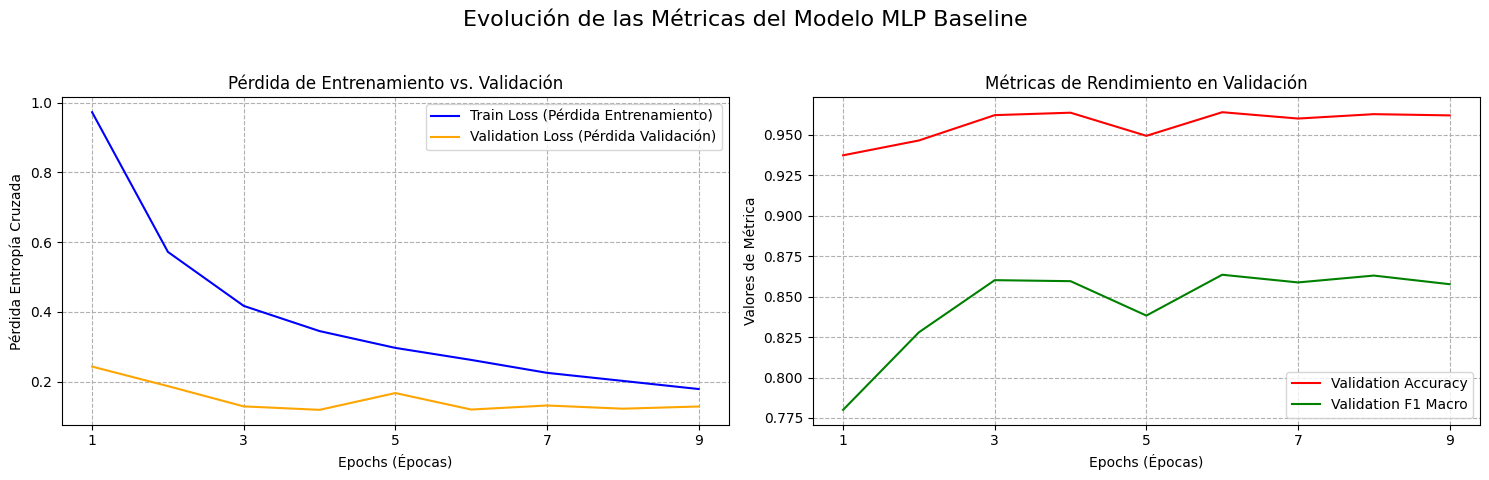

In [24]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.1,
                                            initial_dim=128)                                        
print(model_trained)

showTrainMetrics(history)

La rápida convergencia del modelo se atribuye a la robustez de la codificación por frecuencia de k-mers, la cual actúa como una señal estadística altamente distintiva para los biotipos de ARN. Esta señal, procesada por una arquitectura que proyecta inicialmente las entradas a un espacio de mayor dimensión (expandiendo de 64 a 128 neuronas) para desentrelazar características latentes antes de comprimirlas progresivamente, permite al modelo alcanzar un rendimiento casi óptimo desde la tercera época, consolidando su pico máximo de F1-Score en la novena. Al proyectar las entradas a un espacio de mayor dimensión le da al modelo más "espacio" para separar atributos relevantes.

No obstante, el elevado Accuracy reportado debe interpretarse con cautela debido al severo desbalanceo del dataset. Este valor refleja principalmente la eficacia del modelo en la clase mayoritaria, lo que tiende a inflar la métrica global. Por el contrario, el análisis del F1 Macro (que pondera equitativamente todas las clases) revela las limitaciones reales del modelo para generalizar correctamente en las categorías minoritarias.


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6971
           1       0.81      0.92      0.86       343
           2       0.78      0.89      0.83       435
           3       0.90      0.94      0.92       370
           4       0.69      0.76      0.72       185

    accuracy                           0.96      8304
   macro avg       0.84      0.90      0.86      8304
weighted avg       0.97      0.96      0.96      8304

Test AUC Macro (OVR): 0.9925
Test MCC: 0.8777


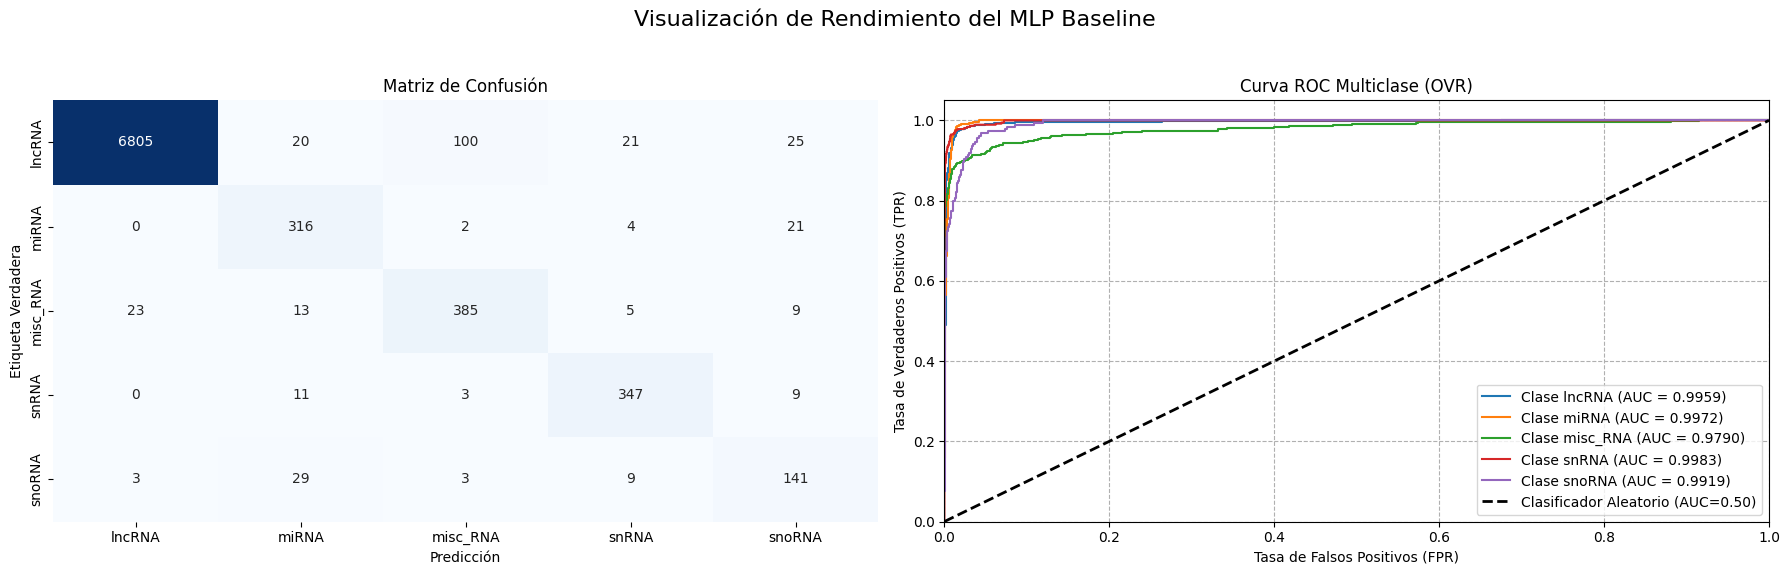

In [25]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

Analizando el desempeño en el conjunto de test, el modelo presenta un Accuracy del 96%, una cifra que a primera vista sugiere un rendimiento casi perfecto.  Este valor es engañoso debido al desbalanceo de clases, la clase mayoritaria (lncRNA) cuenta con 6.971 muestras en test, mientras que el resto suman apenas 1.300. El modelo podría ignorar las clases minoritarias y aun así mantener una exactitud artificialmente alta.

Por ello, métricas como el F1-Macro (0.86) y el MCC (0.8777) resultan más representativas, al tratar a todas las clases por igual. La caída de 10 puntos del F1-Macro respecto al Accuracy revela ciertas dificultades de generalización en las clases minoritarias. A pesar de esto, el MCC de 0.87 indica una correlación fuerte entre predicciones y etiquetas reales, ofreciendo una valoración global positiva del modelo baseline.

A nivel de clases individuales, el modelo muestra un rendimiento inferior en miRNA y snoRNA (Clases 4 y 2), que presentan los F1-Scores más bajos. Al observar las curvas ROC, destaca que la clase misc_RNA obtiene el AUC más bajo (0.9790), mostrando un ligero desplazamiento hacia la derecha (mayor tasa de Falsos Positivos).

La Matriz de Confusión esclarece estos errores:

Confusión misc_RNA vs lncRNA: Existe un solapamiento notable entre estas clases. Esto es coherente con el análisis descriptivo, que reveló que la clase misc_RNA es muy heterogénea, aglutina secuencias de ARN de características bastante dispares, y por lo tanto de longitudes muy distintas, dado que a este grupo se incoporaban todas aquellas cadenas de ARN que no parecían encajar en ningún otro. En el análisis descriptivo incial también se podía ver como esta clase tenía dos grupos bien diferenciados, uno de secuencias de longitud mediana, y otro de gran longitud. Al basarse en conteo de k-mers, el modelo tiende a confundir estas secuencias largas con los lncRNA, que también se caracterizan por su extensa longitud y por tanto un mayor recuento total de tokens.

Confusión snoRNA vs miRNA: La confusión entre estos biotipos sugiere que, bajo una representación de Bag-of-Words, sus perfiles de frecuencia de nucleótidos son muy similares, careciendo el modelo de la información contextual necesaria para distinguirlos eficazmente.



Cabe destacar que el rendimiento equilibrado del modelo, especialmente en las clases minoritarias, no es producto del azar, sino consecuencia directa de la implementación de la estrategia de Muestreo Ponderado (WeightedRandomSampler) en la etapa de carga de datos.

Dado el severo desbalanceo del dataset, un muestreo aleatorio estándar habría generado lotes de entrenamiento dominados casi exclusivamente por la clase mayoritaria (lncRNA), sesgando los gradientes y forzando al modelo a ignorar las clases menos representadas. Mediante el muestreo ponderado, asignamos una probabilidad de elección inversa a la frecuencia de cada clase, forzando al DataLoader a construir lotes artificialmente balanceados. 

In [26]:
print(class_to_idx)

{'lncRNA': 0, 'miRNA': 1, 'misc_RNA': 2, 'snRNA': 3, 'snoRNA': 4}


1. Iniciando extracción...
Forma de los Embeddings extraídos: (41516, 8)
2. Calculando reducción U-MAP (Configuración Coseno/Vecinos optimizada)...


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3. Generando gráfico...


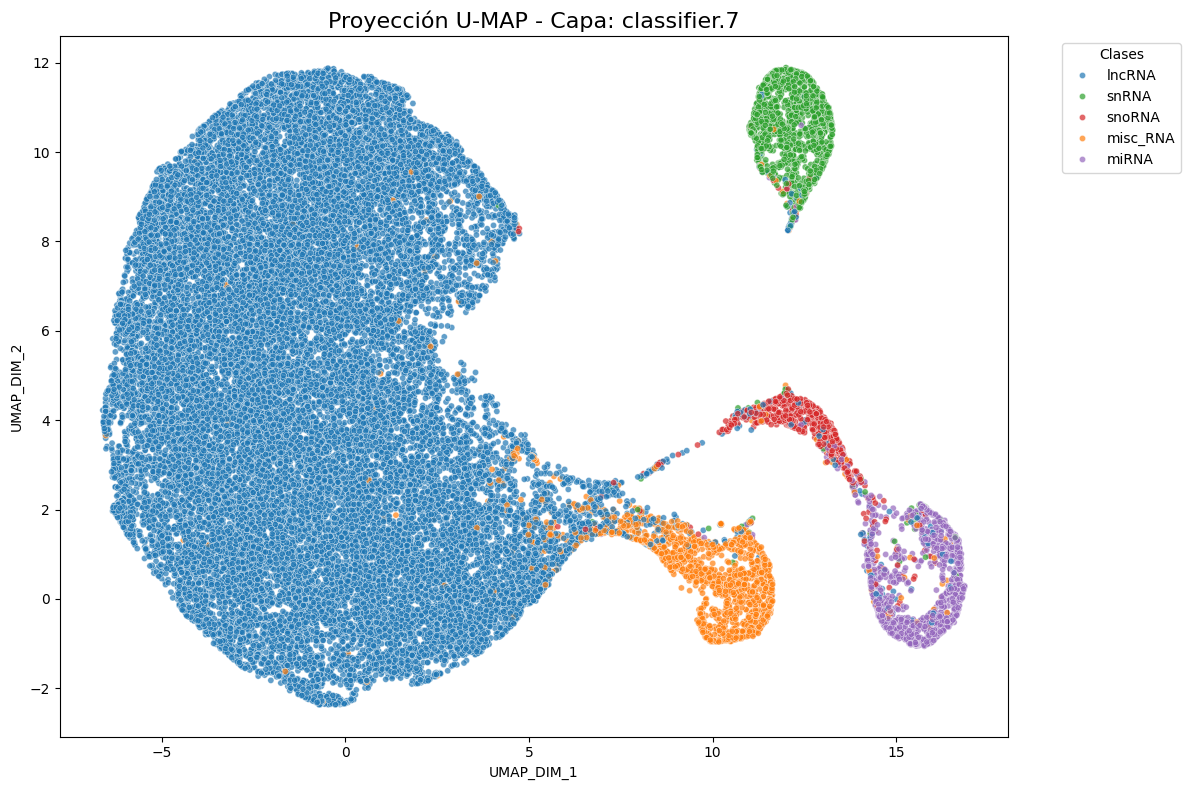

In [27]:
dataset = MLPDatasetBaseline(seqs, labels_numeric, vocabulario = stoi)
plot_Umap(model_trained, dataset, class_to_idx, layer_target='classifier.7')

Obtenemos la proyección de los embeddings de alta dimensionalidad de la penúltima capa del modelo en un espacio de 2 dimensiones. 


Esta proyección UMAP de los embeddings de la penúltima capa ofrece una validación visual de la capacidad discriminativa del modelo baseline. La topología del espacio latente muestra una estructura clara donde la clase mayoritaria (lncRNA, en azul) forma un núcleo denso y dominante, coherente con su alto Accuracy. La clase azul (lnRNA) tiene 35.000 muestras. Biológicamente, los lncRNA son extremadamente diversos (hay miles de familias dentro). Es muy probable que la "gran masa azul" contenga sub-estructuras ricas que se han perdido porque 8 dimensiones no son suficientes para desplegar toda esa variedad interna, especialmente con un input tan limitado como los k-mers. Esto podría ser una buena forma de continuar el trabajo, pero por ahora no disponemos de datos sobre las subclases del lnRNA.


La gráfica también revela las limitaciones del enfoque basado en frecuencias para las clases minoritarias:

La clase misc_RNA (naranja) actúa como un 'puente' parcialmente fusionado con los lncRNA, lo que explica visualmente la alta tasa de falsos positivos entre ambas categorías; el modelo no logra separar linealmente las secuencias misceláneas de las largas cadenas no codificantes.

Las clases snoRNA (rojo) y miRNA (morado) se agrupan en una región contigua y densa, confirmando que sus perfiles de k-mers son similares. Esta proximidad espacial justifica la confusión cruzada observada en la matriz de confusión, demostrando que la información de frecuencia es insuficiente para desagregar eficazmente estos dos biotipos cortos.

Por el contrario, la clase snRNA (verde) forma un clúster aislado y bien definido, indicando que posee características composicionales únicas que el modelo logra capturar sin ambigüedad.


Más allá de la distribución de clases, la existencia de estos "puentes" o zonas de transición continua entre clústeres ofrece una conclusión determinante para el proyecto hemos alcanzado el límite de la capacidad de la arquitectura baseline. Estos puentes no son artefactos producidos por la reducción de dimensionalidad, sino la evidencia visual de que la información composicional (conteo de k-mers) es insuficiente para una separabilidad perfecta.

Al entrenar al modelo exclusivamente con frecuencias, el MLP carece de contexto semántico secuencial. Para el modelo, dos secuencias que compartan la misma proporción de nucleótidos son idénticas, independientemente del orden en que estos aparezcan.

La conexión robusta entre la masa de lncRNA y misc_RNA indica que, en esa frontera, las secuencias son matemáticamente dificilmente distinguibles bajo esta codificación. Para el modelo, con la información disponible, esas clases son lo mismo. Esto justifica la necesidad de transicionar hacia modelos profundos como BERT/Transformers. Solo un modelo capaz de aprender representaciones contextuales podrá romper estos puentes, reorganizando el espacio latente basándose en la sintaxis de la secuencia y no solo en su estadística global.

Un modelo Transformers como el que plantearemos en el siguiente apartado podría entender mejor las secuencias y generar clústers mas separados que no tengan 'puentes' entre sí.

## ¿Qué ocurre si aumentamos la regularización aumentando el Dropout?

El modelo con el que trabajamos se trata de una arquitectura con bastante capacidad de aprendizaje (bastante músculo) para los datos que tenemos. Al trabajar con una entrada del tipo frecuencias de kmers (bag of words), existe un riesgo alto de que el modelo aprenda a clasificar basándose exclusivamente en la presencia o ausencia de unos pocos k-mers específicos en el conjunto de entrenamiento, en lugar de aprender el perfil composicional/estructural completo de las distintas clases. Un Dropout bajo permite que a la red le sea sencillo clasificar usando pocas características dominantes.
Con un dropout bajo consigue llegar a valores muy buenos del F1-score en pocas épocas, pero por su gran complejidad/capacidad podría no estar centrándose correctamente en las características importantes que permitan realmente distinguir a las secuencias.


En principio en el modelo baseline que hemos entrenado no hay signos de sobreajuste. En los logs de entrenamiento del Baseline MLP, se observa en la última época antes del Early Stopping un Train Loss de 0.1788 frente a un Val Loss de 0.1287. Es decir, la pérdida de validación es menor que en entrenamiento. Si hubiera sobreajuste tendríamos lo contrario, una Train Loss muy baja y una Val Loss alta o estancada. Al tener la Val Loss más baja, indica que el modelo generaliza bastante bien, pero para salir de dudas, vamos a aumentarle la regularización al modelo.


Si subimos el Dropout a 0.5, obligamos a la red a ser redundante, le forzamos a no confiar en un pocos k-mers para tomar la decisión, sino a buscar correlaciones más amplias y distribuidas entre múltiples contadores de frecuencias. Esto asegura que la predicción sea robusta incluso si una secuencia de test carece de ese k-mer específico pero mantiene el perfil global de la clase.

Dado que la red tiene capas ocultas que expanden la dimensionalidad (de 64 a 128 neuronas), el modelo tiene capacidad de sobra para memorizar combinaciones de frecuencias ruidosas que puedan ser casuales en el set de entrenamiento (especialmente en las clases minoritarias con pocas muestras). Aumentar el Dropout actúa como un mecanismo de 'ensemble' implícito: entrena múltiples sub-redes dentro del mismo modelo. Si el modelo mantiene su rendimiento bajo esta restricción, confirmaremos que está aprendiendo patrones biológicos genuinos (la distribución estadística real de los nucleótidos) y no simplemente memorizando 'huellas digitales' de las muestras de entrenamiento.

Hemos observado una convergencia extremadamente rápida (pico en época 3-6). Esto a menudo indica que el modelo encuentra un camino fácil de optimización muy rápido. Una regularización más fuerte suavizará esta curva de aprendizaje, evitando que los pesos crezcan desmesuradamente en direcciones específicas tan pronto. Esto podría ayudar a mejorar la generalización en las clases 'limítrofes' (como la frontera difusa que vimos en el UMAP entre snoRNA y miRNA), obligando al modelo a refinar su frontera de decisión en lugar de trazar una línea rápida y simplista.


## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 128 -> 32 -> 8 -> 5, Dropout : 0.5, lr = 3e-4

Epoch 1/30 | Train Loss: 1.3551 | Val Loss: 0.4990 | Val Acc: 0.9101 | Val F1 Macro: 0.6387
Epoch 2/30 | Train Loss: 1.0493 | Val Loss: 0.3110 | Val Acc: 0.9279 | Val F1 Macro: 0.6773
Epoch 3/30 | Train Loss: 0.9189 | Val Loss: 0.2155 | Val Acc: 0.9425 | Val F1 Macro: 0.7248
Epoch 4/30 | Train Loss: 0.8463 | Val Loss: 0.2176 | Val Acc: 0.9374 | Val F1 Macro: 0.7468
Epoch 5/30 | Train Loss: 0.7984 | Val Loss: 0.1964 | Val Acc: 0.9451 | Val F1 Macro: 0.7908
Epoch 6/30 | Train Loss: 0.7788 | Val Loss: 0.1857 | Val Acc: 0.9490 | Val F1 Macro: 0.8128
Epoch 7/30 | Train Loss: 0.7357 | Val Loss: 0.1788 | Val Acc: 0.9454 | Val F1 Macro: 0.8183
Epoch 8/30 | Train Loss: 0.7119 | Val Loss: 0.1951 | Val Acc: 0.9371 | Val F1 Macro: 0.8093
Epoch 9/30 | Train Loss: 0.6890 | Val Loss: 0.1859 | Val Acc: 0.9384 | Val F1 Macro: 0.8167
Epoch 10/30 | Train Loss: 0.6747 | Val Loss: 0.1695 | Val Acc: 0.9439 | Val F1 Macro: 0.8242
Epoch 11/30 | Train Loss: 0.6646 | Val Loss: 0.1812 | Val Acc: 0.9363 | Val F1 

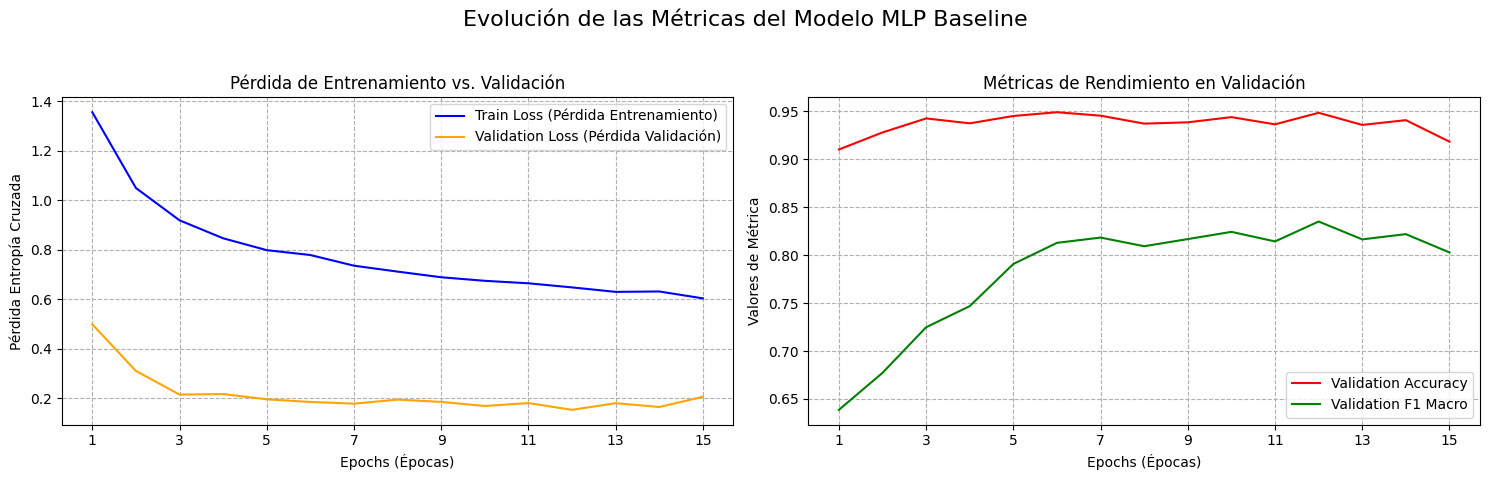

In [28]:

model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.5,
                                            initial_dim=128)                                        
print(model_trained)

showTrainMetrics(history)

Tras someter al modelo baseline a un régimen de alta regularización ($p=0.5$ en las capas ocultas), los resultados revelan ciertos cambios en el entrenamiento. Se observa una gran brecha sostenida entre la pérdida de entrenamiento y la de validación. La Train Loss se mantiene elevada (finalizando en ~0.60), mientras que la Val Loss desciende rápidamente hasta 0.2 aprox. Este comportamiento es característico de un Dropout agresivo. Durante el entrenamiento, la red opera con solo el 50% de su capacidad cerebral activa, lo que dificulta enormemente el ajuste a los datos de entrenamiento (de ahí la pérdida alta). Sin embargo, en validación, el Dropout se desactiva y la red utiliza todas sus neuronas simultáneamente. El hecho de que la Val Loss sea tan baja demuestra que, aunque no use toda su capacidad de aprendizaje, las características que logra aprender son robustas y generalizables.

También es destacable que a diferencia del modelo original, este presenta una convergencia más lenta y suave, esta variante necesita hasta la época 12 para alcanzar su mejor F1-Macro (0.8350). Al introducir un fuerte dropout, hemos eliminado los posibles atajos de convergencia. El modelo se ha visto obligado a explorar más lentamente, acumulando evidencia redundante antes de consolidar su aprendizaje. Esto confirma que la convergencia rápida del modelo anterior no era un fallo, sino una consecuencia de la fuerza de la señal estadística de los k-mers.

Si el modelo original hubiese estado memorizando ruido o dependencias frágiles, el Dropout de 0.5 habría destruido su capacidad predictiva (bajando el F1 considerablemente). El hecho de que mantenga un rendimiento competitivo (>83% F1) bajo condiciones tan adversas demuestra que la señal de frecuencia de k-mers es un predictor biológico sólido y real.


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      6971
           1       0.84      0.94      0.88       343
           2       0.46      0.89      0.61       435
           3       0.94      0.90      0.92       370
           4       0.59      0.84      0.69       185

    accuracy                           0.92      8304
   macro avg       0.76      0.90      0.81      8304
weighted avg       0.95      0.92      0.93      8304

Test AUC Macro (OVR): 0.9902
Test MCC: 0.7800


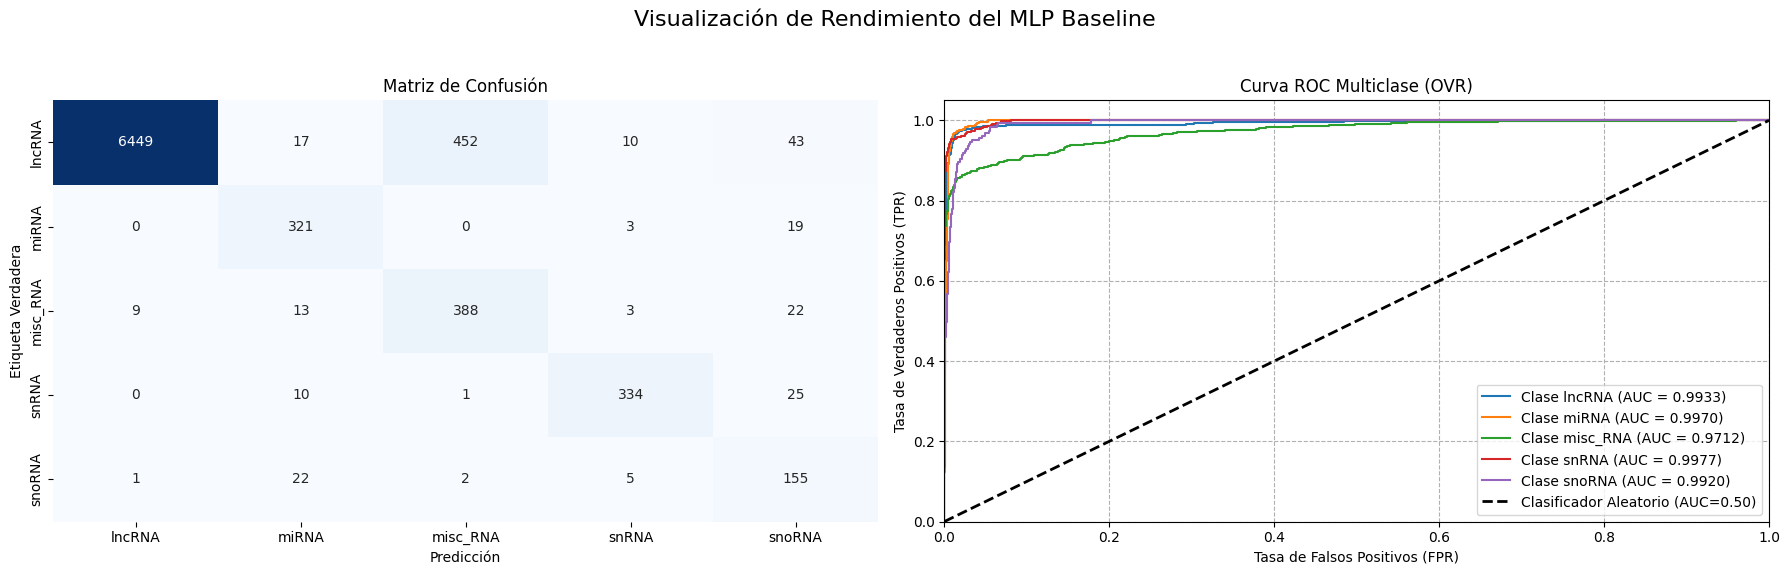

In [29]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

Al evaluar el modelo bajo alta regularización en el conjunto de test, observamos un descenso generalizado en las métricas principales respecto a la configuración original. El Accuracy cae al 92% (vs 96%) y el MCC desciende a 0.78 (vs 0.87), lo cual era de esperar al tener menos capacidad el modelo.Sin embargo, lo más revelador no es la caída global, sino cómo se han redistribuido los errores. El dato más alarmante es el desplome de la precisión en la clase misc_RNA (Clase 2), que cae a un 0.46. Lo indica que el modelo está generando una avalancha de Falsos Positivos en esta categoría, esto puede verse claramente también en su curva ROC. Al prescindir de la mitad de las neuronas, el modelo ha perdido parte de su capacidad de trazar fronteras precisas entre clases. Como puede verse en la matriz de confusión, este modelo ha optado por predecir a muchas secuencias de la clase lncRNA como misc_RNA, lo que a su vez nos indica que el modelo se ha vuelto bastante conservador con la clase mayoritaria. Solo predice lncRNA si está muy seguro. Las secuencias de lncRNA que antes detectaba bien pero que tenían características ligeramente atípicas, ahora, con la 'visión borrosa' del Dropout alto, no las clasifica como lncRNA y las envía erróneamente a otras clases (principalmente a misc_RNA, hundiendo la precisión de esta última).

A pesar del alto dropout, el snRNA mantiene un F1 de 0.92, confirmando de nuevo que su perfil de k-mers es distintivo y robusto. El miRNA mantiene un Recall alto (0.94), lo que también sugiere que su señal de 'secuencia corta y vacía' es fuerte y que ni siquiera un Dropout del 50% logra ocultarla.

Estos resultados refutan la necesidad de una regularización tan agresiva. Demostrando que un Dropout de 0.5 destruye información útil y sutil necesaria para resolver las fronteras de decisión complejas. Confirmamos así que el modelo original (con dropout=0.1) no estaba sobreajustado, sino que estaba aprovechando correctamente toda su capacidad para discernir matices que se pierden bajo una regularización excesiva.

1. Iniciando extracción...
Forma de los Embeddings extraídos: (41516, 8)
2. Calculando reducción U-MAP (Configuración Coseno/Vecinos optimizada)...


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3. Generando gráfico...


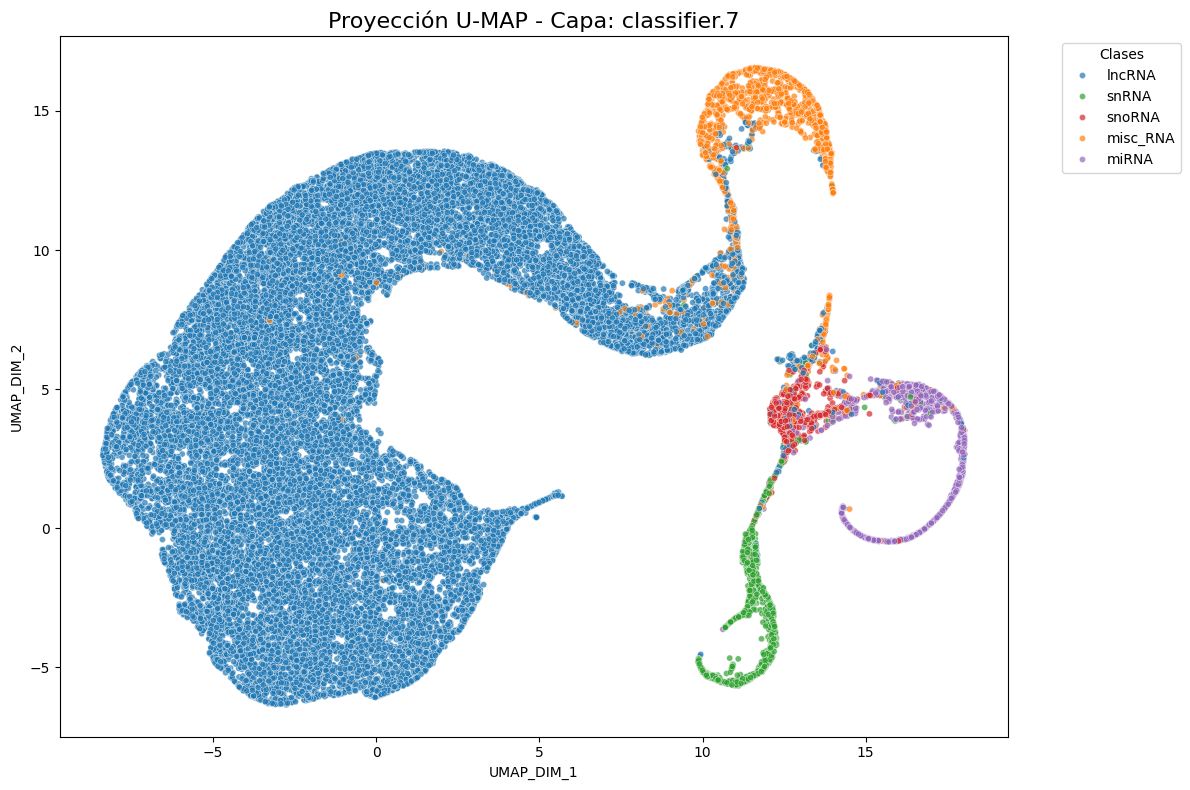

In [30]:
dataset = MLPDatasetBaseline(seqs, labels_numeric, vocabulario = stoi)
plot_Umap(model_trained, dataset, class_to_idx, layer_target='classifier.7')

La proyección UMAP del modelo altamente regularizado ofrece una representación visual de los efectos adversos de un Dropout excesivo. A diferencia de la estructura compacta observada en el modelo original, esta nueva topología muestra signos de dispersión y pérdida de cohesión, lo que corrobora la caída en el rendimiento de clasificación. Lo que primero que llama la atención es la formación de estructuras alargadas y en forma de espiral, especialmente visible en la clase miRNA (puntos morados) en el extremo derecho inferior.
Estas estructuras en forma de espirales suelen indicar que el modelo no ha logrado colapsar las clases en clústeres densos y definidos. El ruido introducido por el Dropout de 0.5 ha impedido que la red aprenda una representación invariante y robusta, dejando a las secuencias 'dispersas' en el espacio latente. El modelo no está seguro de dónde ponerlas, creando estos caminos difusos en lugar de grupos sólidos.

A pesar de la alta regularización, el 'puente' que conecta la masa azul (lncRNA) con la naranja sigue surgiendo, esto nos indica que la confusión entre lncRNA y misc_RNA no es producto de un sobreajuste (que se habría mejorado con regularización), sino una limitación intrínseca de los datos.
El intento de forzar una mejor generalización mediante alta regularización (dropout=0.5) resultó contraproducente, degradando la definición de los clústeres (como se ve en las espirales y la dispersión) y reduciendo la precisión en las clases difíciles.
Por tanto, validamos el modelo original (dropout=0.1) como el mejor baseline posible, aceptando que para romper los 'puentes' observados y compactar las espirales difusas, es necesario abandonar el enfoque de conteo de frecuencias e incorporar la atención contextual propia de los Transformers.

## ¿Qué ocurre si aumento la arquitectura del baseline? ¿Se estancará debido a la limitación de los datos?; Estudio de Escalabilidad de la Arquitectura


Probamos a escalar la arquitectura del baseline, aumentándola también a (256 --> 64 --> 16 -->5), luego a (512 --> 128 --> 32 -->5) y por último a (1024 --> 256 --> 64 -->5). Si no consigue realmente mucho mejores resultados que el primer baseline de (128--> 32 --> 8-->5), nos indica que se ha saturado, es decir habrá llegado a un punto en el que atender solamente al conteo de kmers y no a nada más, no nos permite mejorar el desempeño del modelo a pesar de incrementar muchísimo su arquitectura. Esto sugiere que la aproximación por conteo de K-mers puede tener un 'techo informativo' que la fuerza bruta computacional no puede romper.

Esto nos puede permitir descartar la posibilidad de que el rendimiento observado en el modelo baseline estuviera limitado por una falta de capacidad de computacional. Si la información necesaria para distinguir clases complejas reside en la sintaxis secuencial y no en la frecuencia de nucleótidos, aumentar el tamaño de la red neuronal baseline, solo conducirá a una saturación del rendimiento o al sobreajuste, pero no desbloqueará una mejor capacidad de generalización.

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 256 -> 64 -> 16 -> 5, Dropout : 0.1, lr = 3e-4

Epoch 1/30 | Train Loss: 0.7170 | Val Loss: 0.2248 | Val Acc: 0.9219 | Val F1 Macro: 0.7877
Epoch 2/30 | Train Loss: 0.3526 | Val Loss: 0.1371 | Val Acc: 0.9595 | Val F1 Macro: 0.8471
Epoch 3/30 | Train Loss: 0.2516 | Val Loss: 0.1275 | Val Acc: 0.9603 | Val F1 Macro: 0.8556
Epoch 4/30 | Train Loss: 0.1966 | Val Loss: 0.1200 | Val Acc: 0.9649 | Val F1 Macro: 0.8656
Epoch 5/30 | Train Loss: 0.1599 | Val Loss: 0.1240 | Val Acc: 0.9652 | Val F1 Macro: 0.8647
Epoch 6/30 | Train Loss: 0.1313 | Val Loss: 0.1244 | Val Acc: 0.9639 | Val F1 Macro: 0.8680
Epoch 7/30 | Train Loss: 0.1013 | Val Loss: 0.1256 | Val Acc: 0.9669 | Val F1 Macro: 0.8699
Epoch 8/30 | Train Loss: 0.0842 | Val Loss: 0.1677 | Val Acc: 0.9529 | Val F1 Macro: 0.8499
Epoch 9/30 | Train Loss: 0.0759 | Val Loss: 0.1424 | Val Acc: 0.9634 | Val F1 Macro: 0.8710
Epoch 10/30 | Train Loss: 0.0610 | Val Loss: 0.1541 | Val Acc: 0.9622 | Val F1 Macro: 0.8655
Epoch 11/30 | Train Loss: 0.0585 | Val Loss: 0.1687 | Val Acc: 0.9562 | Val F1 

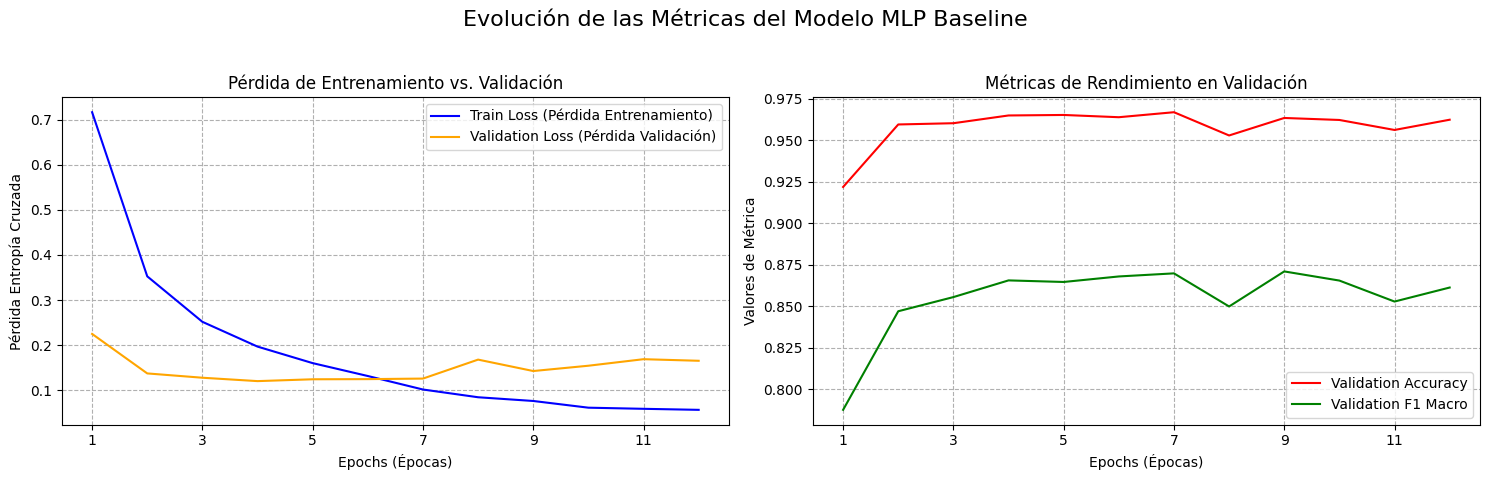

In [31]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.1,
                                            initial_dim=256)                                        #dropout de 0.45 como alternativa
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6971
           1       0.82      0.92      0.87       343
           2       0.71      0.89      0.79       435
           3       0.92      0.94      0.93       370
           4       0.84      0.72      0.78       185

    accuracy                           0.96      8304
   macro avg       0.86      0.89      0.87      8304
weighted avg       0.97      0.96      0.96      8304

Test AUC Macro (OVR): 0.9937
Test MCC: 0.8775


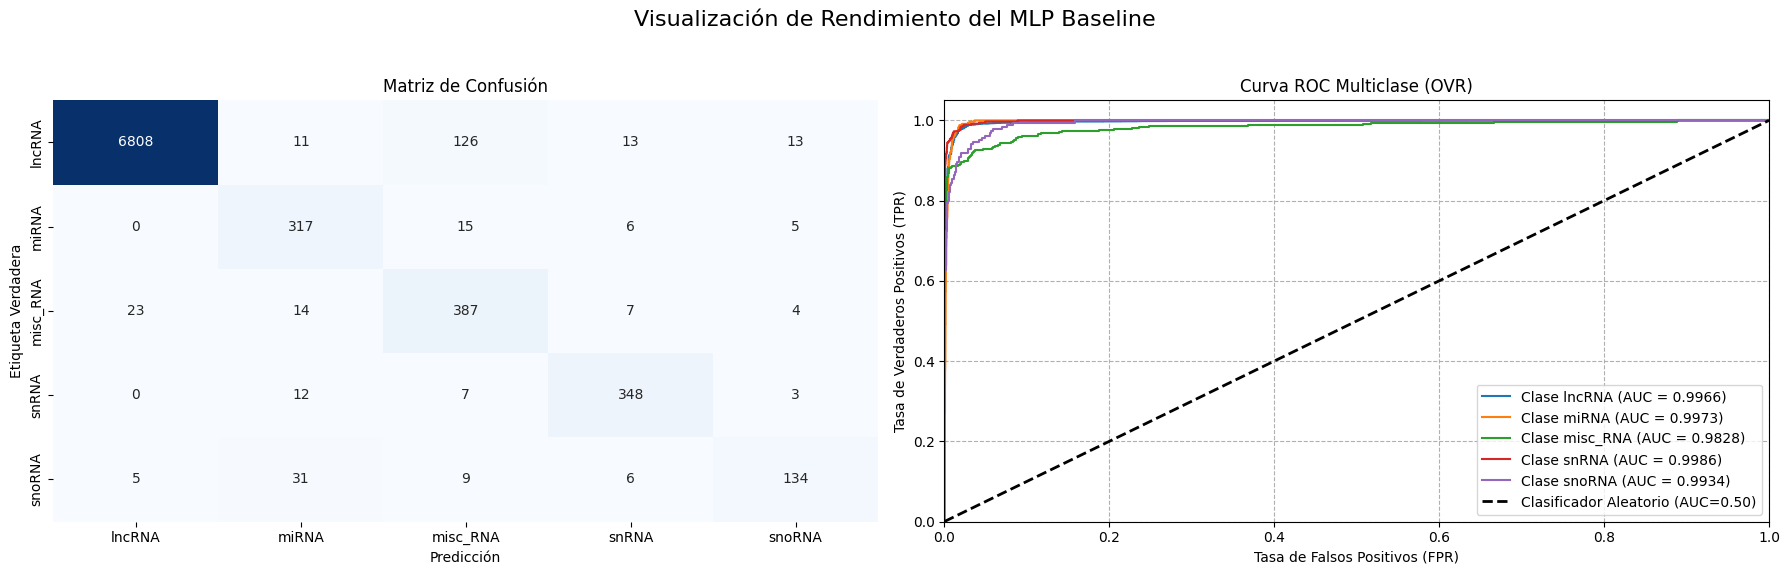

In [32]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 512 -> 128 -> 32 -> 5, Dropout : 0.1, lr = 3e-4

Epoch 1/30 | Train Loss: 0.5406 | Val Loss: 0.1309 | Val Acc: 0.9597 | Val F1 Macro: 0.8513
Epoch 2/30 | Train Loss: 0.2297 | Val Loss: 0.1521 | Val Acc: 0.9514 | Val F1 Macro: 0.8435
Epoch 3/30 | Train Loss: 0.1486 | Val Loss: 0.1207 | Val Acc: 0.9643 | Val F1 Macro: 0.8636
Epoch 4/30 | Train Loss: 0.1011 | Val Loss: 0.1221 | Val Acc: 0.9660 | Val F1 Macro: 0.8678
Epoch 5/30 | Train Loss: 0.0713 | Val Loss: 0.1364 | Val Acc: 0.9595 | Val F1 Macro: 0.8576
Epoch 6/30 | Train Loss: 0.0544 | Val Loss: 0.1558 | Val Acc: 0.9615 | Val F1 Macro: 0.8678
Epoch 7/30 | Train Loss: 0.0398 | Val Loss: 0.1397 | Val Acc: 0.9679 | Val F1 Macro: 0.8745
Epoch 8/30 | Train Loss: 0.0353 | Val Loss: 0.1444 | Val Acc: 0.9681 | Val F1 Macro: 0.8686
Epoch 9/30 | Train Loss: 0.0284 | Val Loss: 0.1359 | Val Acc: 0.9697 | Val F1 Macro: 0.8790
Epoch 10/30 | Train Loss: 0.0280 | Val Loss: 0.1487 | Val Acc: 0.9703 | Val F1 Macro: 0.8792
Epoch 11/30 | Train Loss: 0.0255 | Val Loss: 0.1479 | Val Acc: 0.9694 | Val F1 

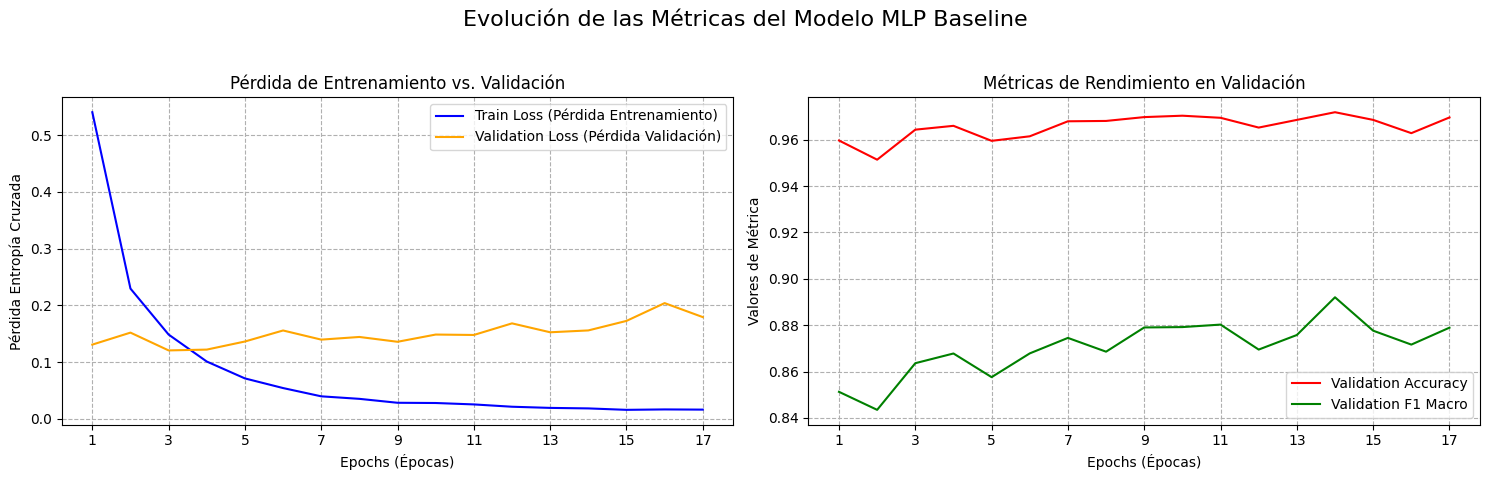

In [33]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.1,
                                            initial_dim=512)                                        #dropout de 0.45 como alternativa
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.85      0.92      0.88       343
           2       0.87      0.86      0.87       435
           3       0.90      0.94      0.92       370
           4       0.77      0.77      0.77       185

    accuracy                           0.97      8304
   macro avg       0.88      0.90      0.89      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9929
Test MCC: 0.9032


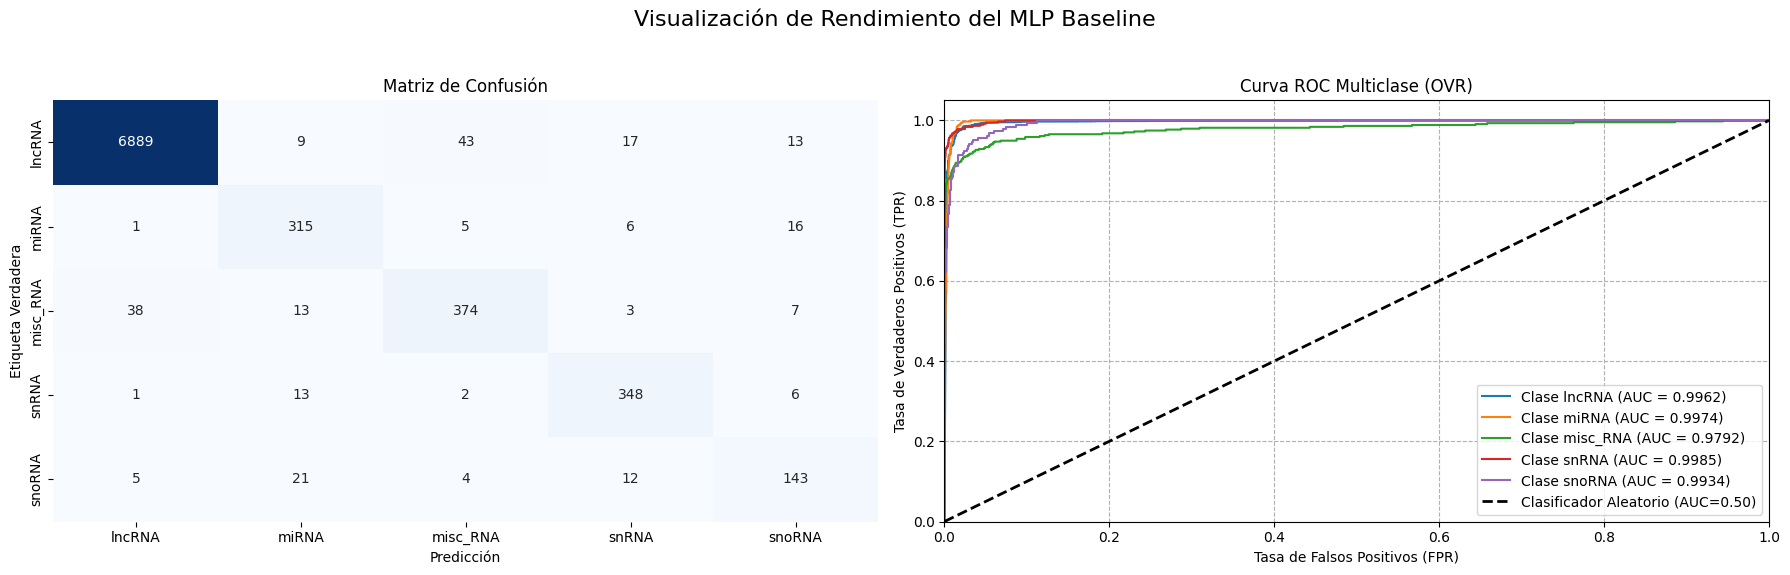

In [34]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 1024 -> 256 -> 64 -> 5, Dropout : 0.1, lr = 3e-4

Epoch 1/30 | Train Loss: 0.3910 | Val Loss: 0.1266 | Val Acc: 0.9601 | Val F1 Macro: 0.8512
Epoch 2/30 | Train Loss: 0.1440 | Val Loss: 0.2176 | Val Acc: 0.9342 | Val F1 Macro: 0.8259
Epoch 3/30 | Train Loss: 0.0788 | Val Loss: 0.1179 | Val Acc: 0.9719 | Val F1 Macro: 0.8847
Epoch 4/30 | Train Loss: 0.0476 | Val Loss: 0.1468 | Val Acc: 0.9654 | Val F1 Macro: 0.8721
Epoch 5/30 | Train Loss: 0.0362 | Val Loss: 0.1378 | Val Acc: 0.9699 | Val F1 Macro: 0.8842
Epoch 6/30 | Train Loss: 0.0271 | Val Loss: 0.1701 | Val Acc: 0.9624 | Val F1 Macro: 0.8677
!!! Early Stopping activado en la época 6. No hubo mejora en 3 épocas. !!!
Cargado el mejor estado del modelo antes de retornar.
MLPClassifierBaseline(
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=Fals

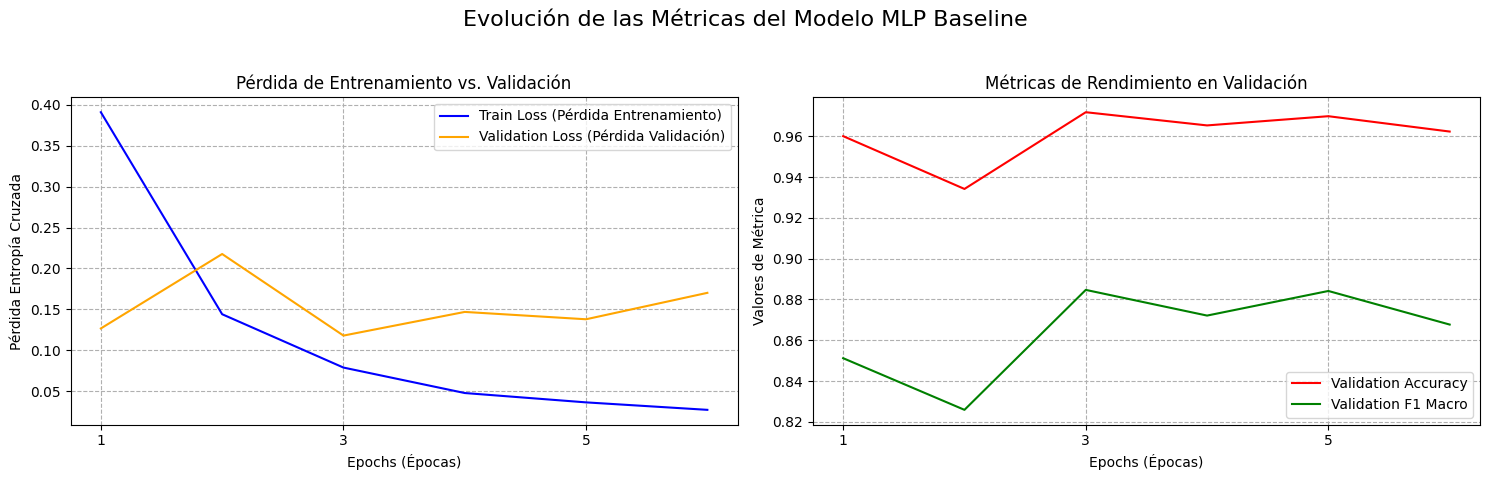

In [35]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.1,
                                            initial_dim=1024)                                        #dropout de 0.45 como alternativa
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      6971
           1       0.84      0.94      0.88       343
           2       0.71      0.89      0.79       435
           3       0.95      0.93      0.94       370
           4       0.78      0.78      0.78       185

    accuracy                           0.96      8304
   macro avg       0.85      0.90      0.87      8304
weighted avg       0.97      0.96      0.96      8304

Test AUC Macro (OVR): 0.9909
Test MCC: 0.8769


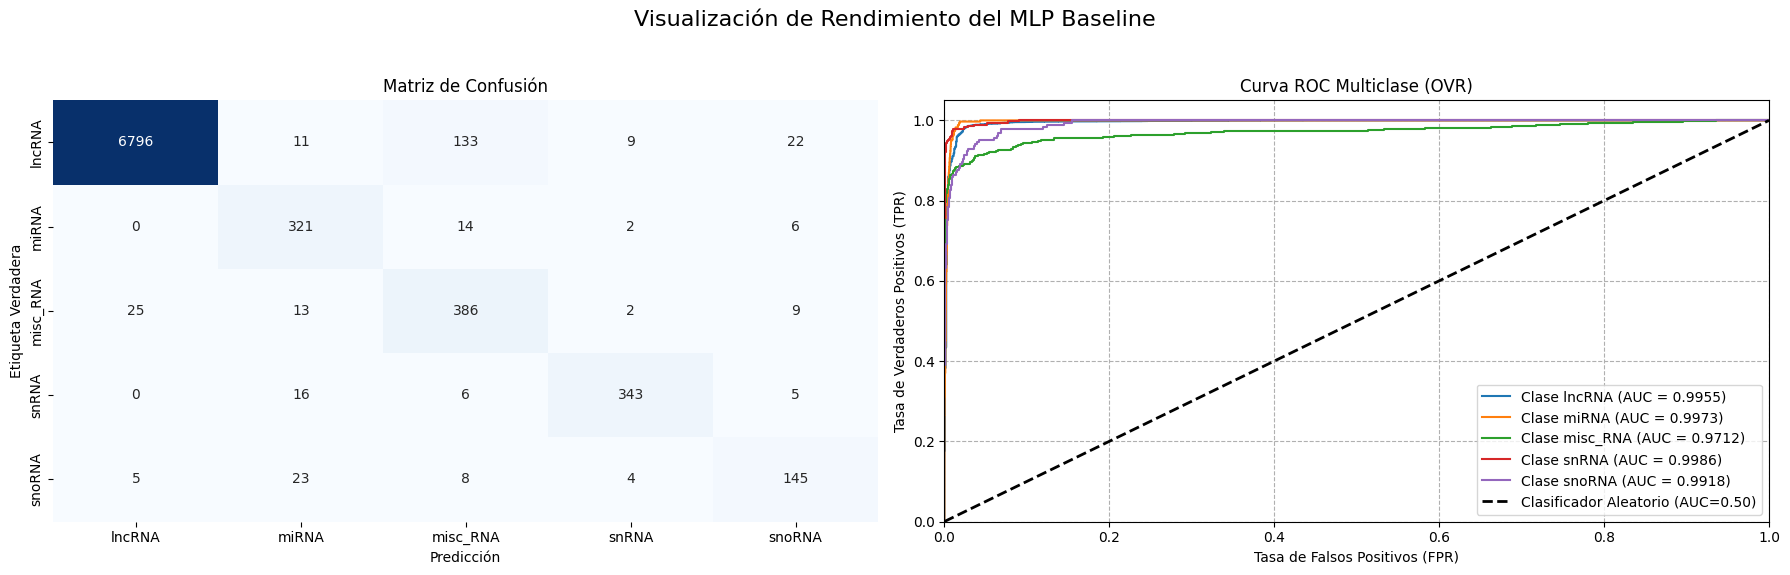

In [36]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

El experimento de escalado de arquitectura evidencia definitivamente de las limitaciones del enfoque actual. Se observa un claro estancamiento del rendimiento. A pesar de incrementar drásticamente la capacidad del modelo, el Coeficiente de Correlación de Matthews, se satura en torno a 0.88. La fuerza bruta computacional es incapaz de romper esta barrera. Además parece que al aumentar la capacidad se comienza a dar sobreajuste, ya que la pérdida en validación comienza a quedarse bastante por encima de la pérdida en train.

Cada vez el baseline mejora menos, es decir apenas mejora, para haber más que triplicado su complejidad. No consigue realmente mucho mejores resultados que el primer baseline de (128--> 32 --> 8-->5). Lo que nos indica claramente que se ha saturado, llega un punto en el que atender solamente al conteo de kmers, no nos permite mejorar el desempeño del modelo a pesar de incrementar muchísimo su arquitectura. Esto sugiere que la aproximación por conteo de K-mers tiene un 'techo informativo' que la fuerza bruta computacional no puede romper

El hecho de que modelos con capacidades de aproximación radicalmente distintas converjan al mismo límite de error (~0.12 en Validation Loss) demuestra que el cuello de botella no es la 'potencia cerebral' de la red, sino la calidad de la información de entrada. La representación Bag-of-Kmers contiene una cantidad finita de información discriminativa, una vez que el modelo extrae esas estadísticas, ninguna cantidad extra de neuronas puede generar nueva información donde no la hay.

Los resultados confirman que para superar el umbral de 0.88 en MCC y resolver la ambigüedad en las clases estructurales, debemos abandonar el conteo de frecuencias estáticas e incorporar un modelo capaz de extraer información semántica y secuencial. Esto justifica plenamente la transición a una arquitectur basada en Transformers (BERT), diseñadas específicamente para capturar las dependencias contextuales que el MLP, por diseño, no puede ver.

Probamos a aumentar el Dropout en estos modelos para conocer si un aumento de la regularización pudiera ayudar al modelo a aprovechar de mejor forma su incremental capacidad sin estancarse ni llegar al sobreajuste.

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 256 -> 64 -> 16 -> 5, Dropout : 0.5, lr = 3e-4

Epoch 1/30 | Train Loss: 1.1347 | Val Loss: 0.2188 | Val Acc: 0.9305 | Val F1 Macro: 0.7256
Epoch 2/30 | Train Loss: 0.7324 | Val Loss: 0.1546 | Val Acc: 0.9497 | Val F1 Macro: 0.8042
Epoch 3/30 | Train Loss: 0.5971 | Val Loss: 0.1497 | Val Acc: 0.9530 | Val F1 Macro: 0.8229
Epoch 4/30 | Train Loss: 0.5356 | Val Loss: 0.1364 | Val Acc: 0.9565 | Val F1 Macro: 0.8401
Epoch 5/30 | Train Loss: 0.4858 | Val Loss: 0.1208 | Val Acc: 0.9621 | Val F1 Macro: 0.8558
Epoch 6/30 | Train Loss: 0.4505 | Val Loss: 0.1106 | Val Acc: 0.9636 | Val F1 Macro: 0.8616
Epoch 7/30 | Train Loss: 0.4208 | Val Loss: 0.1219 | Val Acc: 0.9621 | Val F1 Macro: 0.8612
Epoch 8/30 | Train Loss: 0.3910 | Val Loss: 0.1109 | Val Acc: 0.9633 | Val F1 Macro: 0.8622
Epoch 9/30 | Train Loss: 0.3674 | Val Loss: 0.1391 | Val Acc: 0.9559 | Val F1 Macro: 0.8544
Epoch 10/30 | Train Loss: 0.3512 | Val Loss: 0.1273 | Val Acc: 0.9589 | Val F1 Macro: 0.8568
Epoch 11/30 | Train Loss: 0.3371 | Val Loss: 0.1581 | Val Acc: 0.9461 | Val F1 

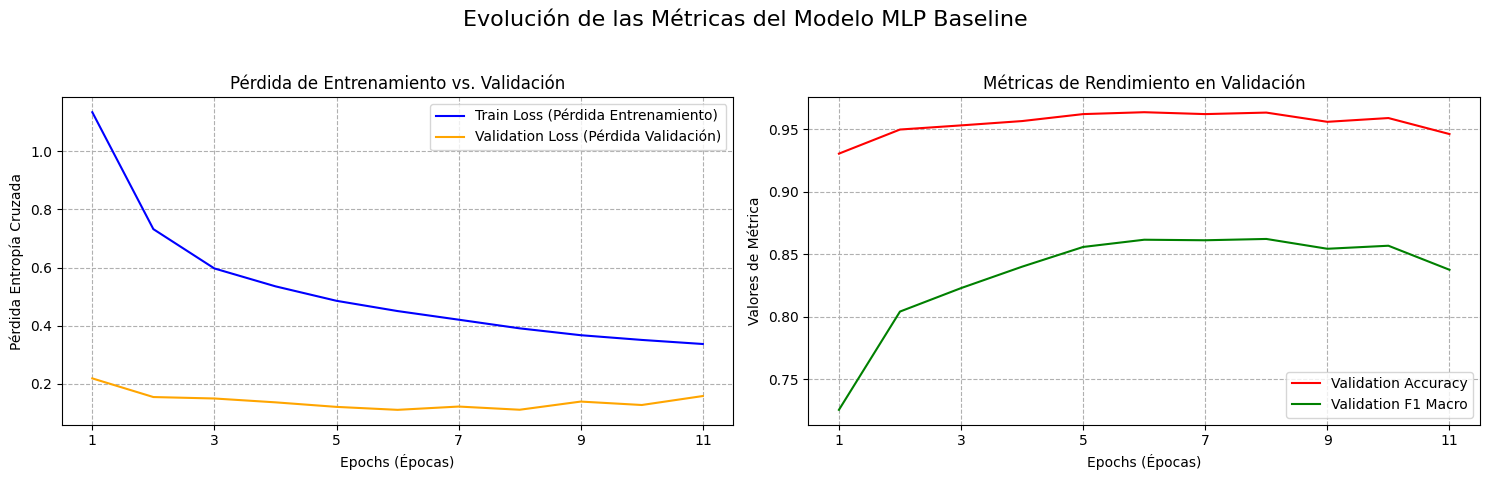

In [37]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.5,
                                            initial_dim=256)                                        
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      6971
           1       0.81      0.96      0.88       343
           2       0.63      0.89      0.74       435
           3       0.92      0.93      0.93       370
           4       0.65      0.81      0.72       185

    accuracy                           0.95      8304
   macro avg       0.80      0.91      0.85      8304
weighted avg       0.96      0.95      0.95      8304

Test AUC Macro (OVR): 0.9922
Test MCC: 0.8428


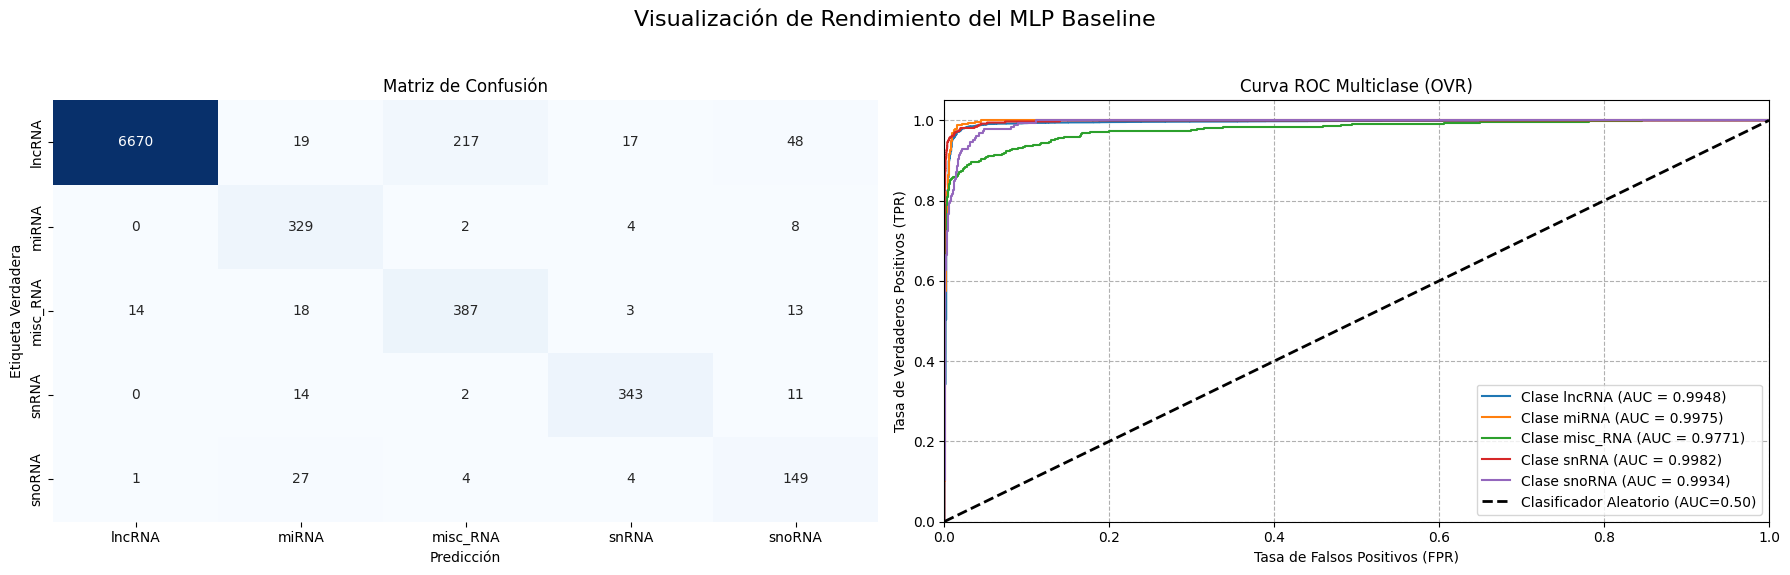

In [38]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 512 -> 128 -> 32 -> 5, Dropout : 0.5, lr = 3e-4

Epoch 1/30 | Train Loss: 0.9171 | Val Loss: 0.1980 | Val Acc: 0.9402 | Val F1 Macro: 0.7971
Epoch 2/30 | Train Loss: 0.4971 | Val Loss: 0.1496 | Val Acc: 0.9544 | Val F1 Macro: 0.8386
Epoch 3/30 | Train Loss: 0.3838 | Val Loss: 0.1196 | Val Acc: 0.9619 | Val F1 Macro: 0.8561
Epoch 4/30 | Train Loss: 0.3293 | Val Loss: 0.1200 | Val Acc: 0.9625 | Val F1 Macro: 0.8601
Epoch 5/30 | Train Loss: 0.2784 | Val Loss: 0.1108 | Val Acc: 0.9655 | Val F1 Macro: 0.8671
Epoch 6/30 | Train Loss: 0.2421 | Val Loss: 0.1621 | Val Acc: 0.9526 | Val F1 Macro: 0.8515
Epoch 7/30 | Train Loss: 0.2159 | Val Loss: 0.1245 | Val Acc: 0.9637 | Val F1 Macro: 0.8683
Epoch 8/30 | Train Loss: 0.2039 | Val Loss: 0.1267 | Val Acc: 0.9627 | Val F1 Macro: 0.8642
Epoch 9/30 | Train Loss: 0.1767 | Val Loss: 0.1333 | Val Acc: 0.9625 | Val F1 Macro: 0.8710
Epoch 10/30 | Train Loss: 0.1737 | Val Loss: 0.1326 | Val Acc: 0.9637 | Val F1 Macro: 0.8684
Epoch 11/30 | Train Loss: 0.1625 | Val Loss: 0.1261 | Val Acc: 0.9679 | Val F1 

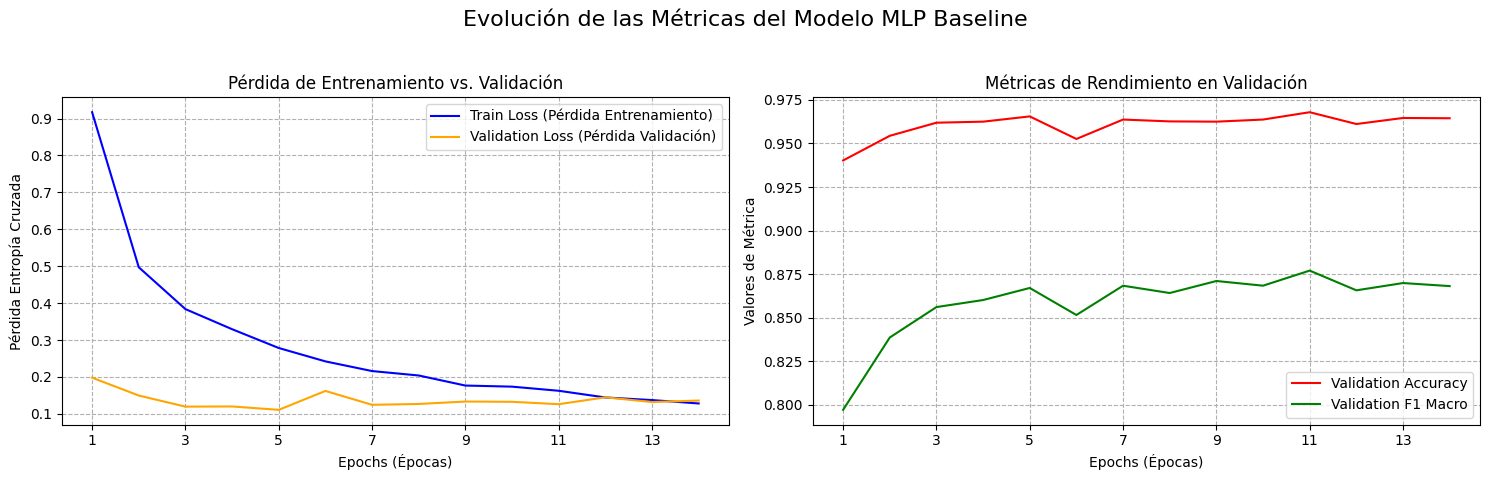

In [39]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.5,
                                            initial_dim=512)                                        
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      6971
           1       0.82      0.95      0.88       343
           2       0.80      0.88      0.84       435
           3       0.96      0.92      0.94       370
           4       0.67      0.83      0.74       185

    accuracy                           0.97      8304
   macro avg       0.85      0.91      0.88      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9931
Test MCC: 0.8874


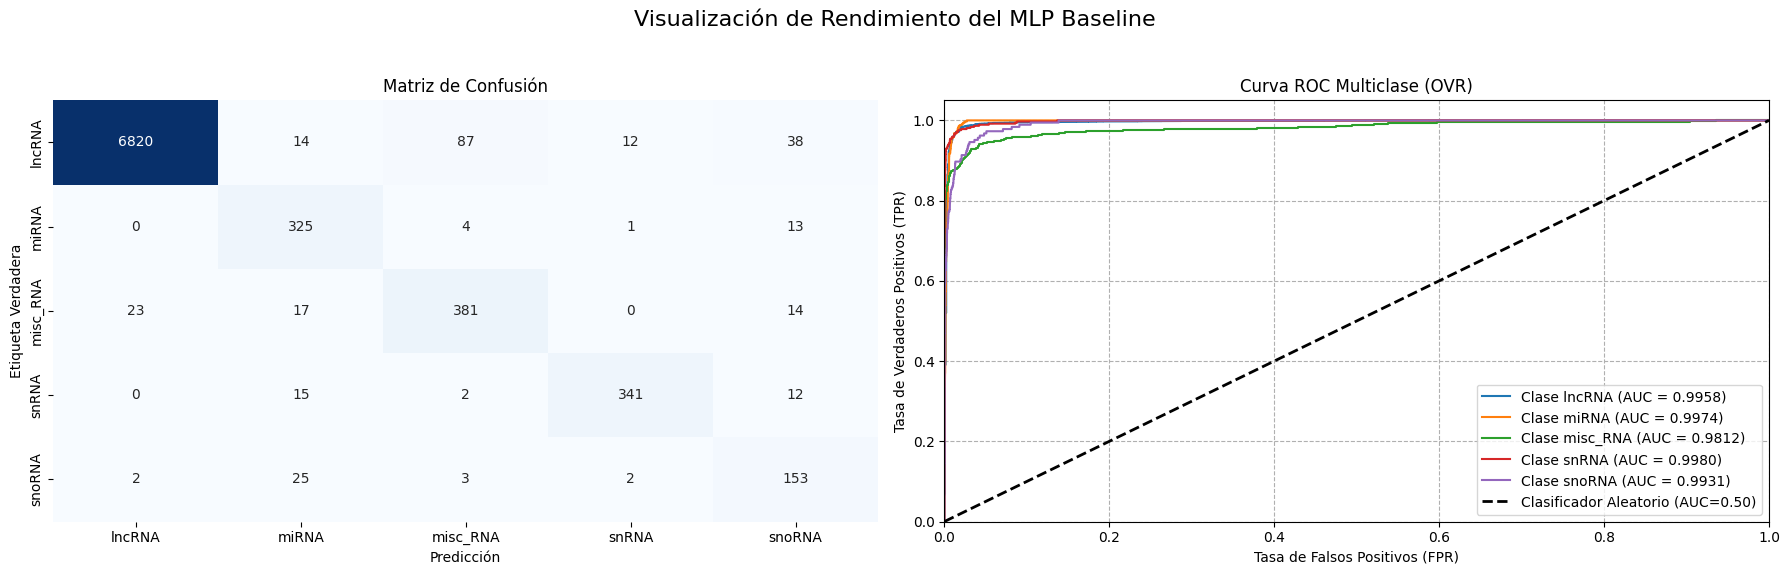

In [40]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

## Experimentación: Usamos el modelo baseline con la arquitectura: 64(input) -> 1024 -> 256 -> 64 -> 5, Dropout : 0.5, lr = 3e-4

Epoch 1/30 | Train Loss: 0.6714 | Val Loss: 0.1608 | Val Acc: 0.9536 | Val F1 Macro: 0.8334
Epoch 2/30 | Train Loss: 0.3257 | Val Loss: 0.1361 | Val Acc: 0.9577 | Val F1 Macro: 0.8477
Epoch 3/30 | Train Loss: 0.2421 | Val Loss: 0.1413 | Val Acc: 0.9594 | Val F1 Macro: 0.8580
Epoch 4/30 | Train Loss: 0.1889 | Val Loss: 0.1282 | Val Acc: 0.9630 | Val F1 Macro: 0.8609
Epoch 5/30 | Train Loss: 0.1566 | Val Loss: 0.1424 | Val Acc: 0.9604 | Val F1 Macro: 0.8595
Epoch 6/30 | Train Loss: 0.1362 | Val Loss: 0.1388 | Val Acc: 0.9634 | Val F1 Macro: 0.8694
Epoch 7/30 | Train Loss: 0.1191 | Val Loss: 0.1377 | Val Acc: 0.9654 | Val F1 Macro: 0.8759
Epoch 8/30 | Train Loss: 0.1022 | Val Loss: 0.1691 | Val Acc: 0.9594 | Val F1 Macro: 0.8630
Epoch 9/30 | Train Loss: 0.0962 | Val Loss: 0.1443 | Val Acc: 0.9655 | Val F1 Macro: 0.8760
Epoch 10/30 | Train Loss: 0.0811 | Val Loss: 0.1332 | Val Acc: 0.9681 | Val F1 Macro: 0.8841
Epoch 11/30 | Train Loss: 0.0811 | Val Loss: 0.1592 | Val Acc: 0.9666 | Val F1 

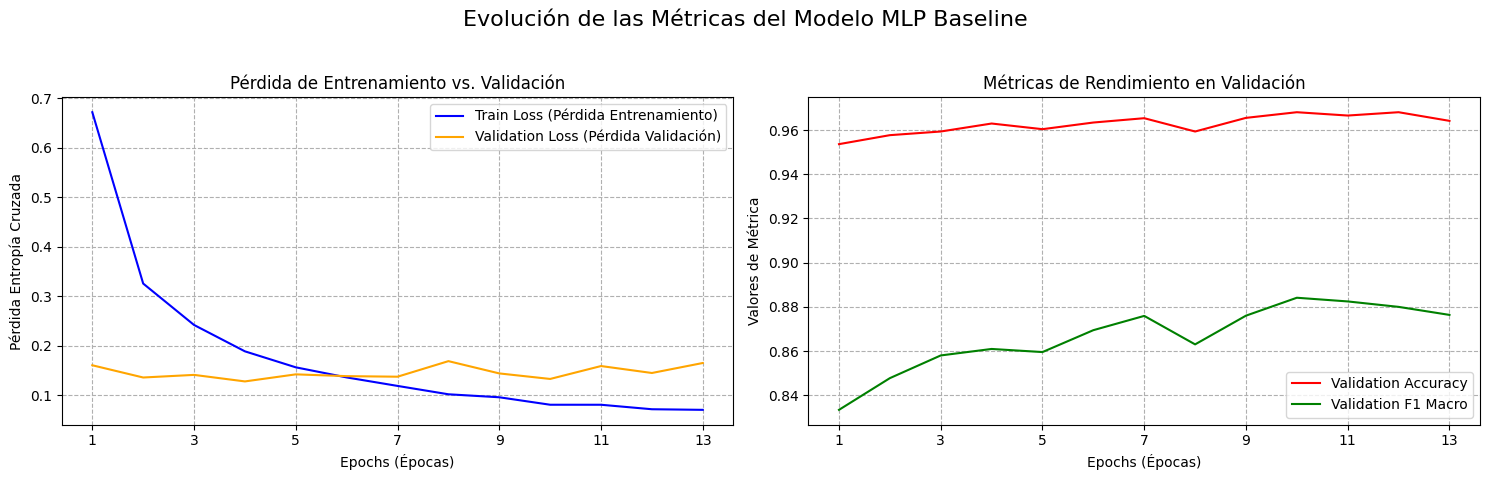

In [41]:
model_trained, history = train_MLP_baseline(dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            sampler = sampler, loss_weights= None, patience = 3, dropout = 0.5,
                                            initial_dim=1024)                                        
print(model_trained)

showTrainMetrics(history)


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      6971
           1       0.83      0.95      0.89       343
           2       0.73      0.89      0.80       435
           3       0.95      0.94      0.94       370
           4       0.75      0.85      0.80       185

    accuracy                           0.96      8304
   macro avg       0.85      0.92      0.88      8304
weighted avg       0.97      0.96      0.97      8304

Test AUC Macro (OVR): 0.9919
Test MCC: 0.8829


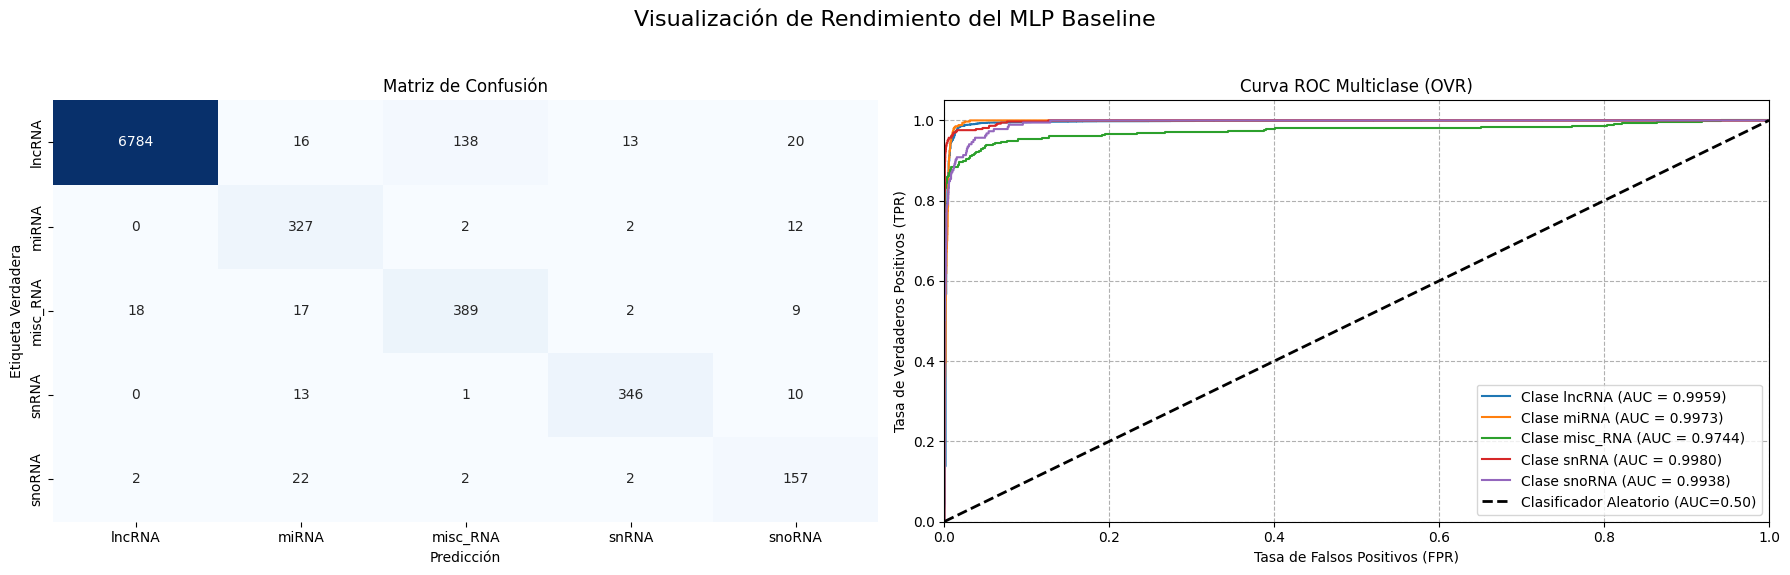

In [42]:
ac, f1, cf_matrix, roc_curve_data = test_model(model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas)

Confirmamos que un aumento del DropOut mitiga toda posibilidad de sobreajuste pero limita la capacidad del modelo, por lo que se evidencia aún más el estancamiento de esta arquitectura...

# Adición Cabezal del lenguaje a Encoder para Clasificación.

## Dataset

Los Dataset en la tarea de clasificación básica, para trabajar con el modelo baseline que no hace uso del encoder bert, estaban compuestos por secuencias codificadas al tamaño del vocabulario (sin tokens especiales, 64 tokens totales). Cada secuencia se codificaba como un vector en el que en la posición correspondiente a cada token del vocabulario guardaba la frecuencia de aparición de dicho token en la secuencia. (Bag of words)

Mientras que los Dataset para esta segunda tarea de clasificación, en la que sí se hace uso del encoder bert, debemos preservar el orden de los nucleótidos, codificamos las secuencias como vectores de índices (enteros) de dimensionalidad 512 (tamaño máximo de secuencias con las que decidimos trabajar). En cada posición de la secuencia codificada, se guarda el índice en el vocabulario, del token que alberga dicha posición en la secuencia real. Así la secuencia cruda se convierte en tokens (k-mers) y cada token se sustituye por su índice numérico en el vocabulario. Esto permite al modelo trabajar con tensores numéricos en lugar de cadenas de texto.
A todas las secuencias se les añade por convención un token artificial extra CLS que se coloca en la primera posición de la secuencia. El cual tiene una función de 'agregador de información', persiguiendo el propósito de guardar el contexto resumido de toda la secuencia (de todos los tokens de la secuencia). Tras pasar por todas las capas de atención del Transformer, el embedding resultante en la posición del [CLS] contendrá una representación latente resumida de toda la secuencia. De esta forma si a porteriori, tras las capas transformers queremos llevar a cabo una tarea dowstream de clasificación (como es el caso), en la que tengamos que reducir la representaciones latentes de las secuencias a un único embedding por secuencia, en lugar de un embedding por cada token de la secuencia, podamos usar dicho token CLS que resume a toda la secuencia.

Dado que las redes neuronales requieren tensores rectangulares (batch), las secuencias más cortas que la longitud máxima (512) se rellenan con el token [PAD]. Adicionalmente, se genera una Máscara de Atención (attn), un vector binario que indica al modelo qué posiciones son datos reales (1) y cuáles son relleno (0), evitando que el ruido del padding afecte al aprendizaje.
Sin embargo, aquellas que superen la longitud máxima posible (512) deben recortarse. La forma de recortarla depende de si el dataset resultante va a servir para el entrenamiento o para pruebas. 
En Validación/Test se aplica un recorte determinista (se conservan los primeros 512 tokens). Esto garantiza la reproducibilidad de las métricas.

Mientras que en entrenamiento el Dataset recorta las secuencias por un índice aleatorio, recorte estocástico, de forma que en cada época estas secuencias más largas pueden variar, permitiendo que el modelo vea diferentes partes de una secuencia larga en diferentes épocas, mejorando su capacidad de generalización

In [36]:


class DownstreamTaskDataset(Dataset):

    def __init__(self, seqs, labels, max_len=512, K = 3, training_mode = True): #Esa max_len es la longitud máxima de la secuencia tokenizada (num nucleótidos secuencia/3)
        super().__init__()
        self.K = K
        #Ojo que las labels, están como cadena de caracteres, 
        self.data = [(s, l) for s, l in zip(seqs, labels) if len(s) >= self.K+1]
        self.seqs, self.labels = map(list, zip(*self.data))
        self.max_len = max_len
        assert isinstance(training_mode, bool) 
        self.training = training_mode

    def __len__(self): return len(self.seqs)

    def __getitem__(self, idx):
        s = self.seqs[idx]
        y = self.labels[idx]
        toks = [CLS] + seq_to_kmers(s, self.K)
        if len(toks) > self.max_len:
            if self.training:
                start = random.randint(0, len(toks)-self.max_len)
                toks = toks[start:start+self.max_len]
                toks[0] = CLS
            else:
                toks = toks[:self.max_len]
        else:
        #Si la longitud de la secuencia tokenizada es menor que la máxima impuesta, como los embeddings deben tener todos la misma dimensión
        #para el correcto procesamiento internamente dentro del modelo, rellenamos la secuencia con tokens de padding
            toks = toks + [PAD]*(self.max_len - len(toks))
            
        attn = [1 if tok!=PAD else 0 for tok in toks]
        return torch.tensor(toks), torch.tensor(y), torch.tensor(attn) #Convierte las listas de Python a torch.tensor, el formato que PyTorch necesita para la computación


## Transformer con Cabeza de Clasificación

Para construir el nuevo modelo de clasificación (encoder + cabeza) necesitamos hacer uso del encoder TinyRNATransformer.
El modelo propuesto, denominado TinyRNATransformer, es una arquitectura de aprendizaje profundo basada en el paradigma Transformer Encoder-Only (similar a BERT), diseñada como una versión compacta y computacionalmente eficiente para el aprendizaje de representaciones de secuencias de ARN. Estructuralmente, la red consta de una pila de 4 bloques encoder secuenciales, donde cada bloque opera con una dimensionalidad interna de $d_{model}$ y emplea un mecanismo de auto-atención de 4 cabezales ($n_{heads}=4$) en cada bloque, lo que permite al modelo capturar dependencias contextuales tanto locales como globales.  
La arquitectura de cada bloque integra capas Feed-Forward con una dimensión de $d_{ff}$ y función de activación GELU.
El encoder procesa como entrada la suma embeddings de tokens y embeddings posicionales aprendibles para una ventana de contexto de 512 tokens (longitud máxima definida por defecto en el dataset), tras la pila de bloques transformers, se normaliza su salida y el modelo finaliza con una capa de proyección lineal (lm_head) que mapea las representaciones latentes al tamaño del vocabulario para la generación de logits, lo cual es necesario para la tarea de aprendizaje enmascarado, pero debe evitarse en la tarea de clasificación.

In [37]:

class TinyRNATransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=4, n_layers=4, d_ff=512, max_len=512, pdrop=0.1):
        super().__init__()
        #Creación de los embeddings fijos de entrada al modelo (embedding semánticos y posicionales)
        self.tok = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos = nn.Embedding(max_len, d_model)
        #Creación de una instacia de bloque transformer tipo encoder (compuesto por la arquitectura típica del transformer del paper de 'Attentio is all you need')
        enc_layer = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout=pdrop, batch_first=True, activation="gelu")
        #Creación de un Encoder completo con tantos bloques transformers como indique el parámetro n_layers. 
        #Al crear el encoder de esta manera, todos los bloques transformers que lo componen, tienen las mismas características e hiperparámetros
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        #Capa de normalización adicional, que le añadimos arbitrariamente al encoder (no forma parte de ningun bloque transfomer) para completar el modelo
        # y ecitar crecimiento excesivo de los pesos. Véase como esta capa de normalización No reduce la dimensionalidad de los embeddings 
        # de salida de los bloques Transformer.
        self.norm = nn.LayerNorm(d_model)
        #Haremos uso también en el modelo de una última capa lineal, que reduce la dimensionalidad de los embeddings que provienen de los bloques transformers
        #de 256 dim al tamaño del vocabulario. Así tendremos como salida un vector del tamaño del vocabulario en el que cada posición guarda el logit (o probabilidad, todavía sin pasar por la softmax)
        # de que el token correspondiente a su posición sea el faltante.
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, attn_mask): #Recibe como parámetro el batch y el registro de tokens de padding
        """En los módulos forward en pytorch es donde se describe el fujo de datos interno a lo largo de todo el modelo.
        Si creamos nuestro propio modelo, como es el caso, debemos crearlo como una clase, y en el módulo forward especificar como será el
        flujo de datos a través de este. Si además en el interior del modelo hacemos uso de capas que a su vez pudieran conformar un modelo 
        en sí mismo, estas tendrán sus propios métodos forward internos que se activan automáticamente conforme entran en juego esas capas."""
        B, T = x.shape
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T) #Creación de un tensor con tantas filas como secuencias en el batch, y casa posición es a su vez un listado de posiciones de los tokens en la secuencia
        h = self.tok(x) + self.pos(pos_ids) #¿Cómo funciona
        key_padding_mask = (attn_mask == 0)  # True where padding
        h = self.encoder(h, src_key_padding_mask=key_padding_mask)
        #El encoder no tiene esos parámetros específicamente, sin embargo al pasarle esos parámetros, se está invocando automáticamente el método mágico __call__
        #de la clase padre nn.Module de la que hereda, lo que activa el método forward del TransformerEncoder (no confundir con este método forward aquí definido)
        #Digamos que todos los modelos en pytorch deben tener su propio método forward
        h = self.norm(h)
        logits = self.lm_head(h)
        return logits



El modelo ClassificationTransformer actúa como una arquitectura diseñada para adaptar el encoder de lenguaje TinyRNATransformer a la tarea downstream de clasificación supervisada de biotipos. 

El modelo se construye sobre dos componentes principales: El encoder, se reutilizan las capas fundamentales del modelo de lenguaje (Embeddings, Encoder Layers y LayerNorm), descartando la capa final de proyección (lm_head) utilizada para el pre-entrenamiento MLM, ya que su dimensionalidad y propósito no son compatibles con la clasificación. Y el Cabezal de Clasificación, se acopla un Perceptrón Multicapa (MLP) con exáctamente la misma arquitectura que el modelo baseline, el cual proyecta la representación latente de la secuencia ($d=128$) hacia el espacio de las clases objetivo ($C=5$).

La clase que instancia al modelo implementa una lógica híbrida de inicialización que soporta tres regímenes de aprendizaje: 

i).Entrenamiento desde Cero, si no se proporciona un modelo pre-entrenado, se instancia un nuevo encoder con pesos aleatorios.
ii).Fine-Tuning Completo, se cargan los pesos del modelo pre-entrenado y se mantienen todos los parámetros descongelados (requires_grad=True), permitiendo que el encoder adapte sus representaciones a la tarea específica
iii). Entrenamiento de solo la cabeza con Encoder Congelado, en el que mediante el parámetro freeze_encoder=True, se congelan los pesos del encoder base. En este modo, el encoder actúa como un extractor de características estático y solo se optimizan los pesos del MLP de clasificación, lo que reduce drásticamente el coste computacional y el riesgo de sobreajuste en datasets pequeños.

Dado que el encoder Transformer devuelve una secuencia de vectores cúbica, de forma (batch_size, Longitud Secuencias, dimensionalidad embeddings), es necesario reducir esta matriz a un único vector representativo para que actúe de entrada en el clasificador. 
El modelo implementa dos estrategias para reducir la salida del encoder a una entrada adecuada para la cabeza: La primera estrategia consiste simplemente en usar el Token CLS, se extrae únicamente el vector correspondiente al primer token ([CLS]). Esta es la estrategia estándar en BERT, asumiendo que este token ha agregado la información global gracias al mecanismo de auto-atención.
Mientras que la segunda estrategia consiste en hacer un Mean Pooling, se calcula el promedio de los embeddings de todos los tokens de la secuencia. Esta operación es sensible a la máscara de atención (attn_mask): el algoritmo ignora matemáticamente los vectores correspondientes al padding, garantizando que el promedio no se diluya con información irrelevante (ceros). Esta opción ofrece una representación más robusta cuando el pre-entrenamiento del token [CLS] ha sido insuficiente.


In [38]:


class ClassificationTransformer(nn.Module):
    def __init__(self, pretrained_model, classification_head, num_classes, initial_dim, freeze_encoder=True, dropout_mlp=0.5, mean_pooling = False):
        super().__init__()
        assert isinstance(freeze_encoder, bool)
        assert isinstance(mean_pooling, bool)

        self.mean_pooling = mean_pooling

        #Capas del modelo Pre-entrenado por MLM
        #NOTA IMPORTANTE, no extraemos la capa lm_head del modelo preentrenado, ya que esa capa tenía como prpósito el aprendizaje enmascarado,
        #en esta tarea esa capa última es la que sustituimos por la cabeza de clasificación
        
        #Para poder hacerlo desde 0, sin fine tuning...
        if not pretrained_model:
            pretrained_model = TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4)
            freeze_encoder = False

        self.tok = pretrained_model.tok
        self.pos = pretrained_model.pos
        self.encoder = pretrained_model.encoder
        self.norm = pretrained_model.norm

        #Cabeza de clasificación
        self.initial_dim = initial_dim

        self.classification_head = classification_head(
            n_classes=num_classes, 
            input_dim=self.tok.embedding_dim ,  # 128
            initial_dim=self.initial_dim, # Opcional: mantener el ancho inicial
            pdrop=dropout_mlp
        )
        
        pretrained_layers = [self.tok, self.pos, self.encoder, self.norm]
        for layer in pretrained_layers:
            for param in layer.parameters():
                param.requires_grad = not freeze_encoder
    

    def forward(self, x, attn_mask):
        B, T = x.shape
        pos_ids = torch.arange(T, device=x.device).unsqueeze(0).expand(B, T) #Creación de un tensor con tantas filas como secuencias en el batch, y casa posición es a su vez un listado de posiciones de los tokens en la secuencia
        h = self.tok(x) + self.pos(pos_ids) 
        key_padding_mask = (attn_mask == 0)
        h = self.encoder(h, src_key_padding_mask = key_padding_mask)
        h = self.norm(h)

        #DOS FORMAS DE RESUMIR LA SECUENCIA DE SALIDA DEL ENCODER

        #A. Seleccionamos el token CLS como embedding contextual que resume toda la secuencia.
        cls_token_vector = h[:, 0, :]

        #B. Hacemos un mean pooling para resumir la secuencia como la media de los valores de todos los tokens de la secuencia.
        if self.mean_pooling:
                
            input_mask_expanded = attn_mask.unsqueeze(-1).expand(h.size()).float()
            sum_embeddings = torch.sum(h * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            cls_token_vector = sum_embeddings / sum_mask

        logits = self.classification_head(cls_token_vector)
        return logits
        


        

## TRAIN

In [39]:
from sklearn.metrics import f1_score, accuracy_score
"""LA función train guarda la lógica necesaria para llevar a cabo el entrenamiento del modelo """
def train_downstream_epoch(model, dataloader, optimizer, loss_fn, sched, device):
    model.train()
    total_loss = 0
    total_samples = 0

    for step, (inp, labels, attn) in enumerate(dataloader):
      
        inp, labels, attn = inp.to(device), labels.to(device), attn.to(device)
        optimizer.zero_grad()
        

        logits = model(inp, attn) 

        loss = loss_fn(logits, labels)

        #Backward Pass        
        loss.backward()

        #Gradient Clipping (Estandar de Transformers para evitar gradientes explosivos)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        #Actualización de los pesos y del learning rate
        optimizer.step()
        sched.step()

        #Acumulamos la pérdida

        total_loss += loss.item() * inp.size(0)
        total_samples += inp.size(0)

    avg_loss = total_loss/total_samples

    return avg_loss

def evaluate_downstream_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_samples = 0
    all_labels = []
    all_predictions = []


    with torch.no_grad():
        for step, (inp, labels, attn) in enumerate(dataloader):
            inp, labels, attn = inp.to(device), labels.to(device), attn.to(device)

            logits = model(inp, attn)

            loss = loss_fn(logits, labels)

            total_loss += loss.item() * inp.size(0)
            _, predicted_labels = torch.max(logits, 1)

            all_labels.append(labels.cpu().numpy())
            all_predictions.append(predicted_labels.cpu().numpy())


            #el número total de muestras de todo el dataset, lo sacamos acumulando el tamaños de las entradas.
            total_samples += inp.size(0)

    accuracy = accuracy_score(np.concatenate(all_labels), np.concatenate(all_predictions))
    f1_macro = f1_score(np.concatenate(all_labels), np.concatenate(all_predictions), average = 'macro', zero_division=0)
    avg_loss = total_loss/total_samples


    return avg_loss, accuracy, f1_macro


Para la optimización de los pesos del modelo con bloques transformers, se implementó una estrategia de tasa de aprendizaje adaptativa (Learning Rate Scheduler) en lugar de una tasa fija. Específicamente, el entrenamiento de arquitecturas basadas en Transformers presenta desafíos de estabilidad únicos debido a la ausencia de capas de Batch Normalization y a la complejidad de los mecanismos de auto-atención.

La estrategia de planificación de la tasa de aprendizaje se divide en dos fases críticas:

Una primera fase de Calentamiento (Warm-up): Durante los primeros pasos del entrenamiento, la tasa de aprendizaje se incrementa linealmente desde cero hasta un valor máximo predefinido. Esta fase es fundamental en los Transformers para estabilizar los gradientes iniciales. Dado que los pesos se inicializan aleatoriamente, los primeros gradientes suelen tener una varianza muy alta; aplicar una tasa de aprendizaje alta desde el inicio podría provocar actualizaciones de pesos excesivamente agresivas, llevando a la divergencia del modelo o a un óptimo local prematuro.

Y una segunda de Decaimiento: Una vez estabilizado el entrenamiento, la tasa de aprendizaje se reduce progresivamente (típicamente siguiendo una función coseno o lineal) hasta acercarse a cero al final del entrenamiento. Esta reducción permite al optimizador realizar ajustes finos en los pesos, facilitando la convergencia hacia el mínimo global de la función de pérdida y evitando la oscilación alrededor del mínimo que se produciría con una tasa de aprendizaje constante y elevada.

In [40]:

"""LA función train guarda la lógica necesaria para llevar a cabo el entrenamiento del modelo """

def train_downstream_model(modelo_pretrained, train_dataset, val_dataset, num_classes, epochs=2, head_initial_dim=128, bs=32, lr=3e-4, 
                          device="cuda" if torch.cuda.is_available() else "cpu", patience = None,
                          sampler = None, freeze_base_model=True, dropout = 0.5, mean_pooling = False):
   
    set_seed(42)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=False if sampler else True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=0)

    model = ClassificationTransformer(modelo_pretrained, MLPClassifierBaseline, 
                                      num_classes=num_classes, initial_dim = head_initial_dim, 
                                      freeze_encoder=freeze_base_model, dropout_mlp=dropout, mean_pooling= mean_pooling).to(device)
    
    params_to_update = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params_to_update, lr=lr, betas=(0.9, 0.98), weight_decay=0.01)      #Solo queremos que el optimizador actualice los           
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs*len(train_loader))
    loss_fn = nn.CrossEntropyLoss()  

    history = {'train_loss': [],'val_loss': [], 'val_accuracy': [], 'val_f1_macro':[]}
    if patience:
        early_stopper = EarlyStopper(patience=patience, mode='max', min_delta=1e-4)
    
    best_model_state = None

    for ep in range(epochs):
        train_loss = train_downstream_epoch(model, train_loader, opt, loss_fn, sched, device)
        val_loss, val_acc, val_f1 = evaluate_downstream_epoch(model, val_loader, loss_fn, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        history['val_f1_macro'].append(val_f1)

        print(f"Epoch {ep+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1 Macro: {val_f1:.4f}")
        
        #Comprobación del EarlyStopping, solo si se le pasó el parámetro patience
        if patience:
            is_best = early_stopper(val_f1)
            if is_best:
                # Guardar el estado del modelo si hay mejora (f1_macro más alto)
                best_model_state = model.state_dict()

            if early_stopper.stop_training:
                print(f"!!! Early Stopping activado en la época {ep+1}. No hubo mejora en {patience} épocas. !!!")
                break

    #Cargar el mejor estado antes de retornar
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Cargado el mejor estado del modelo antes de retornar.")
    

    return model, history

## TEST

In [41]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, matthews_corrcoef
from torch.utils.data import DataLoader

def test_downstream_model(model, test_dataset, class_to_idx, bs=32, 
               device="cuda" if torch.cuda.is_available() else "cpu"):
    
    
    dataloader = DataLoader(test_dataset, batch_size=bs, shuffle=False)
    model.eval()
    
    all_labels = []
    all_predictions = []
    all_logits = []
    
    # 2. Inferencia: Desactivar el cálculo de gradientes
    with torch.no_grad():
        for step, (inp, labels, attn) in enumerate(dataloader):
            inp, labels, attn = inp.to(device), labels.to(device), attn.to(device)
            
            # Forward Pass
            logits = model(inp, attn)
            
            # Obtener las predicciones discretas (índices de clase)
            _, predicted_labels = torch.max(logits, 1)
            probabilities = torch.softmax(logits, dim=1)

            # Acumular los datos, moviéndolos a CPU
            all_labels.append(labels.cpu().numpy())
            all_predictions.append(predicted_labels.cpu().numpy())
            all_logits.append(probabilities.cpu().numpy()) 

    # 3. Concatenar Resultados y Calcular Métricas
    true_labels = np.concatenate(all_labels)
    predicted_labels = np.concatenate(all_predictions)
    all_probabilities = np.concatenate(all_logits)
    
    # Calcular Métricas
    accuracy = accuracy_score(true_labels, predicted_labels)
    f1_macro = f1_score(true_labels, predicted_labels, average='macro', zero_division=0)
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=sorted(class_to_idx.values()))
    mcc_score = matthews_corrcoef(true_labels, predicted_labels)
    auc_score = roc_auc_score(true_labels, all_probabilities, multi_class='ovr', average='macro')
    roc_curve_data = calculate_roc_data(true_labels, all_probabilities)
    
    
    print("\n--- Resultados en el Conjunto de Test ---")
    print(classification_report(true_labels, predicted_labels))

    print(f"Test AUC Macro (OVR): {auc_score:.4f}")
    print(f"Test MCC: {mcc_score:.4f}")

    
    return accuracy, f1_macro, conf_matrix, roc_curve_data

## Entrenando el modelo ...

Fine-tuning solo cabeza de clasificación


Feature Extraction: Modelo base congelado, lr = 3e4, forma de comprimir las secuencias solo tomando el CLS. Arquitectura Cabeza 128 (input) -> 128 -> 32 -> 8 -> 5
Dropout = 0.5

In [50]:
#Leemos los datos
fasta = "data/rna_small.fasta" 
seqs, biotypes = read_fasta(fasta, just_selection=True)

#Generamos el vocabulario
kmers = all_kmers(K)  
SPECIAL = ["[PAD]","[CLS]","[MASK]","[UNK]"]
itos = SPECIAL + kmers
stoi = {t:i for i,t in enumerate(itos)}
PAD, CLS, MASK, UNK = [stoi[s] for s in SPECIAL]

#Pasamos las etiquetas de cadenas de caracteres a numéricas
clases_unicas = sorted(list(set(biotypes)))
class_to_idx = {name: i for i, name in enumerate(clases_unicas)}
labels_numeric = [class_to_idx[label] for label in biotypes]


train_idx, val_idx, test_idx = splitIndexesDatasets(seqs, labels_numeric)

train_seqs = [seqs[i] for i in train_idx]
train_labels = [labels_numeric[i] for i in train_idx]

val_seqs = [seqs[i] for i in val_idx]
val_labels = [labels_numeric[i] for i in val_idx]

test_seqs = [seqs[i] for i in test_idx]
test_labels = [labels_numeric[i] for i in test_idx]


Para comenzar el entrenamiento hacemos uso de las secuencias y etiquetas selecionadas para cada dataset, pudiendo así instanciar los dataset que usaremos en la experimentación con este segundo modelo de clasificación.

In [51]:

dataset_train = DownstreamTaskDataset(train_seqs, train_labels, max_len=512)
dataset_val = DownstreamTaskDataset(val_seqs, val_labels, max_len= 512, training_mode=False)
dataset_test = DownstreamTaskDataset(test_seqs, test_labels, max_len=512, training_mode=False)


sampler, train_weigths = get_the_sampler(np.array(labels_numeric)[train_idx]) 

Para iniciar la fase experimental con esta nueva arquitectura transformer, partimos del modelo base pre-entrenado mediante la tarea de Masked Language Modeling (MLM).

La arquitectura diseñada para la clasificación acopla una cabeza de clasificación al encoder del Transformer. Un aspecto crítico de este diseño es la estrategia de agregación de características, en lugar de utilizar el vector del token especial [CLS], hemos optado por generar la entrada del clasificador mediante Mean Pooling.

Esta decisión se fundamenta en la necesidad de capturar una representación global robusta de la secuencia. En modelos encoder de este tamaño pequeño, el token [CLS] puede no haber consolidado suficiente información contextual durante el pre-entrenamiento para actuar como un resumen fidedigno de toda la cadena biológica. Por el contrario, el Mean Pooling calcula el promedio de los embeddings de salida de todos los tokens de la secuencia. Esto garantiza que el vector resultante sea un compendio semánticamente rico que integra la información contextual de cada nucleótido, permitiendo al modelo trascender las limitaciones del conteo estadístico de k-mers y capturar la sintaxis secuencial completa del ARN.

## Experimentación: Ajuste de solo la cabeza, por 5 épocas. Cabeza de 128 (input) --> 128 --> 32 --> 8 --> 5. Learning rate de 3e-4

Epoch 1/5 | Train Loss: 0.4259 | Val Loss: 0.2798 | Val Acc: 0.9040 | Val F1 Macro: 0.5178
Epoch 2/5 | Train Loss: 0.2536 | Val Loss: 0.2404 | Val Acc: 0.9137 | Val F1 Macro: 0.5620
Epoch 3/5 | Train Loss: 0.2355 | Val Loss: 0.2284 | Val Acc: 0.9189 | Val F1 Macro: 0.5847
Epoch 4/5 | Train Loss: 0.2270 | Val Loss: 0.2224 | Val Acc: 0.9220 | Val F1 Macro: 0.5966
Epoch 5/5 | Train Loss: 0.2252 | Val Loss: 0.2232 | Val Acc: 0.9226 | Val F1 Macro: 0.5998
Cargado el mejor estado del modelo antes de retornar.


ClassificationTransformer(
  (tok): Embedding(68, 128, padding_idx=0)
  (pos): Embedding(512, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2)

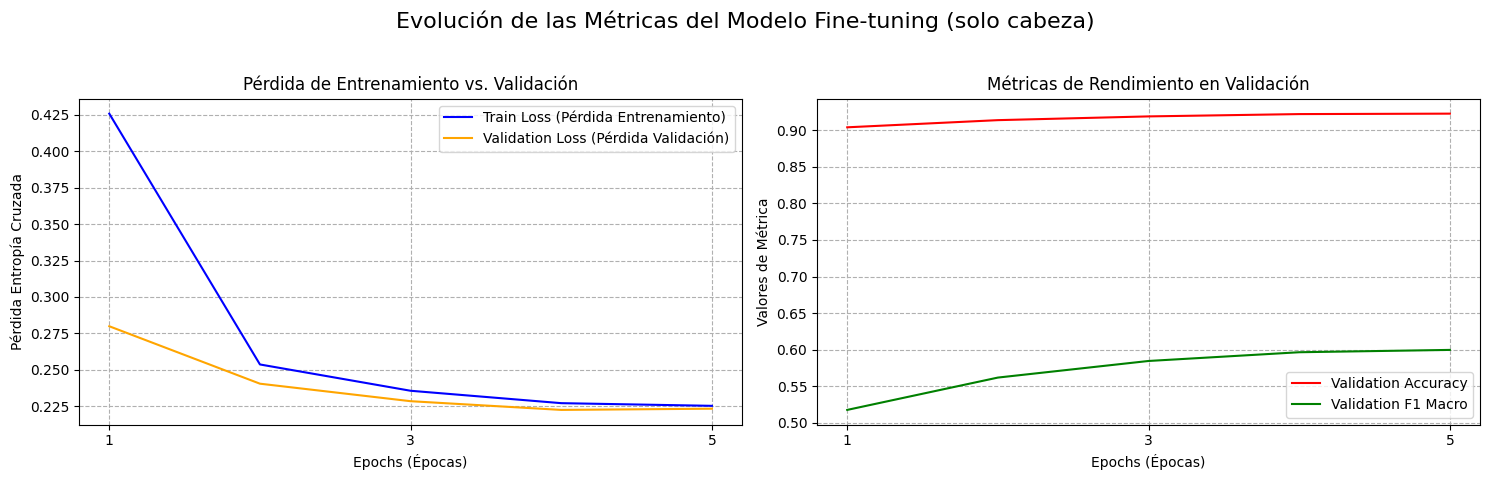

In [57]:
#Recuperamos el modelo preentrenado guardado en local
modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
                                   ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(modelo_mlm_pretrained, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 5,
                                            head_initial_dim=128, patience = 3, sampler = sampler, freeze_base_model = True, dropout = 0.1, mean_pooling=True)     

print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title='Fine-tuning (solo cabeza)')


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6971
           1       0.57      0.84      0.68       343
           2       0.57      0.60      0.58       435
           3       0.73      0.78      0.75       370
           4       0.00      0.00      0.00       185

    accuracy                           0.92      8304
   macro avg       0.57      0.64      0.60      8304
weighted avg       0.91      0.92      0.91      8304

Test AUC Macro (OVR): 0.9757
Test MCC: 0.7289


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

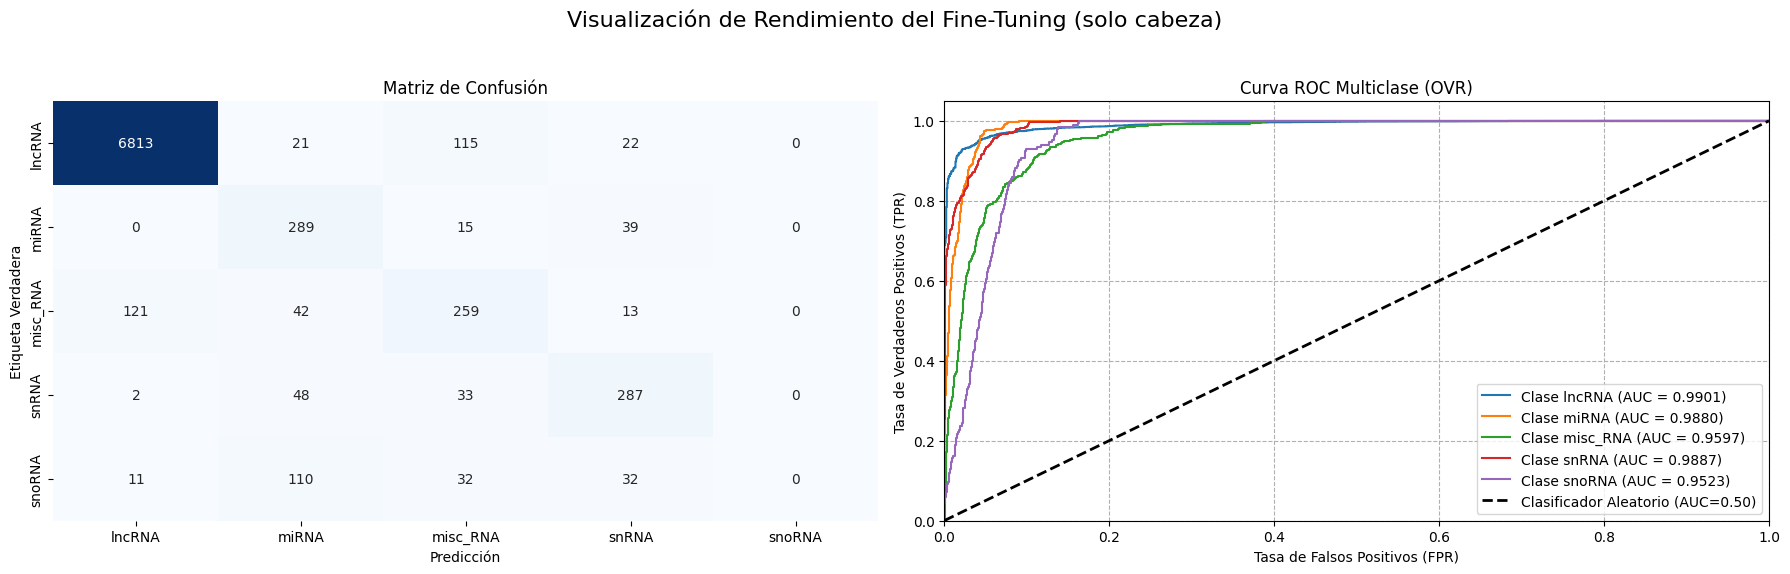

In [58]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Fine-Tuning (solo cabeza)')

Como primera aproximación al uso del Transformer, optamos por solo ajustar la cabeza de clasificación, manteniendo congelados los pesos del encoder pre-entrenado y entrenando durante 5 épocas. Los resultados obtenidos (F1-Macro: 0.60, MCC: 0.72) representan un retroceso significativo respecto al baseline MLP con la misma arquitectura que la cabeza.

Este peor desempeño se debe a la rigidez representacional. Al mantener el encoder estático, estamos forzando al clasificador MLP a trabajar con embeddings generados exclusivamente para la tarea de Masked Language Modeling (MLM). Aunque estos embeddings capturan la sintaxis del ARN, no han sido optimizados para maximizar la separabilidad entre clases biológicas específicas.

El síntoma más crítico de esta rigidez se observa en la clase snoRNA (Clase 4), donde el modelo colapsa totalmente obteniendo un F1-Score de 0.00. No pudiendo clasificar correctamente ninguna secuencia de snoRNA en su clase correspondiente, confundiéndolas principalmente con miRNA. Esto indica que, en el espacio latente original del pre-entrenamiento, las representaciones de snoRNA y miRNA están tan entrelazadas que un clasificador lineal simple es matemáticamente incapaz de trazar una frontera de decisión entre ellas.

En la matriz de confusión se aprecia como el modelo está asignando pprincipalmente las muestras de snoRNA a la clase miRNA , incapaz de encontrar características distintivas sin modificar la proyección de los datos.

La experimentación demuestra que la información semántica del pre-entrenamiento es insuficiente por sí sola si no se permite su adaptación. La 'congelación' del modelo impide que el Transformer reorganice el espacio vectorial para romper los solapamientos estructurales. Por tanto, se hace evidente la necesidad de proceder a un Full Fine-Tuning, descongelando todas las capas para permitir que el modelo refina sus representaciones internas y aprenda a discriminar activamente los biotipos conflictivos.

## Experimentación: Full Fine-tuning (modelo base reajustable), por 5 épocas. Cabeza de 128 (input) --> 128 --> 32 --> 8 --> 5. Learning rate de 5e-5

Para la etapa de ajuste fino completo, donde se descongelan los pesos del encoder pre-entrenado, se modificó la estrategia de optimización para mitigar el riesgo de Catastrophic Forgetting. Dado que el encoder ya posee representaciones latentes ricas sobre la sintaxis del ARN, el objetivo es realizar pequeños ajustes en los pesos para adaptarlos a la tarea de clasificación, sin destruir el conocimiento previo adquirido durante el pre-entrenamiento. Por ello, se redujo la tasa de aprendizaje (learning rate), pasando de $3e^{-4}$ a $5e^{-5}$.

Epoch 1/5 | Train Loss: 0.5108 | Val Loss: 0.2954 | Val Acc: 0.9172 | Val F1 Macro: 0.5433
Epoch 2/5 | Train Loss: 0.2621 | Val Loss: 0.2476 | Val Acc: 0.9133 | Val F1 Macro: 0.4872
Epoch 3/5 | Train Loss: 0.2356 | Val Loss: 0.2246 | Val Acc: 0.9157 | Val F1 Macro: 0.5005
Epoch 4/5 | Train Loss: 0.2223 | Val Loss: 0.2198 | Val Acc: 0.9202 | Val F1 Macro: 0.5298
!!! Early Stopping activado en la época 4. No hubo mejora en 3 épocas. !!!
Cargado el mejor estado del modelo antes de retornar.


ClassificationTransformer(
  (tok): Embedding(68, 128, padding_idx=0)
  (pos): Embedding(512, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_feat

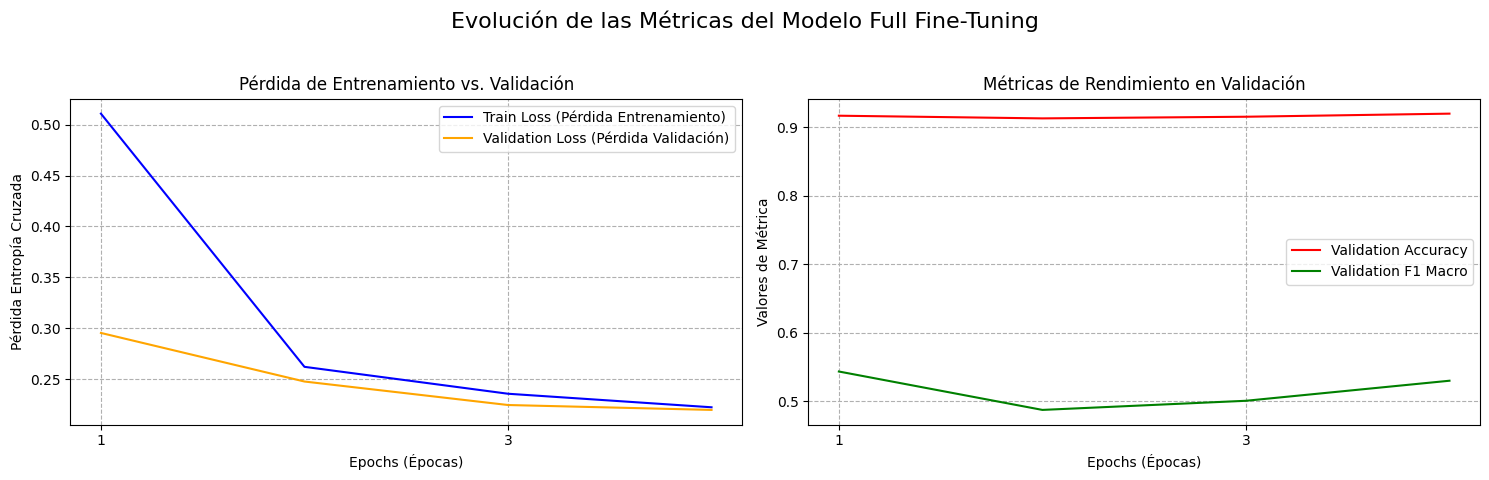

In [61]:
#Recuperamos el modelo preentrenado guardado en local
modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
                                   ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(modelo_mlm_pretrained, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 5,
                                            head_initial_dim=128, patience = 3, sampler = sampler, freeze_base_model = False, dropout = 0.1, mean_pooling=True, lr=5e-5)  


print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title='Full Fine-Tuning')


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.44      0.94      0.60       343
           2       0.80      0.18      0.29       435
           3       0.66      0.86      0.74       370
           4       0.00      0.00      0.00       185

    accuracy                           0.92      8304
   macro avg       0.58      0.59      0.52      8304
weighted avg       0.92      0.92      0.90      8304

Test AUC Macro (OVR): 0.9740
Test MCC: 0.7240


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

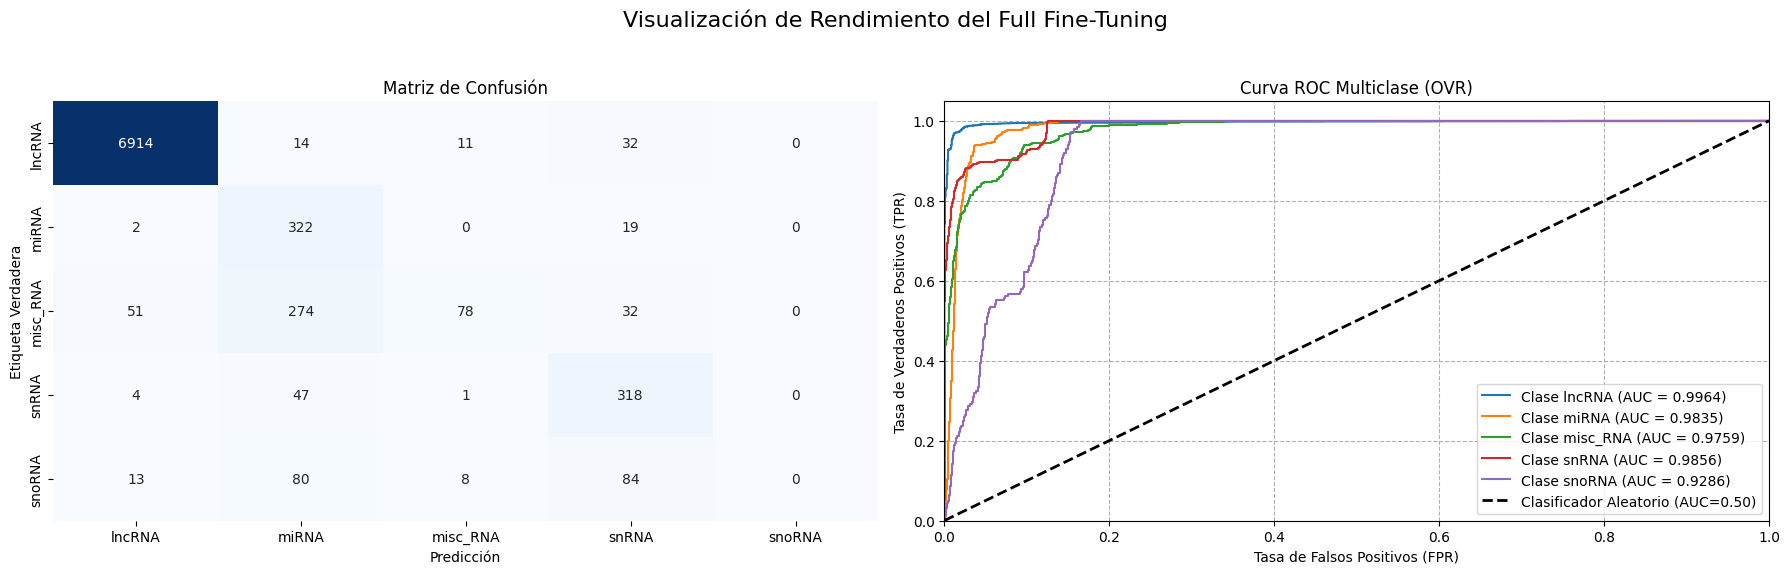

In [62]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Full Fine-Tuning')

Los resultados del Full Fine-Tuning muestran una degradación del rendimiento (F1-Macro < 0.52) y el colapso de la clase snoRNA. Esto se atribuye a la discrepancia en las velocidades de aprendizaje necesarias, mientras el encoder requiere actualizaciones sutiles (tasa de aprendizaje baja), el cabezal de clasificación, si se inicializa aleatoriamente, requiere una tasa alta para converger rápidamente. Al usar una tasa baja global ($5e^{-5}$) en pocas épocas, el clasificador no logró converger.

Para esta fase de Full Fine-Tuning, debemos dejar de lado la convención estándar en literatura de NLP, que sugiere realizar fine-tuning por pocas épocas (3-5 épocas). Esta norma general asume el uso de modelos masivos (LLMs) pre-entrenados sobre corpus gigantescos, donde las características aprendidas son extremadamente robustas y solo requieren una adaptación superficial. En nuestro caso, el modelo base fue pre-entrenado desde cero, con un dataset de dominio específico limitado (~41.000 secuencias) durante un ciclo breve de 20 épocas para evitar el sobreajuste temprano en la tarea de MLM. En consecuencia, partimos de la premisa de que las representaciones latentes del encoder, aunque capturan la sintaxis del ARN, no poseen la misma madurez ni generalidad que las de un modelo masivo.

Por tanto, como un fine-tuning corto resulta insuficiente para permitir que el modelo reorganice su espacio vectorial y construya fronteras de decisión complejas. Optamos proseguir la experimentación con una estrategia de entrenamiento más extendido, haciendo full fine-tuning por más épocas, para así garantizar la convergencia de los pesos, delegando en el mecanismo de Early Stopping la responsabilidad de detener el entrenamiento en el punto óptimo de generalización, evitando así el riesgo de memorización.

## Experimentación: Full Fine-tuning (modelo base reajustable), por muchas épocas. Cabeza de 128 (input) --> 128 --> 32 --> 8 --> 5. Learning rate de 5e-5

Para este largo full fine-tuning ponemos 30 épocas y un early stopping con paciencia de 3 épocas, de forma que si el desempeño del modelo (métrica de F1 score) no consigue mejorar en 3 épocas el entrenamiento se detiene.

Epoch 1/30 | Train Loss: 0.5101 | Val Loss: 0.2951 | Val Acc: 0.9140 | Val F1 Macro: 0.5178
Epoch 2/30 | Train Loss: 0.2579 | Val Loss: 0.2413 | Val Acc: 0.9149 | Val F1 Macro: 0.4974
Epoch 3/30 | Train Loss: 0.2283 | Val Loss: 0.2209 | Val Acc: 0.9299 | Val F1 Macro: 0.5842
Epoch 4/30 | Train Loss: 0.2076 | Val Loss: 0.2018 | Val Acc: 0.9445 | Val F1 Macro: 0.6477
Epoch 5/30 | Train Loss: 0.1889 | Val Loss: 0.1779 | Val Acc: 0.9515 | Val F1 Macro: 0.6760
Epoch 6/30 | Train Loss: 0.1640 | Val Loss: 0.1489 | Val Acc: 0.9541 | Val F1 Macro: 0.6855
Epoch 7/30 | Train Loss: 0.1389 | Val Loss: 0.1299 | Val Acc: 0.9559 | Val F1 Macro: 0.7055
Epoch 8/30 | Train Loss: 0.1235 | Val Loss: 0.1237 | Val Acc: 0.9582 | Val F1 Macro: 0.7275
Epoch 9/30 | Train Loss: 0.1137 | Val Loss: 0.1164 | Val Acc: 0.9619 | Val F1 Macro: 0.7763
Epoch 10/30 | Train Loss: 0.1088 | Val Loss: 0.1135 | Val Acc: 0.9619 | Val F1 Macro: 0.7897
Epoch 11/30 | Train Loss: 0.1012 | Val Loss: 0.1138 | Val Acc: 0.9642 | Val F1 

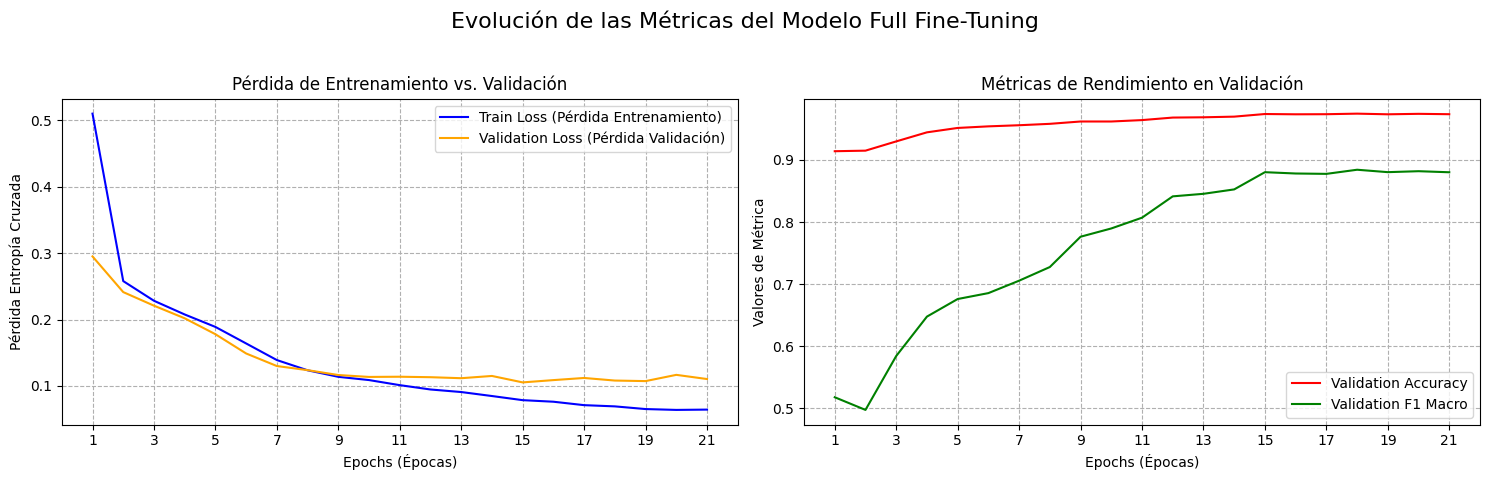

In [63]:
#Recuperamos el modelo preentrenado guardado en local
modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
                                   ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(modelo_mlm_pretrained, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            head_initial_dim=128, patience = 3, sampler = sampler, freeze_base_model = False, dropout = 0.1, mean_pooling=True, lr=5e-5)  


print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title='Full Fine-Tuning')

El modelo final retornado, acaba siendo entrenado por 18 épocas (20 min aprox), haciendo uso de una GPU Nvidia RTX 3060. Vemos como la pérdida en validación resulta un poco mayor que la pérdida en entrenamiento, esto se da a partir de la época 11. Sin embargo vemos el F1 score de validación sí que continúa mejorando después de esa época hasta la 18, donde se estanca, siendo el modelo en esa época el que nos devuelve la función (mejor época según el early stopping ya qeu su objetivo es maximizar el F1-score). Por esto, a pesar del aumento de la pérdida en validación respecto a train, como el F1 score aumenta, podemos descartar sobreajuste. Además si aumentásemos el Dropout posiblemente nos reportase menor pérdida en validación que en train, pero acabaríamos con un peor F1-score.


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.81      0.92      0.86       343
           2       0.93      0.88      0.90       435
           3       0.95      0.93      0.94       370
           4       0.68      0.70      0.69       185

    accuracy                           0.97      8304
   macro avg       0.87      0.88      0.88      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9945
Test MCC: 0.9054


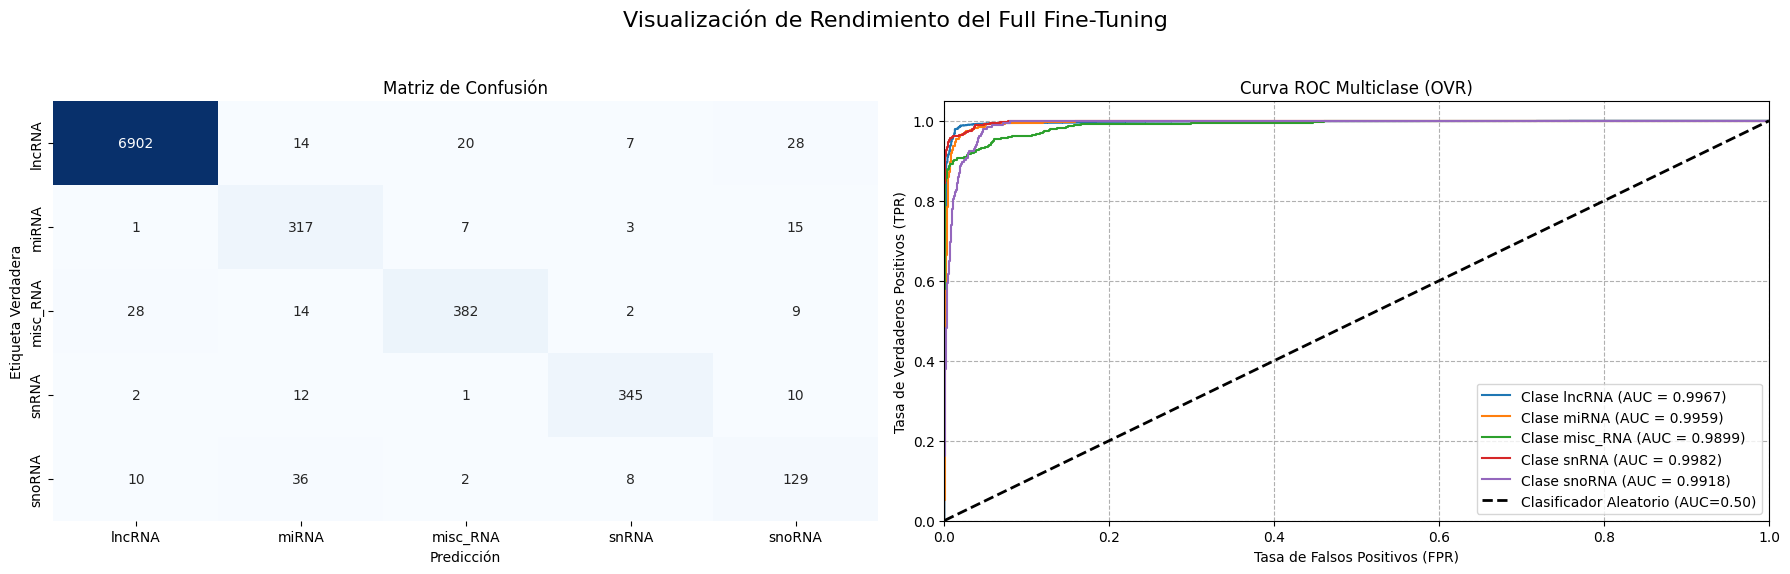

In [64]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Full Fine-Tuning')

Este modelo al que le hemos hecho full fine-tuning por muchas épocas, ha conseguido igualar el desempeño del mejor baseline (64 input --> 512 --> 128 --> 32  --> 5), pero haciendo uso de una representación incial distinta de las secuencias (secuencias tokenizadas en crudo frente a conteo de kmers) y haciendo uso además de una cabeza de clasificación más pequeña (128 input --> 128 --> 32 --> 8 --> 5), que el propio MLP baseline.

Haciendo una comparación directa entre el mejor modelo baseline basado en conteo de frecuencias y este último modelo basado en atención contextual (Encoder + cabeza Full Fine-Tuning).

A primera vista, las métricas globales sugieren un empate técnico: ambos modelos alcanzan un Accuracy del 97% y un F1-Macro similar de 0.88 y 0.89. Sin embargo, un desglose granular del rendimiento revela diferencias fundamentales en la naturaleza del aprendizaje, demostrando que el Transformer ha logrado superar barreras informativas que el MLP no pudo. Un indicador contundente de la superioridad del Transformer no reside en la matriz de confusión, sino en la dinámica de optimización. Independientemente del tamaño de la red, todos los modelos basados en conteo de k-mers se estancaron en una pérdida de validación de ~0.12. Esto confirma que la información estadística de conteo de nucleótidos tiene un límite de resolución finito. Sin embargo el modelo Full Fine-Tuning logró descender la pérdida hasta 0.1053. Esta reducción en la incertidumbre demuestra que el modelo está extrayendo patrones (sintaxis secuencial, motivos posicionales) que son invisibles para el conteo de frecuencias.


La diferencia cualitativa más notable se observa en la clase misc_RNA (Clase 2), identificada previamente en el UMAP del baseline como un 'puente de confusión' con los lncRNA. Al basarse en frecuencias de aparición de kmers, el MLP lucha por distinguir los misc_RNA largos de los lncRNA. Pero el Transformer es capaz de superar al mejor baseline en la distinción de estas clases. Gracias al mecanismo de auto-atención, el modelo comprende que, aunque un misc_RNA sea largo, su estructura interna y gramática difieren de las de un lncRNA. No solo mejora el desempeño respecto al baseline en la distinción de los misc_RNA, sino también lo hace en miRNA.

También debemos analizar dónde pierde el Transformer al comparalo con el baseline. En la clase snoRNA (Clase 4), el baseline MLP obtiene un mejor desempeño (F1 0.77) frente al Transformer (F1 0.69). Los snoRNA son secuencias cortas. Los modelos de atención pueden explotar mas su capacidad cuando tienen contexto abundante. En secuencias breves, la señal de contexto es débil, y la fuerza bruta estadística de los k-mers resulta ser ligeramente más eficaz.

En cuanto a la calidad Global de la Predicción, el Coeficiente de Correlación de Matthews (MCC) actúa como métrica definitiva del equilibrio del modelo. En esta métrica el Transformer consigue batir por muy poco al baseline, Mejor MLP: 0.9032, vs. Transformer: 0.9054. Aunque la diferencia es sutil, el Transformer logra un MCC superior. Esto implica que, a pesar de sus dificultades con la clase más corta (snoRNA), su capacidad para liadiar con las confusiones en las clases complejas (misc_RNA y lncRNA) genera un modelo ligeramente más robusto y fiable.

La comparativa permite concluir que la aproximación Transformer es superior arquitectónicamente. Aunque el MLP basado en k-mers es un baseline excepcionalmente bueno, no puedde seguir más allá de un límite conceptual, generado por la forma de entender las secuencias (bolsa de kmers). El Transformer, mediante el aprendizaje de la semántica secuencial, logra romper este límite de pérdida y resolver ambigüedades estructurales en clases largas, validando la hipótesis de que el orden de los nucleótidos contiene información biológica crítica que el simple conteo ignora, y consigue hacerlo además con una arquitectura de la cabeza MLP clasificadora bastante menor que el baseline.

1. Iniciando extracción...
Forma de los Embeddings extraídos: (41516, 8)
2. Calculando reducción U-MAP (Configuración Coseno/Vecinos optimizada)...


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3. Generando gráfico...


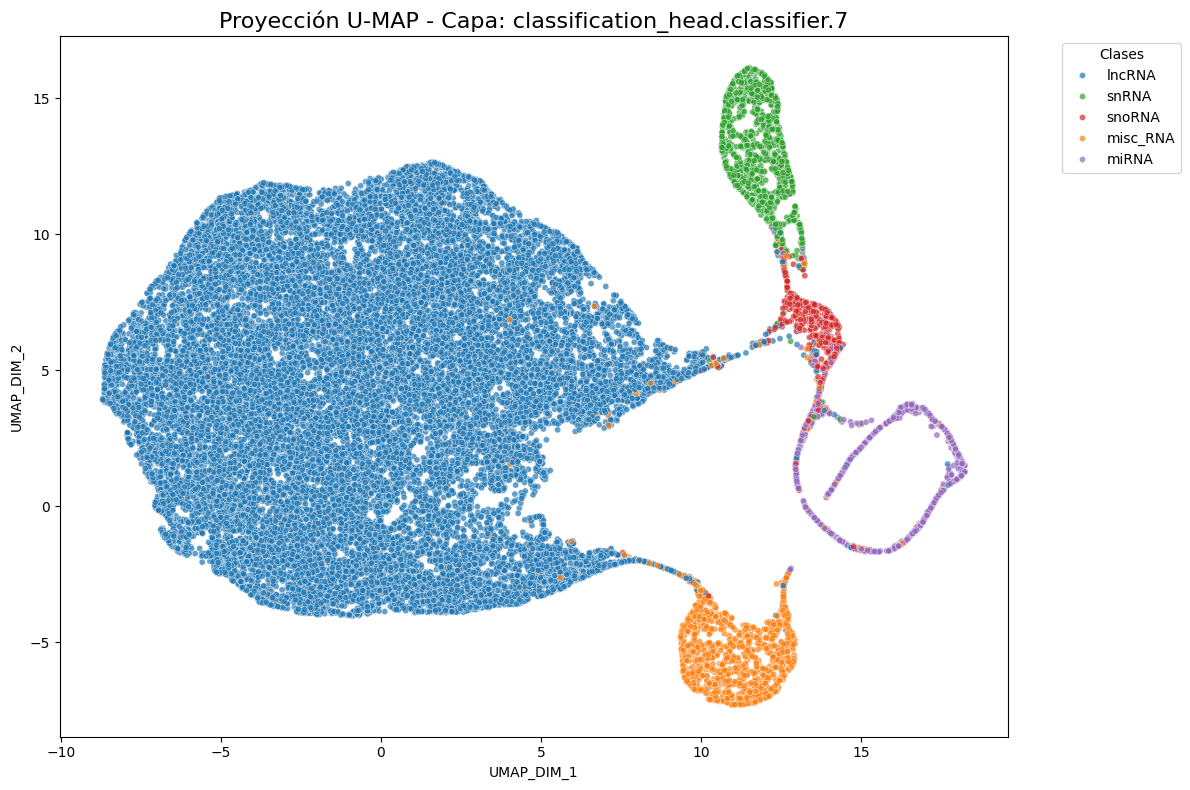

In [65]:
dataset = DownstreamTaskDataset(seqs, labels_numeric, max_len=512)

plot_Umap(downstream_model_trained, dataset, class_to_idx, layer_target='classification_head.classifier.7')

Para corroborar que la mejora en la pérdida de validación y en la clasificación de misc_RNA no es pura casualidad, sino una reorganización real del conocimiento del modelo, comparamos las proyecciones UMAP de la penúltima capa del Baseline MLP frente al Transformer Full Fine-Tuning.

La comparativa revela una transformación estructural clave que explica la superioridad cualitativa del Transformer.

Se consigue un colapso del puente entre lncRNA y misc_RNA. En el baseline observamos una conexión gruesa y continua entre el clúster mayoritario azul (lncRNA) y el clúster naranja (misc_RNA). Esta "zona de transición" ancha indica que, para el MLP, existe un subconjunto grande de secuencias donde la frecuencia de k-mers es ambigua, haciendo imposible trazar una frontera de decisión limpia.

Pero en el Transformer, la topología cambia. La conexión entre la masa azul y la naranja se ha reducido, siendo mucho más fina y definida. El clúster naranja (misc_RNA) aparece más compactado y alejado del cluster de lncRNA. Esto se debe a que el modelo Transformer ha aprendido características internas que le permiten distinguir que, aunque esas secuencias naranjas sean largas (como las azules), su sintaxis no corresponde a un lncRNA. Esta separación física en el espacio vectorial es la responsable directa del aumento del F1-Score en esta clase (de 0.87 a 0.90).


Mientras que el Baseline muestra nubes de puntos con bordes algo difusos (especialmente en la frontera snoRNA-miRNA), el Transformer tiende a generar estructuras con bordes más definidos en las clases que logra entender bien. Sin embargo, en el extremo derecho (la zona de snoRNA rojo y miRNA morado), el Transformer mantiene una estructura compleja y curvada, similar a la del Baseline. Esto confirma visualmente que, para las secuencias cortas, el mecanismo de atención no logró encontrar una representación radicalmente distinta a la que ya ofrecían los k-mers, explicando por qué el rendimiento en estas clases se mantuvo similar o ligeramente inferior.

La proyección UMAP del Transformer demuestra que el modelo profundo no se limitó a replicar las estadísticas de entrada que recibía el baseline. Al romper la continuidad entre clases que compartían características de longitud pero no de función (lncRNA vs misc_RNA), el modelo validó que ha extraído información semántica genuina, reorganizando el espacio matemático para reflejar mejor la realidad biológica subyacente.

Tras esta comparación podemos sacar dos conclusiones sólidas:

1. El gran desempeño de los baseline, se debe en gran parte a su potente arquitectura y a las facilidades que le proporciona el recibir las secuencias como conteos de kmers, y no como secuencias en crudo como tal. Pero este desempeño llega un punto en el que se estanca, no consigue mejorar por mucho que se aumente su músculo, al no tener más información que un simple conteo de kmers. Aumentar la capacidad hacer la red más compleja NO mejora el desempeño. Los datos de entrada (conteos) son tan simples y directos que una red pequeña ya extrae el 100% de la información. Una red más grande solo memoriza empeorando el desempeño.

2. El modelo preentreando al tener conocimiento secuencial de la cadena, es capaz de entenderla mejor en crudo, sin necesidad de que le facilitemos la vida dándole la secuencia semiprocesada. Lo que permite que, con una cabeza 4 veces menor que el mejor MLP baseline, pero que recibe como entrada embeddings semánticamente más ricos que los simples conteos, consiga los mismos resultados. Teniendo además la posibilidad de escalar dicha cabeza, cosa que en los baseline ya hemos evidenciado que por mucho que sigamos escalando el tamaño, el rendimiento queda estancado.

3. Respecto al modelo donde solo entrenamos la cabeza clasificadora (congelando el encoder), interpretamos que su rendimiento limitado (similar al de los primeros baselines) se debe a ser más rígido, es decir, a estar restringiendo la capacidad de adaptación del modelo. Al mantener congelados los pesos del Transformer, estamos obligando a la red a usar representaciones genéricas aprendidas durante el preentrenamiento, impidiendo que el encoder afine su conocimiento para detectar características relevantes para la clasificación.

## Experimentación FINAL: Modelo Enconder BERT + Classification head entrenados desde cero, por muchas épocas. Cabeza de 128 (input) --> 128 --> 32 --> 8 --> 5. Learning rate de 1e-4

Por último vamos a probar a entrenar desde cero el modelo BERT+cabeza, para comprobar si realmente el preentrenamiento previo está aportando mucho, ya que el modelo que consigue superar a los baseline es al que se le hace full fine-tuning, y durante unas 18 épocas. Por lo que puede ser que el preentrenamiento no esté realmente aportando mucho, y sea menos costoso entrenar al modelo desde cero por más o menos las mismas épocas, que primero hacer el preentrenamiento y después hacerle fine-tuning.

En este caso, a diferencia del Full fine-tuning anterior,el modelo no sabe nada, inicializa sus pesos aleatoriamente, sin guardar conocimiento previo sobre las cadenas de nucleótidos. Por tanto, usar una Learning Rate de ($5e^{-5}$) sería demasiado lento. Necesitamos una velocidad de aprendizaje normal, como podría ser 1e-4.

Además vamos a establecer incialmente 40 épocas y un early stopping de paciencia de 4 épocas.

Este experimento nos va a permitir cuantificar el valor real aportado por la fase de Masked Language Modeling (MLM) y descartar o confirmar la posibilidad de que el rendimiento del modelo final se deba exclusivamente a la capacidad arquitectónica del Transformer (y no a la transferencia de conocimiento).

Epoch 1/40 | Train Loss: 0.5566 | Val Loss: 0.2616 | Val Acc: 0.8985 | Val F1 Macro: 0.4522
Epoch 2/40 | Train Loss: 0.3006 | Val Loss: 0.2021 | Val Acc: 0.9288 | Val F1 Macro: 0.5883
Epoch 3/40 | Train Loss: 0.2263 | Val Loss: 0.1895 | Val Acc: 0.9305 | Val F1 Macro: 0.5948
Epoch 4/40 | Train Loss: 0.1858 | Val Loss: 0.1721 | Val Acc: 0.9357 | Val F1 Macro: 0.6283
Epoch 5/40 | Train Loss: 0.1628 | Val Loss: 0.1483 | Val Acc: 0.9404 | Val F1 Macro: 0.6713
Epoch 6/40 | Train Loss: 0.1453 | Val Loss: 0.1330 | Val Acc: 0.9646 | Val F1 Macro: 0.8176
Epoch 7/40 | Train Loss: 0.1325 | Val Loss: 0.1355 | Val Acc: 0.9651 | Val F1 Macro: 0.8179
Epoch 8/40 | Train Loss: 0.1258 | Val Loss: 0.1272 | Val Acc: 0.9678 | Val F1 Macro: 0.8436
Epoch 9/40 | Train Loss: 0.1161 | Val Loss: 0.1334 | Val Acc: 0.9646 | Val F1 Macro: 0.8342
Epoch 10/40 | Train Loss: 0.1080 | Val Loss: 0.1378 | Val Acc: 0.9673 | Val F1 Macro: 0.8505
Epoch 11/40 | Train Loss: 0.0997 | Val Loss: 0.1348 | Val Acc: 0.9693 | Val F1 

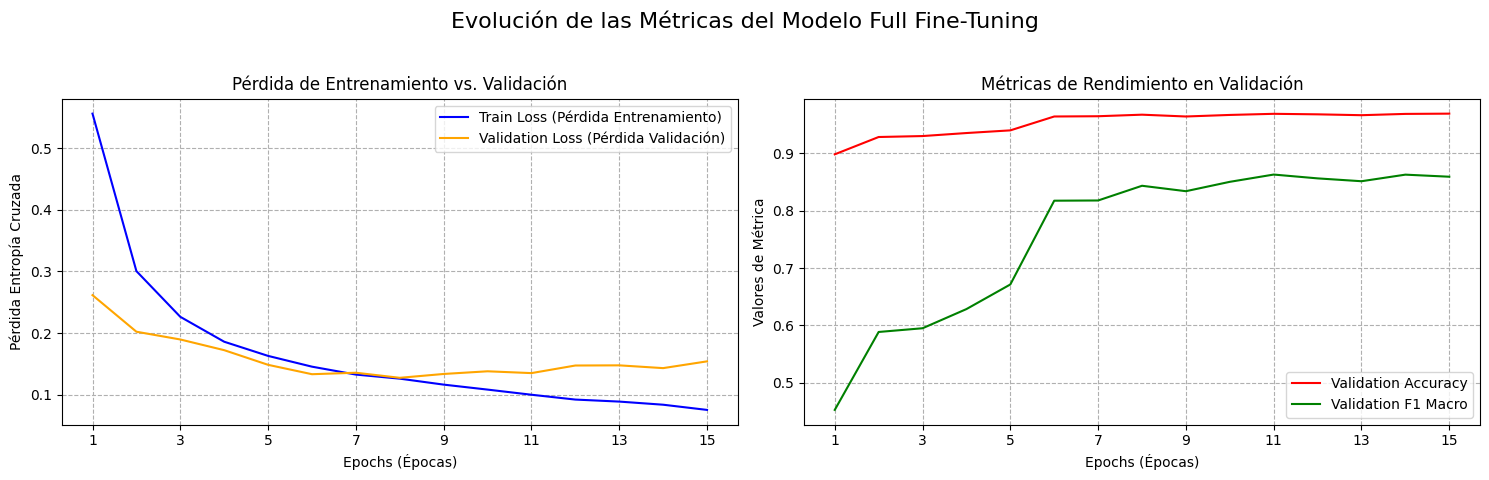

In [67]:
#Recuperamos el modelo preentrenado guardado en local
# modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
#                                    ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(None, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 40,
                                            head_initial_dim=128, patience = 4, sampler = sampler, dropout = 0.1, mean_pooling=True, lr=1e-4)  


print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title='Full Fine-Tuning')


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.75      0.92      0.83       343
           2       0.86      0.85      0.86       435
           3       0.94      0.91      0.93       370
           4       0.72      0.54      0.61       185

    accuracy                           0.97      8304
   macro avg       0.85      0.84      0.84      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9917
Test MCC: 0.8836


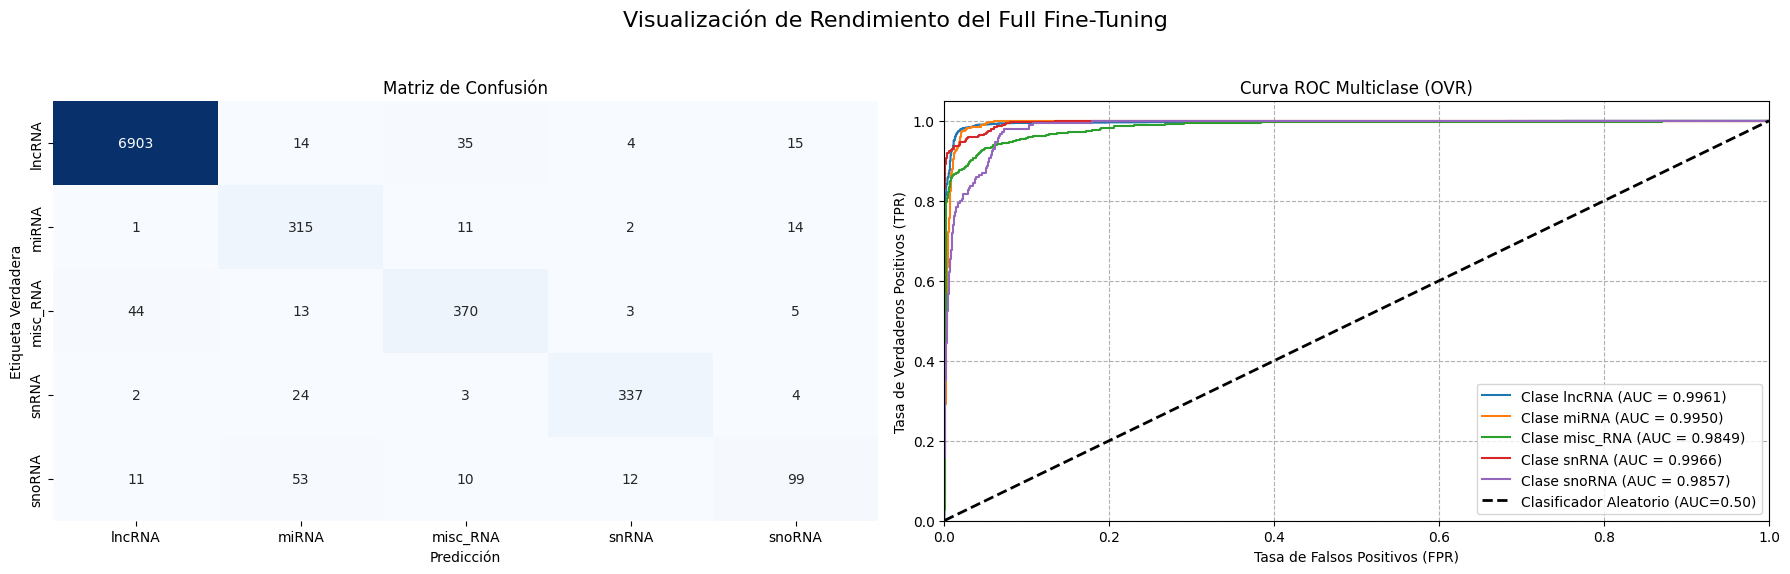

In [68]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Full Fine-Tuning')


Como podemos ver, el modelo encoder + cabeza entrenado desde cero NO es capaz de superar el modelo al que se le hizo full fine-tuning. Pero aún así alcanza resultados muy buenos  sin necesidad de emplear tantas épocas (en solo 11 épocas alcanza el pico de rendimiento), mientras que el modelo de full fine tuning, primero conlleva entrenar durante 20 épocas el modelo, y después hacerle el fine tuning por otras 18 épocas

Si comparamos el modelo entrenado desde cero contra la estrategia de Pre-train + Fine-Tune,los resultados revelan que el pre-entrenamiento no fue un paso redundante, sino un factor diferencial que permitió romper el techo de rendimiento. Es importante destacar como de nuevo en el modelo entrenado desde cero la pérdida de validación, no consigue superar el límite de aproximadamente 0.12 en el que se estancaban los MLP baseline. Sin embargo el Transformer Pre-entrenado sí que logró descender la pérdida en validación a 0.1053. 

Esto nos indica que entrenar el Transformer desde cero no nos permitió aprender nada que el MLP baseline con gran arquitectura no supiera ya. Sin la fase previa de MLM, el mecanismo de atención no logró extraer patrones sintácticos profundos y se comportó simplemente como un extractor de características estadístico más complejo. Solo el pre-entrenamiento permitió superar el 'muro' de 0.12 en pérdida de validación.

Atendiendo a la clasificación de las clases más difíciles, el modelo entrenado desde cero muestra una caída de rendimiento significativa respecto al modelo pre-entrenado. En la clase snoRNA, el F1 score cae de 0.69 en el modelo pre-entrenado a 0.61 en este último enfoque. La falta de conocimiento previo sobre la estructura de secuencias cortas ha penalizado la sensibilidad (Recall 0.54).
En la clase misc_RNA, el F1 también baja un poco respecto a lo obtenido en el modelo preentrenado. Esto significa que el modelo desde cero tiende a confundirse con los lncRNA algo más de lo que lo hace el modelo pre-entrenado. 
Esto nos estaría indicando que la capacidad de distinguir entre clases largas reside en la comprensión del lenguaje adquirida durante el MLM, y no es algo que se pueda aprender fácilmente solo con etiquetas supervisadas en pocas épocas.

Durante el aprendizaje del modelo entrenado desde cero, a partir de la época 11, comienza a sobreajustarse (la pérdida en validación sube), lo que indica que con nuestro pequeño conjunto de datos, el modelo no tiene suficiente señal para generalizar mejor desde cero. El pre-entrenamiento actuó como un regularizador masivo, permitiendo un entrenamiento más largo (20 + 18 épocas) que desembocó en una solución más generalizable y robusta.

El experimento confirma que la arquitectura Transformer por sí sola no garantiza una superioridad intrínseca. Entrenada desde cero con un volumen de datos limitados, su rendimiento es estadísticamente equivalente al de un MLP Baseline basado en el conteo de kmers, pero con mayor coste computacional. Si bien es cierto que el Transformer logra igualar este desempeño requiriendo de una menor preparación previa de los datos (secuencias crudas tokenizadas como entradas al modelo), y además utilizando una cabeza de clasificación con una arquitectura menor que la del mejor baseline, la evidencia demuestra que buena parte del valor diferencial reside en la fase de Transfer Learning. El conocimiento sintáctico extraído mediante Masked Language Modeling es responsable de la reducción del error y de discriminación efectiva de las clases estructuralmente más complejas. Por tanto, la estrategia de dos partes (Pre-train + Fine-tune) queda plenamente justificada como una vía efectiva para superar el estado del arte de los baselines.

1. Iniciando extracción...
Forma de los Embeddings extraídos: (41516, 8)
2. Calculando reducción U-MAP (Configuración Coseno/Vecinos optimizada)...


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


3. Generando gráfico...


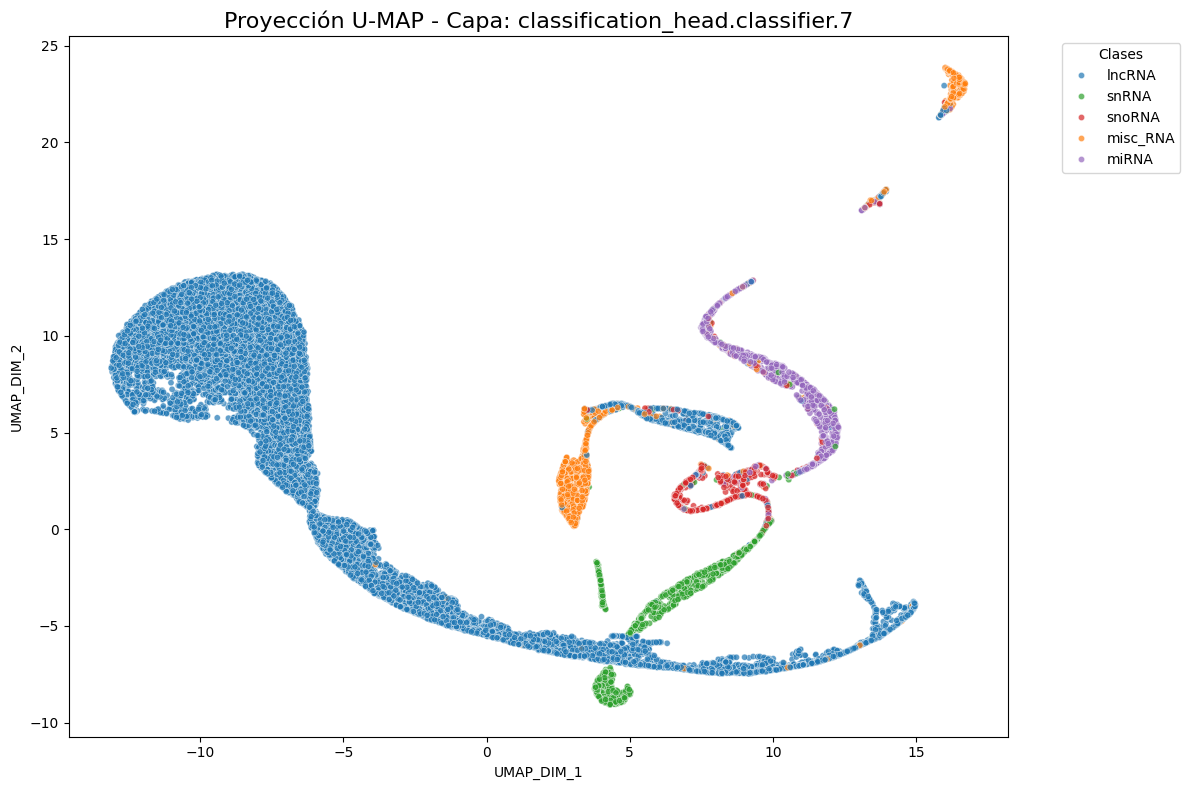

In [69]:
dataset = DownstreamTaskDataset(seqs, labels_numeric, max_len=512)

plot_Umap(downstream_model_trained, dataset, class_to_idx, layer_target='classification_head.classifier.7')

La proyección UMAP del modelo entrenado desde cero revela una topología radicalmente distinta tanto a la del Baseline como a la del modelo Pre-entrenado, caracterizada por una notable fragmentación y falta de cohesión. A diferencia del modelo pre-entrenado, que agrupaba las clases en clústeres densos y compactos, este modelo proyecta las secuencias en nubes de puntos dispersas y con formas irregulares. Esto indica que el modelo no ha aprendido características robustas e invariantes, sino que probablemente patrones superficiales, resultando en una baja confianza en la predicción.

Mientras que el modelo pre-entrenado separó de una forma bastante limpia las clases, el modelo desde cero muestra los clústers bastante más desordenados. Aunque intenta separarlos, lo hace sin la claridad geométrica del modelo pre-entrenado, lo que explica por qué su pérdida en validación es superior (0.12 vs 0.10).

La estructura caótica de este UMAP evidencia la dificultad del modelo para encontrar un mínimo global estable sin la guía del pre-entrenamiento. El modelo ha aprendido a separar los puntos a la fuerza para minimizar el error de entrenamiento, pero no ha construido un mapa semántico coherente de la biología del ARN.

## ¿Cómo podríamos proseguir la experimentación?

a). Ajuste de hiperparámetros para el modelo encoder + cabeza entrenado desde cero.


b). Técnicas de Explicabilidad para la arquitectura Transformers (Attention RollOut y la otra q no recuerdo)


c). Probar el comportamiento de los MLP Baseline con una representación cruda de las secuecnias como hacemos en la tarea downstream de clasificación.


d). Amentar la capacidad de la cabeza de clasificación.

## Experimentaciones adicionales; Aumentación de la cabeza de clasificación

Feature Extraction: Modelo base reajustable, lr = 5e5, forma de comprimir las secuencias-> Mean Pooling. Arquitectura Cabeza 128 (input) -> 192 -> 48 -> 12 -> 5



Dropout = 0.1

Epoch 1/30 | Train Loss: 0.6391 | Val Loss: 0.2624 | Val Acc: 0.8930 | Val F1 Macro: 0.4223
Epoch 2/30 | Train Loss: 0.2479 | Val Loss: 0.2087 | Val Acc: 0.9398 | Val F1 Macro: 0.6405
Epoch 3/30 | Train Loss: 0.1891 | Val Loss: 0.1775 | Val Acc: 0.9496 | Val F1 Macro: 0.7040
Epoch 4/30 | Train Loss: 0.1559 | Val Loss: 0.1570 | Val Acc: 0.9565 | Val F1 Macro: 0.7581
Epoch 5/30 | Train Loss: 0.1322 | Val Loss: 0.1413 | Val Acc: 0.9601 | Val F1 Macro: 0.7884
Epoch 6/30 | Train Loss: 0.1159 | Val Loss: 0.1228 | Val Acc: 0.9637 | Val F1 Macro: 0.8149
Epoch 7/30 | Train Loss: 0.1053 | Val Loss: 0.1158 | Val Acc: 0.9657 | Val F1 Macro: 0.8335
Epoch 8/30 | Train Loss: 0.0953 | Val Loss: 0.1209 | Val Acc: 0.9682 | Val F1 Macro: 0.8466
Epoch 9/30 | Train Loss: 0.0880 | Val Loss: 0.1197 | Val Acc: 0.9690 | Val F1 Macro: 0.8509
Epoch 10/30 | Train Loss: 0.0829 | Val Loss: 0.1136 | Val Acc: 0.9694 | Val F1 Macro: 0.8587
Epoch 11/30 | Train Loss: 0.0777 | Val Loss: 0.1172 | Val Acc: 0.9720 | Val F1 

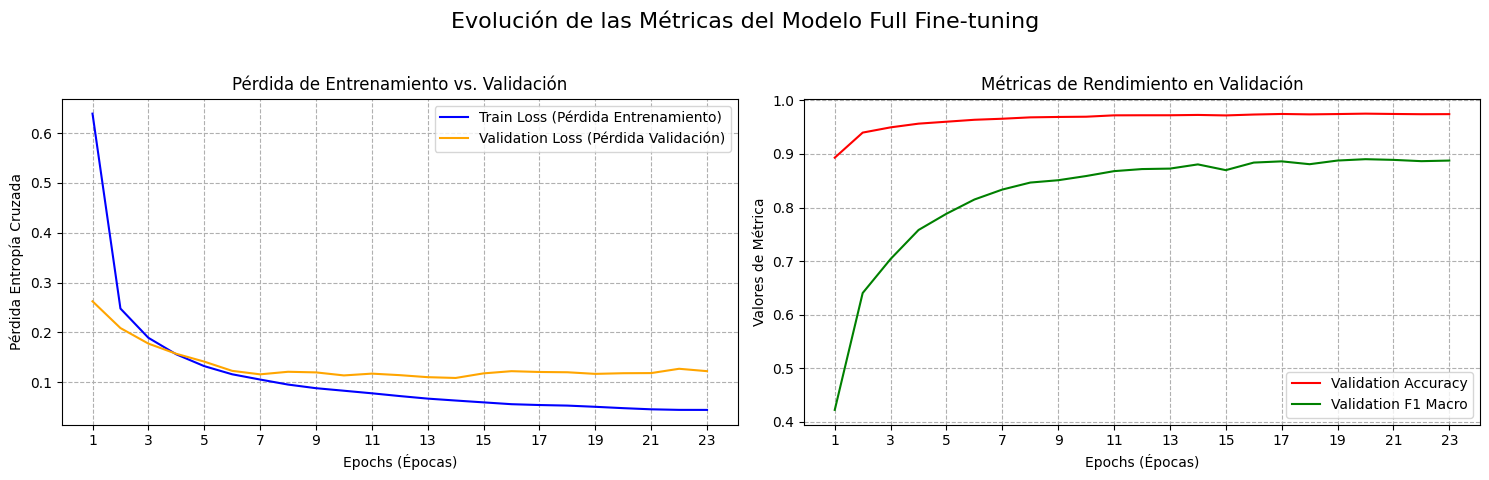

In [73]:
#Recuperamos el modelo preentrenado guardado en local
modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
                                   ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(modelo_mlm_pretrained, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            head_initial_dim=192, patience = 3, sampler = sampler, freeze_base_model = False, dropout = 0.1, lr = 5e-5, mean_pooling = True)
print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title='Full Fine-tuning')


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.82      0.90      0.86       343
           2       0.90      0.87      0.89       435
           3       0.94      0.94      0.94       370
           4       0.72      0.71      0.71       185

    accuracy                           0.97      8304
   macro avg       0.88      0.88      0.88      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9938
Test MCC: 0.9036


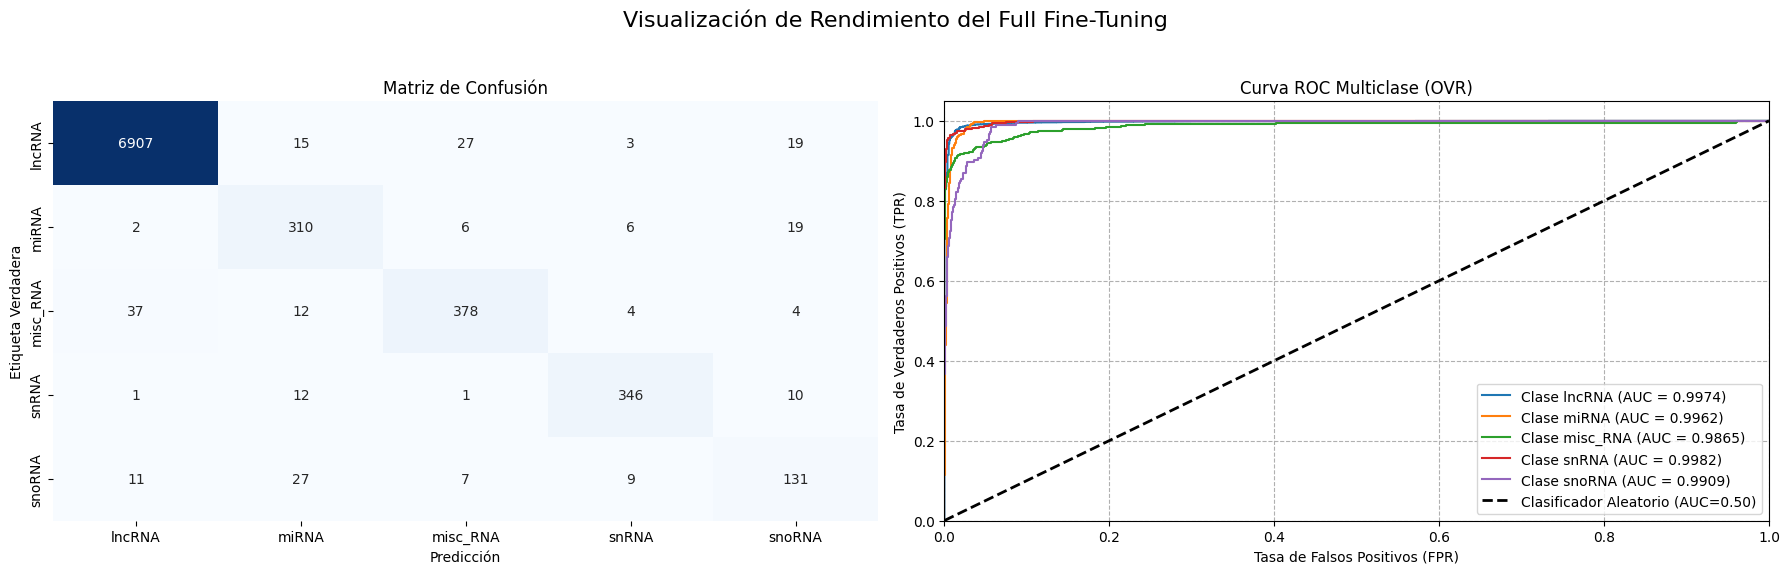

In [74]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Full Fine-Tuning')

Al aumentar la cabeza de clasificación hacemos que el modelo compense su peor rendimiento en la clase snoRNA, que ya dijimos que le costaba tener un buen desempeño en cadenas cortas, dado que los transformers son arquitecturas profundas dependientes de secuencias largas...

Feature Extraction: Modelo base reajustable, lr = 5e5, forma de comprimir las secuencias-> Mean Pooling. Arquitectura Cabeza 128 (input) -> 256 -> 64 -> 16 -> 5



Dropout = 0.5

Epoch 1/30 | Train Loss: 1.0694 | Val Loss: 0.3703 | Val Acc: 0.8763 | Val F1 Macro: 0.3138
Epoch 2/30 | Train Loss: 0.4442 | Val Loss: 0.2582 | Val Acc: 0.9076 | Val F1 Macro: 0.4673
Epoch 3/30 | Train Loss: 0.3322 | Val Loss: 0.2337 | Val Acc: 0.9417 | Val F1 Macro: 0.6462
Epoch 4/30 | Train Loss: 0.2841 | Val Loss: 0.2264 | Val Acc: 0.9503 | Val F1 Macro: 0.6754
Epoch 5/30 | Train Loss: 0.2552 | Val Loss: 0.1561 | Val Acc: 0.9524 | Val F1 Macro: 0.6826
Epoch 6/30 | Train Loss: 0.2296 | Val Loss: 0.1471 | Val Acc: 0.9532 | Val F1 Macro: 0.6910
Epoch 7/30 | Train Loss: 0.1999 | Val Loss: 0.1477 | Val Acc: 0.9574 | Val F1 Macro: 0.7209
Epoch 8/30 | Train Loss: 0.1913 | Val Loss: 0.1460 | Val Acc: 0.9610 | Val F1 Macro: 0.7551
Epoch 9/30 | Train Loss: 0.1793 | Val Loss: 0.1433 | Val Acc: 0.9661 | Val F1 Macro: 0.8148
Epoch 10/30 | Train Loss: 0.1699 | Val Loss: 0.1363 | Val Acc: 0.9697 | Val F1 Macro: 0.8473
Epoch 11/30 | Train Loss: 0.1566 | Val Loss: 0.1557 | Val Acc: 0.9725 | Val F1 

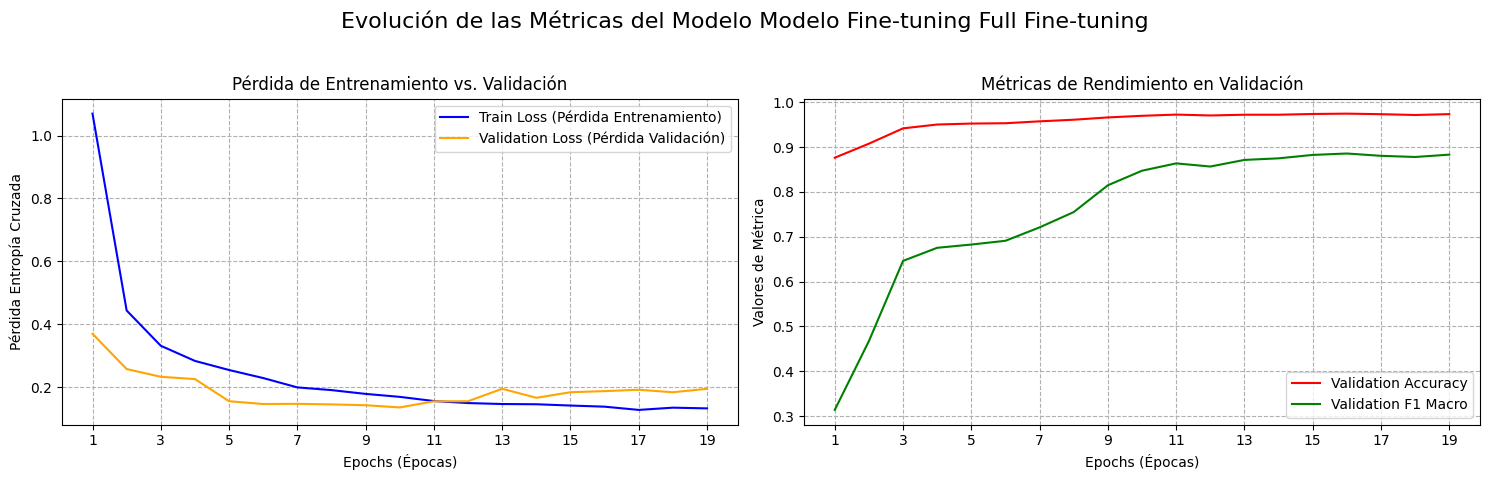

In [ ]:
#Recuperamos el modelo preentrenado guardado en local
modelo_mlm_pretrained = load_model(TinyRNATransformer(vocab_size=len(itos), max_len=512, d_model=128, d_ff=256, n_heads=4, n_layers=4), 
                                   ruta_archivo="./modelos_guardados/pesos_modelo_mlm_preentrenado.pth")



downstream_model_trained, history = train_downstream_model(modelo_mlm_pretrained, dataset_train, dataset_val, num_classes = len(clases_unicas), epochs = 30,
                                            head_initial_dim=256, patience = 3, sampler = sampler, freeze_base_model = False, dropout = 0.5, lr = 5e-5, mean_pooling = True) 

print("\n")
print(downstream_model_trained)
print("\n")
showTrainMetrics(history, title=' Full Fine-tuning')


--- Resultados en el Conjunto de Test ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6971
           1       0.78      0.94      0.85       343
           2       0.92      0.85      0.89       435
           3       0.91      0.94      0.92       370
           4       0.75      0.67      0.71       185

    accuracy                           0.97      8304
   macro avg       0.87      0.88      0.87      8304
weighted avg       0.97      0.97      0.97      8304

Test AUC Macro (OVR): 0.9927
Test MCC: 0.8994


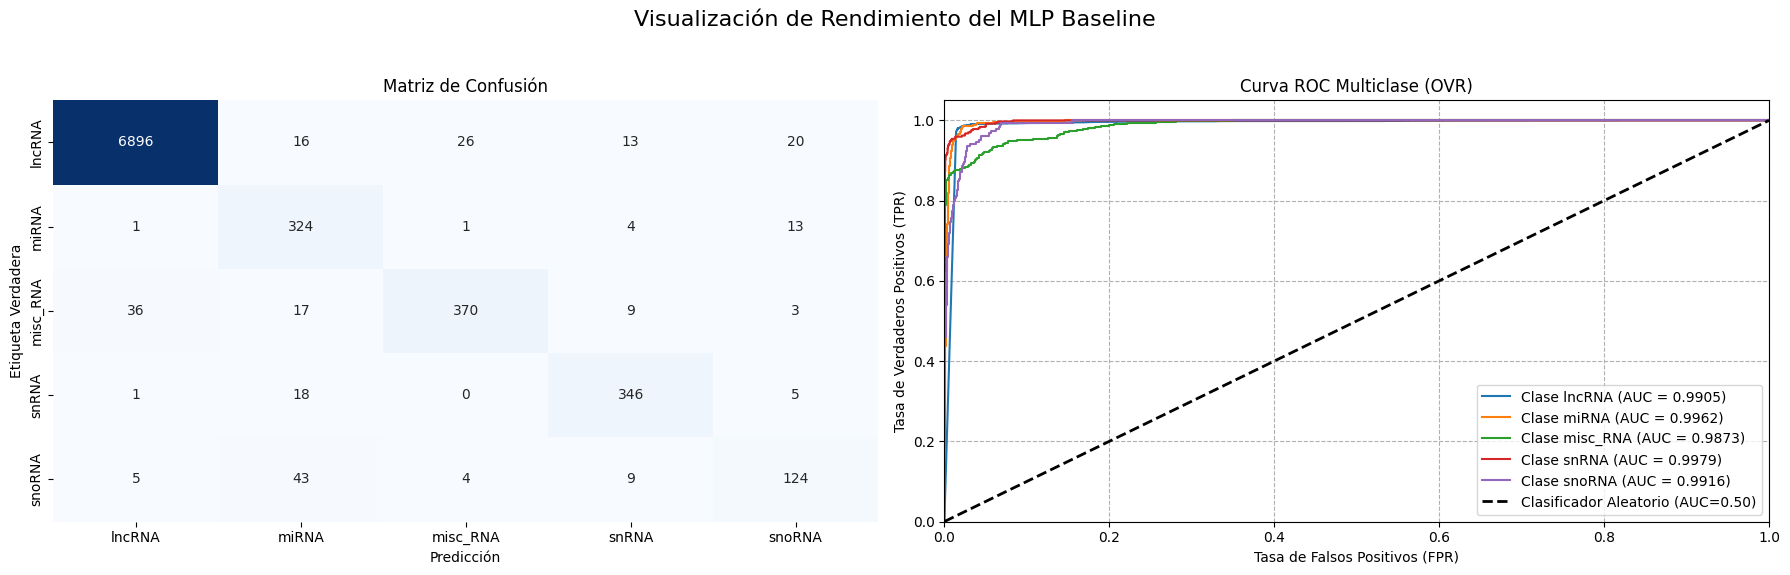

In [ ]:
ac, f1, cf_matrix, roc_curve_data = test_downstream_model(downstream_model_trained, test_dataset=dataset_test, class_to_idx=class_to_idx)
showTestMetrics(cf_matrix, roc_curve_data, class_to_idx, clases_unicas, title = 'Full Fine-Tuning')